# TWITTER SENTIMENT ANALYSIS USING SPARK 

## Data Load with Spark Session

In [1]:
import os
os.environ["USE_TF"] = "0"
os.environ["TRANSFORMERS_NO_TF"] = "1"
os.environ["TRANSFORMERS_NO_FLAX"] = "1"


In [2]:
import os
# Prefer tree-model threads, keep BLAS single-threaded
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["VECLIB_MAXIMUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"


In [3]:
import os, findspark
from pyspark.sql import SparkSession

private_ip = "127.0.0.1"
print(f"✅ Spark will bind to IP: {private_ip}")

os.environ["SPARK_HOME"] = os.path.expanduser("~/spark-3.5.1")
findspark.init()

PYTHON_PATH = "/Library/Frameworks/Python.framework/Versions/3.10/bin/python3.10"
os.environ["PYSPARK_PYTHON"] = PYTHON_PATH
os.environ["PYSPARK_DRIVER_PYTHON"] = PYTHON_PATH
os.environ["_JAVA_OPTIONS"] = (
    "-Xms8g -Xmx16g "
    "-XX:+UseG1GC -XX:+ExplicitGCInvokesConcurrent "
    "-XX:MaxGCPauseMillis=100 -Dlog4j.rootCategory=ERROR,console"
)
os.environ["SPARK_LOCAL_IP"] = private_ip
os.environ["PYSPARK_SUBMIT_ARGS"] = (
    f"--conf spark.driver.host={private_ip} "
    f"--conf spark.port.maxRetries=100 "
    f"--packages org.apache.spark:spark-sql-kafka-0-10_2.12:3.5.1,"
    f"org.apache.kafka:kafka-clients:3.5.1 pyspark-shell"
)

spark = (
    SparkSession.builder
    .appName("TwitterSentimentTraining")
    .master("local[*]")
    .config("spark.driver.memory", "10g")
    .config("spark.executor.memory", "10g")             # harmless in local[*]
    .config("spark.driver.host", private_ip)
    .config("spark.driver.bindAddress", private_ip)
    .config("spark.ui.bindAddress", private_ip)
    .config("spark.ui.port", "4060")
    .config("spark.driver.port", "4666")
    .config("spark.serializer", "org.apache.spark.serializer.KryoSerializer")
    .config("spark.memory.fraction", "0.8")
    .config("spark.executor.extraJavaOptions", "-XX:+UseG1GC")
    .config("spark.shuffle.file.buffer", "64k")
    .config("spark.reducer.maxSizeInFlight", "48m")
    .config("spark.rpc.askTimeout", "600s")
    .config("spark.network.timeout", "600s")
    .config("spark.executor.heartbeatInterval", "30s")
    .config("spark.sql.shuffle.partitions", "16")
    .config("spark.default.parallelism", "16")
    .config("spark.sql.codegen.wholeStage", "false")
    .config("spark.sql.adaptive.enabled", "true")
    .config("spark.sql.adaptive.advisoryPartitionSizeInBytes", "67108864")
    .config("spark.executorEnv.PYSPARK_PYTHON", PYTHON_PATH)
    .config("spark.pyspark.python", PYTHON_PATH)
    .config("spark.pyspark.driver.python", PYTHON_PATH)
    .config("spark.storage.memoryMapThreshold", "2m")
    .config("spark.driver.maxResultSize", "4g")
    .config("spark.broadcast.compress", "true")
    .getOrCreate()
)

import sys
spark.sparkContext.setLogLevel("ERROR")
spark.conf.set("spark.sql.legacy.timeParserPolicy", "LEGACY")
print("🐍 Driver Python:", sys.executable)
print("🐍 Worker Python:", spark.sparkContext.parallelize([1]).map(lambda _: __import__('sys').executable).first())
print("✅ Spark is working with Hadoop version:", spark._jvm.org.apache.hadoop.util.VersionInfo.getVersion())


Picked up _JAVA_OPTIONS: -Xms8g -Xmx16g -XX:+UseG1GC -XX:+ExplicitGCInvokesConcurrent -XX:MaxGCPauseMillis=100 -Dlog4j.rootCategory=ERROR,console


✅ Spark will bind to IP: 127.0.0.1


Picked up _JAVA_OPTIONS: -Xms8g -Xmx16g -XX:+UseG1GC -XX:+ExplicitGCInvokesConcurrent -XX:MaxGCPauseMillis=100 -Dlog4j.rootCategory=ERROR,console


:: loading settings :: url = jar:file:/Users/yasmeenazmatali/spark-3.5.1/jars/ivy-2.5.1.jar!/org/apache/ivy/core/settings/ivysettings.xml


Ivy Default Cache set to: /Users/yasmeenazmatali/.ivy2/cache
The jars for the packages stored in: /Users/yasmeenazmatali/.ivy2/jars
org.apache.spark#spark-sql-kafka-0-10_2.12 added as a dependency
org.apache.kafka#kafka-clients added as a dependency
:: resolving dependencies :: org.apache.spark#spark-submit-parent-04932889-65ff-4145-b2fd-82ab0bdc7036;1.0
	confs: [default]
	found org.apache.spark#spark-sql-kafka-0-10_2.12;3.5.1 in central
	found org.apache.spark#spark-token-provider-kafka-0-10_2.12;3.5.1 in central
	found org.apache.hadoop#hadoop-client-runtime;3.3.4 in central
	found org.apache.hadoop#hadoop-client-api;3.3.4 in central
	found org.xerial.snappy#snappy-java;1.1.10.3 in central
	found org.slf4j#slf4j-api;2.0.7 in central
	found commons-logging#commons-logging;1.1.3 in central
	found com.google.code.findbugs#jsr305;3.0.0 in central
	found org.apache.commons#commons-pool2;2.11.1 in central
	found org.apache.kafka#kafka-clients;3.5.1 in central
	found com.github.luben#zstd-j

🐍 Driver Python: /Library/Frameworks/Python.framework/Versions/3.10/bin/python3


🐍 Worker Python: /Library/Frameworks/Python.framework/Versions/3.10/bin/python3.10
✅ Spark is working with Hadoop version: 3.3.4


### Load and Display Both Dataset

In [4]:
from pyspark.sql import SparkSession
from pyspark.sql.types import StructType, StructField, StringType, IntegerType
import os
import shutil

# ─────────────────────────────────────────────────────────────
# ✅ Spark Session
# ─────────────────────────────────────────────────────────────
spark = SparkSession.builder.getOrCreate()

# ─────────────────────────────────────────────────────────────
# ✅ Define Schema
# ─────────────────────────────────────────────────────────────
schema = StructType([
    StructField("target", IntegerType(), True),
    StructField("ids", StringType(), True),
    StructField("date", StringType(), True),
    StructField("flag", StringType(), True),
    StructField("user", StringType(), True),
    StructField("text", StringType(), True),
])

# ─────────────────────────────────────────────────────────────
# ✅ Load Both CSVs
# ─────────────────────────────────────────────────────────────
train_df = spark.read.schema(schema) \
    .option("encoding", "ISO-8859-1") \
    .csv("training.1600000.processed.noemoticon.csv")

neutral_df = spark.read.schema(schema) \
    .option("header", "true") \
    .option("encoding", "ISO-8859-1") \
    .csv("neutral_tweets.csv")

# ─────────────────────────────────────────────────────────────
# ✅ Show Preview of Each Dataset
# ─────────────────────────────────────────────────────────────
print("📄 Preview: train_df")
train_df.show(3, truncate=False)

print("📄 Preview: neutral_df")
neutral_df.show(3, truncate=False)

# ─────────────────────────────────────────────────────────────
# ✅ Count Rows Before Combine
# ─────────────────────────────────────────────────────────────
print(f"🔢 train_df count     : {train_df.count()}")
print(f"🔢 neutral_df count   : {neutral_df.count()}")

# --- Neutral CSV header sanity (place right after schema is defined) ---
first_row_df = spark.read.text("neutral_tweets.csv").limit(1)

first_row = first_row_df.collect()[0][0]
assert ("target" in first_row and "ids" in first_row), \
       "❌ neutral_tweets.csv seems to have NO header (expected columns like 'target,ids,date,flag,user,text')"

# Header exists → read with header=true
neutral_df = (spark.read.schema(schema)
    .option("header", "true")
    .option("encoding", "ISO-8859-1")
    .csv("neutral_tweets.csv")
)

import os, shutil, glob
combined_df = train_df.unionByName(neutral_df).coalesce(1)
tmp_dir = "temp_combined_csv_output"
combined_df.write.option("header", True).option("encoding", "utf-8").mode("overwrite").csv(tmp_dir)

part_files = glob.glob(os.path.join(tmp_dir, "part-*.csv"))
assert part_files, "No part CSV produced."
shutil.move(part_files[0], "combined_tweets.csv")
shutil.rmtree(tmp_dir, ignore_errors=True)
print("✅ Combined CSV saved as: combined_tweets.csv")


📄 Preview: train_df
+------+----------+----------------------------+--------+---------------+-------------------------------------------------------------------------------------------------------------------+
|target|ids       |date                        |flag    |user           |text                                                                                                               |
+------+----------+----------------------------+--------+---------------+-------------------------------------------------------------------------------------------------------------------+
|0     |1467810369|Mon Apr 06 22:19:45 PDT 2009|NO_QUERY|_TheSpecialOne_|@switchfoot http://twitpic.com/2y1zl - Awww, that's a bummer.  You shoulda got David Carr of Third Day to do it. ;D|
|0     |1467810672|Mon Apr 06 22:19:49 PDT 2009|NO_QUERY|scotthamilton  |is upset that he can't update his Facebook by texting it... and might cry as a result  School today also. Blah!    |
|0     |1467810917|Mon Apr 06 

[Stage 12:>                                                         (0 + 1) / 1]

✅ Combined CSV saved as: combined_tweets.csv


**Combine Both Dataset**

In [5]:
from pyspark.sql import SparkSession
from pyspark.sql.types import StructType, StructField, StringType, IntegerType


# ✅ Define the same schema
schema = StructType([
    StructField("target", IntegerType(), True),
    StructField("ids", StringType(), True),
    StructField("date", StringType(), True),
    StructField("flag", StringType(), True),
    StructField("user", StringType(), True),
    StructField("text", StringType(), True),
])

# ✅ Load the combined CSV
combined_df = spark.read.schema(schema) \
    .option("header", True) \
    .option("encoding", "utf-8") \
    .csv("combined_tweets.csv")

# ✅ Show basic info
combined_df.show(5, truncate=False)
print(f"🔢 Total Rows: {combined_df.count()}")
combined_df.printSchema()



+------+----------+----------------------------+--------+---------------+-------------------------------------------------------------------------------------------------------------------+
|target|ids       |date                        |flag    |user           |text                                                                                                               |
+------+----------+----------------------------+--------+---------------+-------------------------------------------------------------------------------------------------------------------+
|0     |1467810369|Mon Apr 06 22:19:45 PDT 2009|NO_QUERY|_TheSpecialOne_|@switchfoot http://twitpic.com/2y1zl - Awww, that's a bummer.  You shoulda got David Carr of Third Day to do it. ;D|
|0     |1467810672|Mon Apr 06 22:19:49 PDT 2009|NO_QUERY|scotthamilton  |is upset that he can't update his Facebook by texting it... and might cry as a result  School today also. Blah!    |
|0     |1467810917|Mon Apr 06 22:19:53 PDT 2009|NO

**Label Distribution**

In [6]:
# ─────────────────────────────────────────────────────────────
# ✅ Label Distribution Check
# ─────────────────────────────────────────────────────────────
from pyspark.sql.functions import col

print("📊 Label Distribution (target column):")
combined_df.groupBy("target").count().orderBy(col("count").desc()).show()


📊 Label Distribution (target column):
+------+------+
|target| count|
+------+------+
|     0|800000|
|     4|800000|
|     2|788888|
+------+------+



In [7]:
# Show last 5 rows 
print("'Last Five Records of Training' Dataset:")
row_count = combined_df.count()
combined_df.orderBy("ids", ascending=False).show(5)


'Last Five Records of Training' Dataset:
+------+----------+--------------------+--------+----------+--------------------+
|target|       ids|                date|    flag|      user|                text|
+------+----------+--------------------+--------+----------+--------------------+
|     2|9999998136|Mon Oct 31 03:15:...|NO_QUERY|user_19997|Enter trial scene...|
|     2|9999981677|Tue Aug 25 08:10:...|NO_QUERY|user_76903|Court ever ready ...|
|     2|9999966467|Sat Jul 08 14:14:...|NO_QUERY|user_83008|Newspaper where e...|
|     2|9999963672|Sat Sep 25 04:06:...|NO_QUERY|user_97526|Small way head wh...|
|     2|9999945399|Fri Oct 09 08:01:...|NO_QUERY|user_98798|Social believe ce...|
+------+----------+--------------------+--------+----------+--------------------+
only showing top 5 rows



In [8]:
# Shape of the dataset
print("Shape of the 'Training' dataset:")
print(f"Rows: {row_count}, Columns: {len(combined_df.columns)}")

Shape of the 'Training' dataset:
Rows: 2388888, Columns: 6


In [9]:
from pyspark.sql import functions as F

print("🔍 Missing Value Count Per Column:")
combined_df.select([
    F.count(F.when(F.col(c).isNull(), c)).alias(c) for c in combined_df.columns
]).show()


🔍 Missing Value Count Per Column:
+------+---+----+----+----+----+
|target|ids|date|flag|user|text|
+------+---+----+----+----+----+
|     0|  0|   0|   0|   0|   0|
+------+---+----+----+----+----+



In [10]:
# Check duplicate rows
duplicate_count = combined_df.count() - combined_df.dropDuplicates().count()
print(f"🔁 Duplicate rows: {duplicate_count}")

[Stage 30:==========================================>             (12 + 4) / 16]

🔁 Duplicate rows: 0


In [11]:
import langid
langid.classify("السلام عليكم")  # e.g., ('ar', score)


('ar', -57.124754905700684)

In [12]:
import langid
print(langid.classify("merhaba"))

('de', -13.663267612457275)


## Data Cleaning and Feature Engineering

**Real-time Twitter Pipeline: Cleaning, VADER Scoring, and Feature Set**

In [13]:
try:
    import langid
except Exception:
    import sys, subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "langid"])
    import langid


In [14]:
# ─────────────────────────────────────────────────────────────
# 0) Imports + NLTK downloads (top)
# ─────────────────────────────────────────────────────────────
import re, string
import nltk
import pandas as pd

from nltk.corpus import stopwords, opinion_lexicon
from nltk.stem import PorterStemmer

from pyspark.sql import functions as F
from pyspark.sql.functions import udf, col, pandas_udf
from pyspark.sql.types import StringType, IntegerType, FloatType
from pyspark.storagelevel import StorageLevel

# 📦 NLTK (download once on driver; executors par download avoid)
for pkg in ["stopwords","vader_lexicon","opinion_lexicon"]:
    try:
        nltk.data.find(f"corpora/{pkg}")
    except LookupError:
        nltk.download(pkg)

# Arrow ON (pandas UDFs need it)
spark.conf.set("spark.sql.execution.arrow.pyspark.enabled", "true")

# Unique key for joins (use your tweet id if present)
if "_rid" not in combined_df.columns:
    combined_df = combined_df.withColumn("_rid", F.monotonically_increasing_id())

# ─────────────────────────────────────────────────────────────
# 1) Spark-SQL Text Cleaning  (keep hashtag word; drop only '#')
# ─────────────────────────────────────────────────────────────
clean_expr = F.lower(F.col("text"))
clean_expr = F.regexp_replace(clean_expr, r"#(?=\w)", "")
clean_expr = F.regexp_replace(clean_expr, r"http\S+|www\.\S+", " ")
clean_expr = F.regexp_replace(clean_expr, r"@\w+", " ")
# preserve multilingual chars (NO ASCII strip)
clean_expr = F.regexp_replace(clean_expr, "[" + re.escape(string.punctuation) + "]", " ")
clean_expr = F.regexp_replace(clean_expr, r'(.)\1{2,}', r'\1\1')
clean_expr = F.regexp_replace(clean_expr, r'\s+', ' ')
clean_expr = F.trim(clean_expr)
# HTML entity fix
clean_expr = F.regexp_replace(clean_expr, r"&amp;", "&")

combined_df = combined_df.withColumn("clean_text", clean_expr).na.fill({"clean_text": ""})

# ─────────────────────────────────────────────────────────────
# 2) Language detect (pure UDF) + English-only stemming
# ─────────────────────────────────────────────────────────────
import langid

# ——— script regexes (cheap + robust) ———
ARABIC_RE      = re.compile(r'[\u0600-\u06FF]')     # Arabic/Urdu/Persian
DEVANAGARI_RE  = re.compile(r'[\u0900-\u097F]')     # Hindi etc.
CYRILLIC_RE    = re.compile(r'[\u0400-\u04FF]')     # ru/uk/bg...
CJK_RE         = re.compile(r'[\u4E00-\u9FFF\u3040-\u30FF\uAC00-\uD7AF]')  # zh/ja/ko

# Whitelist to steady langid
langid.set_languages(['en','ar','ur','fa','hi','bn','tr','es','fr','de','ru','zh','ja','ko'])

def ascii_ratio(s: str) -> float:
    if not s: return 1.0
    a = sum(1 for ch in s if ord(ch) < 128)
    return a / max(1, len(s))

def detect_one(text: str) -> str:
    if not text: return 'unknown'
    # script-first shortcuts
    if ARABIC_RE.search(text):     return 'ar'
    if DEVANAGARI_RE.search(text): return 'hi'
    if CYRILLIC_RE.search(text):   return 'ru'
    if CJK_RE.search(text):        return 'zh'   # coarse bucket for gating

    # latin → langid
    lang, score = langid.classify(text)
    if lang == 'en' and ascii_ratio(text) >= 0.95 and score > -20:
        return 'en'
    if len(text.split()) < 2 or len(text) < 6:  # tiny text guard
        return 'unknown'
    return lang

@pandas_udf(StringType())
def detect_lang_pd(s: pd.Series) -> pd.Series:
    return s.fillna("").astype(str).apply(detect_one)

# 2.1) 'lang', 'lang_bin', 'lang_group' + one-hot flags
combined_df = combined_df.withColumn("lang", detect_lang_pd(F.col("clean_text")))
combined_df = combined_df.withColumn(
    "lang_bin",
    F.when(F.col("lang") == "en", "en").otherwise("non_en")
)

def lang_group_expr():
    return (F.when(F.col("lang")=="en", "en")
              .when(F.col("lang").isin(["ar","fa","ur"]), "arabic")
              .when(F.col("lang").isin(["hi","bn"]), "indic")
              .when(F.col("lang")=="ru", "cyril")
              .when(F.col("lang").isin(["zh","ja","ko"]), "cjk")
              .otherwise("latin_other"))

combined_df = combined_df.withColumn("lang_group", lang_group_expr())

LANG_GROUPS = ["en","arabic","indic","cyril","cjk","latin_other"]
exprs = [F.when(F.col("lang_group")==g, 1).otherwise(0).alias(f"lang_{g}") for g in LANG_GROUPS]
combined_df = combined_df.select("*", *exprs)

# 👉 add this right here
for g in ["en","arabic","indic","cyril","cjk","latin_other"]:
    combined_df = combined_df.withColumn(f"lang_{g}", F.col(f"lang_{g}").cast("int"))

# 2.2) English-only stemming (stopwords + stemmer)
stop_words_bv = spark.sparkContext.broadcast({w.lower() for w in stopwords.words("english")})
ps = PorterStemmer()

@udf(StringType())
def remove_sw_stem_cond(tok_list, lang):
    if not tok_list:
        return ""
    if lang != 'en':
        # non-EN → no stemming, no stopword drop
        return " ".join(w.lower() for w in tok_list if w)
    sw = stop_words_bv.value
    return " ".join(ps.stem(w.lower()) for w in tok_list if w and w.lower() not in sw)

combined_df = (combined_df
    .withColumn("tokens", F.split(F.col("clean_text"), " "))
    .withColumn("processed_text", remove_sw_stem_cond(F.col("tokens"), F.col("lang")))
)

# ─────────────────────────────────────────────────────────────
# 2.9) Text for VADER (keep punctuation/emoticons; EN-only later)
# ─────────────────────────────────────────────────────────────
text_for_vader = F.lower(F.col("text"))
text_for_vader = F.regexp_replace(text_for_vader, r"http\S+|www\.\S+", " ")
text_for_vader = F.regexp_replace(text_for_vader, r"@\w+", " ")

# ─────────────────────────────────────────────────────────────
# 3) VADER only for English (compute on EN subset, then LEFT JOIN)
# ─────────────────────────────────────────────────────────────
from nltk.sentiment.vader import SentimentIntensityAnalyzer

@pandas_udf(FloatType())
def vader_polarity_pd(series: pd.Series) -> pd.Series:
    _state = getattr(vader_polarity_pd, "_state", None)
    if _state is None:
        vader_polarity_pd._state = {"sia": SentimentIntensityAnalyzer()}
        _state = vader_polarity_pd._state
    sia = _state["sia"]
    vals = series.fillna("").astype(str)
    return vals.apply(lambda t: float(sia.polarity_scores(t)["compound"]) if t else 0.0).astype(float)

en_only = (combined_df
           .filter(F.col("lang")=="en")
           .select("_rid", text_for_vader.alias("t4v"))
           .withColumn("vader_score", vader_polarity_pd(F.col("t4v")))
           .withColumn(
               "vader_bucket",
               F.when(F.col("vader_score")<=-0.4, F.lit(0))
                .when(F.col("vader_score")>= 0.4, F.lit(1))
                .otherwise(F.lit(2))
           ))
# join stays the same
combined_df = (combined_df
    .join(en_only.select("_rid","vader_score","vader_bucket"), on="_rid", how="left")
    .fillna({"vader_score":0.0, "vader_bucket":2})
)

# 👉 Cast vader_bucket to int (tidy up types)
combined_df = combined_df.withColumn("vader_bucket", F.col("vader_bucket").cast("int"))


# ─────────────────────────────────────────────────────────────
# 4) Label Mapping
# ─────────────────────────────────────────────────────────────
combined_df = (
    combined_df.withColumn(
        "sentiment",
        F.when(col("target") == 0, 0)   # negative
         .when(col("target") == 4, 2)  # positive
         .when(col("target") == 2, 1)  # neutral
         .otherwise(None)
         .cast(IntegerType())
    )
    .withColumn(
        "sentiment_label",
        F.when(col("sentiment") == 0, "negative")
         .when(col("sentiment") == 1, "neutral")
         .when(col("sentiment") == 2, "positive")
    )
)

# ─────────────────────────────────────────────────────────────
# 4.5) Deduplicate (after labels are ready)
# ─────────────────────────────────────────────────────────────
# Remove exact dupes by (clean_text, sentiment)
combined_df = combined_df.dropDuplicates(["clean_text", "sentiment"])

# ─────────────────────────────────────────────────────────────
# 5) Temporal Features
# ─────────────────────────────────────────────────────────────
spark.conf.set("spark.sql.legacy.timeParserPolicy", "LEGACY")
combined_df = combined_df.withColumn("date_ts", F.to_timestamp("date", "EEE MMM dd HH:mm:ss Z yyyy"))
combined_df = (
    combined_df.withColumn("hour", F.hour("date_ts"))
               .withColumn("day_of_week", F.dayofweek("date_ts"))
               .withColumn("is_weekend", F.when(F.col("day_of_week").isin(1, 7), 1).otherwise(0))
)

# ─────────────────────────────────────────────────────────────
# 6) Text Metrics
# ─────────────────────────────────────────────────────────────
combined_df = (
    combined_df.withColumn("text_length", F.length("clean_text"))
               .withColumn("word_count",
                           F.when(F.col("clean_text") == "", 0)
                            .otherwise(F.size(F.split("clean_text", " "))))
               .withColumn("char_density",
                           F.when(F.col("word_count") == 0, 0.0)
                            .otherwise((F.col("text_length") / F.col("word_count")).cast(FloatType())))
               .withColumn("char_density",
                           F.when(F.col("char_density") > 20.0, 20.0)
                            .otherwise(F.col("char_density")))
)

# ─────────────────────────────────────────────────────────────
# 7) Flag Features
# ─────────────────────────────────────────────────────────────
combined_df = (
    combined_df
      .withColumn("has_mentions", F.when(F.col("text").rlike(r'(^|\s)@\w+'), 1).otherwise(0))
      .withColumn("has_hashtags", F.when(F.col("text").rlike(r'(^|\s)#\w+'), 1).otherwise(0))
      .withColumn("has_links",    F.when(F.col("text").rlike(r'http[s]?://|www\.'), 1).otherwise(0))
      .withColumn("is_question",  F.when(F.col("text").rlike(r'\?\s*$'), 1).otherwise(0))
)

# ─────────────────────────────────────────────────────────────
# 8) Syntactic & Semantic Features
# ─────────────────────────────────────────────────────────────
sentiment_keywords = {"love","hate","amazing","awful","great","bad","good","terrible","worst","excellent"}
negation_words     = {"not","no","never","none","nobody","isn't","wasn't","aren't","don't","didn't","won't","can't"}

broadcast_keywords  = spark.sparkContext.broadcast(sentiment_keywords)
broadcast_negations = spark.sparkContext.broadcast(negation_words)

positive_lexicon = {"good","great","excellent","amazing","love","nice","happy","best"}
negative_lexicon = {"bad","terrible","awful","hate","worst","sad","horrible","angry"}

pos_words_bv = spark.sparkContext.broadcast(positive_lexicon)
neg_words_bv = spark.sparkContext.broadcast(negative_lexicon)

# NLTK opinion_lexicon (extended lists)
extended_positive = spark.sparkContext.broadcast(set(opinion_lexicon.positive()))
extended_negative = spark.sparkContext.broadcast(set(opinion_lexicon.negative()))

from pyspark.sql.types import IntegerType

# language-agnostic negation count
@udf(IntegerType())
def count_negations(text):
    if text:
        words = text.lower().split()
        return sum(1 for w in words if w in broadcast_negations.value)
    return 0

# EN-only lexicon counts
@udf(IntegerType())
def count_sentiment_keywords_cond(text, lang):
    if text and lang == 'en':
        words = text.lower().split()
        return sum(1 for w in words if w in broadcast_keywords.value)
    return 0

@udf(IntegerType())
def count_positive_words_cond(text, lang):
    if text and lang == 'en':
        return sum(1 for w in text.lower().split() if w in pos_words_bv.value)
    return 0

@udf(IntegerType())
def count_negative_words_cond(text, lang):
    if text and lang == 'en':
        return sum(1 for w in text.lower().split() if w in neg_words_bv.value)
    return 0

@udf(IntegerType())
def count_extended_positive_cond(text, lang):
    if text and lang == 'en':
        return sum(1 for w in text.lower().split() if w in extended_positive.value)
    return 0

@udf(IntegerType())
def count_extended_negative_cond(text, lang):
    if text and lang == 'en':
        return sum(1 for w in text.lower().split() if w in extended_negative.value)
    return 0

@udf(IntegerType())
def count_capital_words(text):
    if text:
        return len(re.findall(r"\b[A-Z]{2,}\b", text))
    return 0

EMOJI_RE    = re.compile(r'[\U0001F300-\U0001FAFF\U00002600-\U000026FF]')
EMOTICON_RE = re.compile(r'(?:(?:[:;=8][\-^]?[)DpP/\\|oO\(\]])|<3|:\'\(|xD|XD)')

@udf(IntegerType())
def count_emoji_like(text):
    if not text:
        return 0
    return len(EMOJI_RE.findall(text)) + len(EMOTICON_RE.findall(text))

# apply feature columns
combined_df = (
    combined_df
      .withColumn("negation_count",          count_negations(F.col("clean_text")))
      .withColumn("capital_word_count",      count_capital_words(F.col("text")))
      .withColumn("emoji_count",             count_emoji_like(F.col("text")))
      .withColumn("sentiment_keyword_count", count_sentiment_keywords_cond(F.col("clean_text"), F.col("lang")))
      .withColumn("positive_lexicon_count",  count_positive_words_cond(F.col("clean_text"), F.col("lang")))
      .withColumn("negative_lexicon_count",  count_negative_words_cond(F.col("clean_text"), F.col("lang")))
      .withColumn("extended_positive_lexicon_count", count_extended_positive_cond(F.col("clean_text"), F.col("lang")))
      .withColumn("extended_negative_lexicon_count", count_extended_negative_cond(F.col("clean_text"), F.col("lang")))
)

# Cap extreme emoji skew
combined_df = combined_df.withColumn("emoji_count", F.least(F.col("emoji_count"), F.lit(5)))

# ---- Emoji polarity (language-agnostic) ----
pos_emoji = set(list("😀😁😂🤣😊😍😘😎🙂☺️👍💖✨🎉🔥💯😺"))
neg_emoji = set(list("😞😠😡🤬😢😭☹️👎💔💀😒🙄😕😤"))

@udf(IntegerType())
def emoji_polarity(text):
    if not text:
        return 0
    p = sum(1 for ch in text if ch in pos_emoji)
    n = sum(1 for ch in text if ch in neg_emoji)
    return p - n

combined_df = combined_df.withColumn("emoji_polarity", emoji_polarity(F.col("text")))

# Tiny normalization: punctuation cap
@udf(IntegerType())
def count_punctuation(text):
    return len(re.findall(r"[{}]".format(re.escape(string.punctuation)), text)) if text else 0

combined_df = combined_df.withColumn("punctuation_count_raw", count_punctuation(col("text")))
combined_df = combined_df.withColumn("punctuation_count", F.least(F.col("punctuation_count_raw"), F.lit(30)))
combined_df = combined_df.drop("punctuation_count_raw")

# ─────────────────────────────────────────────────────────────
# 8.9) Light numeric stabilization  ← INSERT HERE
# ─────────────────────────────────────────────────────────────
# cap extreme lengths at p99
for c in ["text_length","word_count"]:
    p99 = combined_df.approxQuantile(c, [0.99], 0.001)[0]
    combined_df = combined_df.withColumn(c, F.least(F.col(c), F.lit(p99)))

# log1p on count-ish features (already non-negative)
for c in ["char_density","negation_count","emoji_count",
          "positive_lexicon_count","negative_lexicon_count",
          "extended_positive_lexicon_count","extended_negative_lexicon_count",
          "punctuation_count"]:
    combined_df = combined_df.withColumn(c, F.log1p(F.col(c)))

# ─────────────────────────────────────────────────────────────
# 9) Final Cleanup + Cache
# ─────────────────────────────────────────────────────────────
combined_df = combined_df.drop("date", "flag")
combined_df = combined_df.select("*")
combined_df = combined_df.persist(StorageLevel.MEMORY_AND_DISK)
combined_df.count()

print("nulls:", {c: combined_df.filter(F.col(c).isNull()).count() for c in ["clean_text","lang","vader_score"]})
combined_df.groupBy("sentiment").count().show()
combined_df.select("vader_score","lang").summary().show()
combined_df.groupBy("lang_bin","sentiment").count().show()
combined_df.groupBy("lang_group","sentiment").count().orderBy("lang_group","sentiment").show()
combined_df.select("emoji_count","emoji_polarity").summary().show()


[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /Users/yasmeenazmatali/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!
                                                                                

nulls: {'clean_text': 0, 'lang': 0, 'vader_score': 0}
+---------+------+
|sentiment| count|
+---------+------+
|        1|788888|
|        2|761614|
|        0|770989|
+---------+------+



+-------+------------------+-------+
|summary|       vader_score|   lang|
+-------+------------------+-------+
|  count|           2321491|2321491|
|   mean|0.1424184619151971|   NULL|
| stddev|0.4172288146719539|   NULL|
|    min|           -0.9985|     af|
|    25%|               0.0|   NULL|
|    50%|               0.0|   NULL|
|    75%|            0.4902|   NULL|
|    max|            0.9987|     zu|
+-------+------------------+-------+

+--------+---------+------+
|lang_bin|sentiment| count|
+--------+---------+------+
|  non_en|        0| 34373|
|      en|        2|723388|
|  non_en|        1| 49595|
|      en|        1|739293|
|      en|        0|736616|
|  non_en|        2| 38226|
+--------+---------+------+

+-----------+---------+------+
| lang_group|sentiment| count|
+-----------+---------+------+
|     arabic|        0|     1|
|        cjk|        0|    61|
|        cjk|        2|   211|
|         en|        0|736616|
|         en|        1|739293|
|         en|        2|723

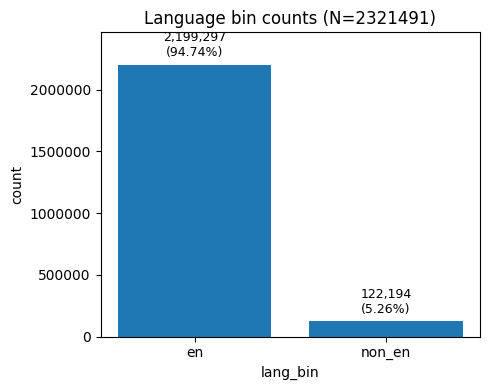

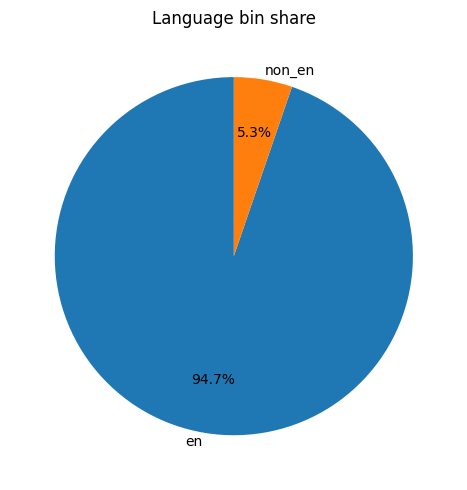

In [15]:
# ==== 1) EN vs NON-EN: Bar + Pie (fixed alignment) ====
import matplotlib.pyplot as plt

pdf = (combined_df.groupBy("lang_bin").count().toPandas()
       .sort_values("lang_bin"))
total = int(pdf["count"].sum())
pdf["pct"] = (pdf["count"] / total * 100).round(2)

# --- Bar ---
fig, ax = plt.subplots(figsize=(5,4))
bars = ax.bar(pdf["lang_bin"], pdf["count"])

ax.set_title(f"Language bin counts (N={total})")
ax.set_xlabel("lang_bin"); ax.set_ylabel("count")

# give headroom so top label isn't cut off
ymax = pdf["count"].max()
ax.set_ylim(0, ymax * 1.12)             # ← extra 12% space
ax.ticklabel_format(style="plain", axis="y")  # no scientific notation

# add labels with a small vertical offset
for i, bar in enumerate(bars):
    h = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2, h + ymax*0.02,  # 2% headroom
        f"{int(h):,}\n({pdf['pct'].iloc[i]}%)",
        ha="center", va="bottom", fontsize=9
    )

fig.tight_layout()
plt.show()

# --- Pie (optional small tweaks for neatness) ---
fig, ax = plt.subplots(figsize=(5,5))
ax.pie(
    pdf["count"], labels=pdf["lang_bin"],
    autopct=lambda p: f"{p:.1f}%",
    startangle=90, pctdistance=0.7, labeldistance=1.05
)
ax.set_title("Language bin share")
fig.tight_layout()
plt.show()


<Figure size 600x400 with 0 Axes>

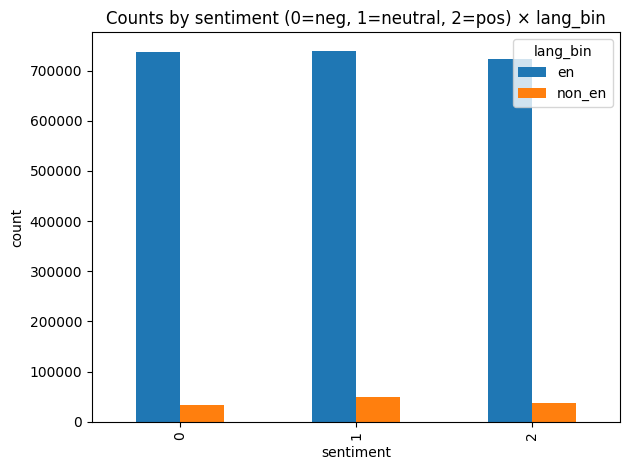

In [16]:
# ==== 2) Per-sentiment counts split by lang_bin ====
import matplotlib.pyplot as plt
import pandas as pd

pdf2 = (combined_df
        .groupBy("lang_bin","sentiment")
        .count()
        .toPandas()
        .sort_values(["sentiment","lang_bin"]))

# make a simple grouped bar (one figure, no custom colors)
pivot = pdf2.pivot(index="sentiment", columns="lang_bin", values="count").fillna(0).astype(int)

plt.figure(figsize=(6,4))
pivot.plot(kind="bar")
plt.title("Counts by sentiment (0=neg, 1=neutral, 2=pos) × lang_bin")
plt.xlabel("sentiment"); plt.ylabel("count")
plt.legend(title="lang_bin")
plt.tight_layout()
plt.show()


In [17]:
# 1) Split by language
en_df     = combined_df.filter(F.col("lang") == "en")
non_en_df = combined_df.filter(F.col("lang") != "en")  # includes 'unknown' unless you drop it

# (Optional) If you want to exclude unknown:
# non_en_df = non_en_df.filter(F.col("lang") != "unknown")


In [18]:
# Shape of the dataset
print("Shape of the 'Training' dataset:")
print(f"Rows: {row_count}, Columns: {len(combined_df.columns)}")

Shape of the 'Training' dataset:
Rows: 2388888, Columns: 42


In [19]:
# Show column names
print("'Training' Columns:")
print(combined_df.columns)

'Training' Columns:
['_rid', 'target', 'ids', 'user', 'text', 'clean_text', 'lang', 'lang_bin', 'lang_group', 'lang_en', 'lang_arabic', 'lang_indic', 'lang_cyril', 'lang_cjk', 'lang_latin_other', 'tokens', 'processed_text', 'vader_score', 'vader_bucket', 'sentiment', 'sentiment_label', 'date_ts', 'hour', 'day_of_week', 'is_weekend', 'text_length', 'word_count', 'char_density', 'has_mentions', 'has_hashtags', 'has_links', 'is_question', 'negation_count', 'capital_word_count', 'emoji_count', 'sentiment_keyword_count', 'positive_lexicon_count', 'negative_lexicon_count', 'extended_positive_lexicon_count', 'extended_negative_lexicon_count', 'emoji_polarity', 'punctuation_count']


In [20]:
# Dataset info (schema)
print("Info of the 'Training' dataset:")
combined_df.printSchema()

Info of the 'Training' dataset:
root
 |-- _rid: long (nullable = false)
 |-- target: integer (nullable = true)
 |-- ids: string (nullable = true)
 |-- user: string (nullable = true)
 |-- text: string (nullable = true)
 |-- clean_text: string (nullable = false)
 |-- lang: string (nullable = true)
 |-- lang_bin: string (nullable = false)
 |-- lang_group: string (nullable = false)
 |-- lang_en: integer (nullable = false)
 |-- lang_arabic: integer (nullable = false)
 |-- lang_indic: integer (nullable = false)
 |-- lang_cyril: integer (nullable = false)
 |-- lang_cjk: integer (nullable = false)
 |-- lang_latin_other: integer (nullable = false)
 |-- tokens: array (nullable = false)
 |    |-- element: string (containsNull = false)
 |-- processed_text: string (nullable = true)
 |-- vader_score: float (nullable = false)
 |-- vader_bucket: integer (nullable = false)
 |-- sentiment: integer (nullable = true)
 |-- sentiment_label: string (nullable = true)
 |-- date_ts: timestamp (nullable = true)


In [21]:
print("Statistical description of the 'target'column:")
combined_df.select("target").describe().show()


Statistical description of the 'target'column:
+-------+------------------+
|summary|            target|
+-------+------------------+
|  count|           2321491|
|   mean|1.9919232941243366|
| stddev|1.6250100771194458|
|    min|                 0|
|    max|                 4|
+-------+------------------+



In [22]:
from pyspark.sql.functions import col, sum as spark_sum

missing_summary = combined_df.select([
    spark_sum(col(c).isNull().cast("int")).alias(c) for c in combined_df.columns
])
missing_summary.show()

[Stage 150:=====================================>                 (11 + 5) / 16]

+----+------+---+----+----+----------+----+--------+----------+-------+-----------+----------+----------+--------+----------------+------+--------------+-----------+------------+---------+---------------+-------+----+-----------+----------+-----------+----------+------------+------------+------------+---------+-----------+--------------+------------------+-----------+-----------------------+----------------------+----------------------+-------------------------------+-------------------------------+--------------+-----------------+
|_rid|target|ids|user|text|clean_text|lang|lang_bin|lang_group|lang_en|lang_arabic|lang_indic|lang_cyril|lang_cjk|lang_latin_other|tokens|processed_text|vader_score|vader_bucket|sentiment|sentiment_label|date_ts|hour|day_of_week|is_weekend|text_length|word_count|char_density|has_mentions|has_hashtags|has_links|is_question|negation_count|capital_word_count|emoji_count|sentiment_keyword_count|positive_lexicon_count|negative_lexicon_count|extended_positive_lexi

In [23]:
combined_df.select("target", "sentiment", "sentiment_label").distinct().show()


+------+---------+---------------+
|target|sentiment|sentiment_label|
+------+---------+---------------+
|     2|        1|        neutral|
|     4|        2|       positive|
|     0|        0|       negative|
+------+---------+---------------+



In [24]:
combined_df.select("processed_text", "sentiment", "sentiment_label").show(10, truncate=False)

+-------------------------------------------------------------------------------------------+---------+---------------+
|processed_text                                                                             |sentiment|sentiment_label|
+-------------------------------------------------------------------------------------------+---------+---------------+
|                                                                                           |2        |positive       |
|0 611i enough11almost                                                                      |2        |positive       |
|0 direct messages11hmm havent figur send messag either alway get stupid error messag someth|0        |negative       |
|01 1811im going now11hahaha1111                                                            |2        |positive       |
|02 00 am11i want go bed                                                                    |0        |negative       |
|02 30 am11ana sleep11afraid nightmar ho

In [25]:
combined_df.select("target", "sentiment", "sentiment_label").distinct().orderBy("sentiment").show()


+------+---------+---------------+
|target|sentiment|sentiment_label|
+------+---------+---------------+
|     0|        0|       negative|
|     2|        1|        neutral|
|     4|        2|       positive|
+------+---------+---------------+



In [26]:
combined_df.groupBy("sentiment", "sentiment_label").count().orderBy("sentiment").show()


+---------+---------------+------+
|sentiment|sentiment_label| count|
+---------+---------------+------+
|        0|       negative|770989|
|        1|        neutral|788888|
|        2|       positive|761614|
+---------+---------------+------+



In [27]:
# ✅ Count total rows
total_rows = combined_df.count()

# ✅ Count distinct rows
distinct_rows = combined_df.distinct().count()

# ✅ Number of duplicate rows
duplicate_count = total_rows - distinct_rows

print(f"🔁 Total Rows: {total_rows}")
print(f"✅ Unique Rows: {distinct_rows}")
print(f"❗ Duplicate Rows: {duplicate_count}")


[Stage 199:=====================================>                 (11 + 5) / 16]

🔁 Total Rows: 2321491
✅ Unique Rows: 2321491
❗ Duplicate Rows: 0


In [28]:
from pyspark.sql.functions import countDistinct, col

result = []
for c in combined_df.columns:
    n = combined_df.select(countDistinct(col(c)).alias("count")).first()["count"]
    result.append((c, n))

# Convert to DataFrame
spark.createDataFrame(result, ["column", "distinct_count"]).show(26)


+----------------+--------------+
|          column|distinct_count|
+----------------+--------------+
|            _rid|       2321491|
|          target|             3|
|             ids|       2319663|
|            user|        743711|
|            text|       2319610|
|      clean_text|       2317626|
|            lang|            71|
|        lang_bin|             2|
|      lang_group|             4|
|         lang_en|             2|
|     lang_arabic|             2|
|      lang_indic|             1|
|      lang_cyril|             1|
|        lang_cjk|             2|
|lang_latin_other|             2|
|          tokens|       2317626|
|  processed_text|       2283067|
|     vader_score|         17830|
|    vader_bucket|             3|
|       sentiment|             3|
| sentiment_label|             3|
|         date_ts|       1546139|
|            hour|            24|
|     day_of_week|             7|
|      is_weekend|             2|
|     text_length|           134|
+-------------

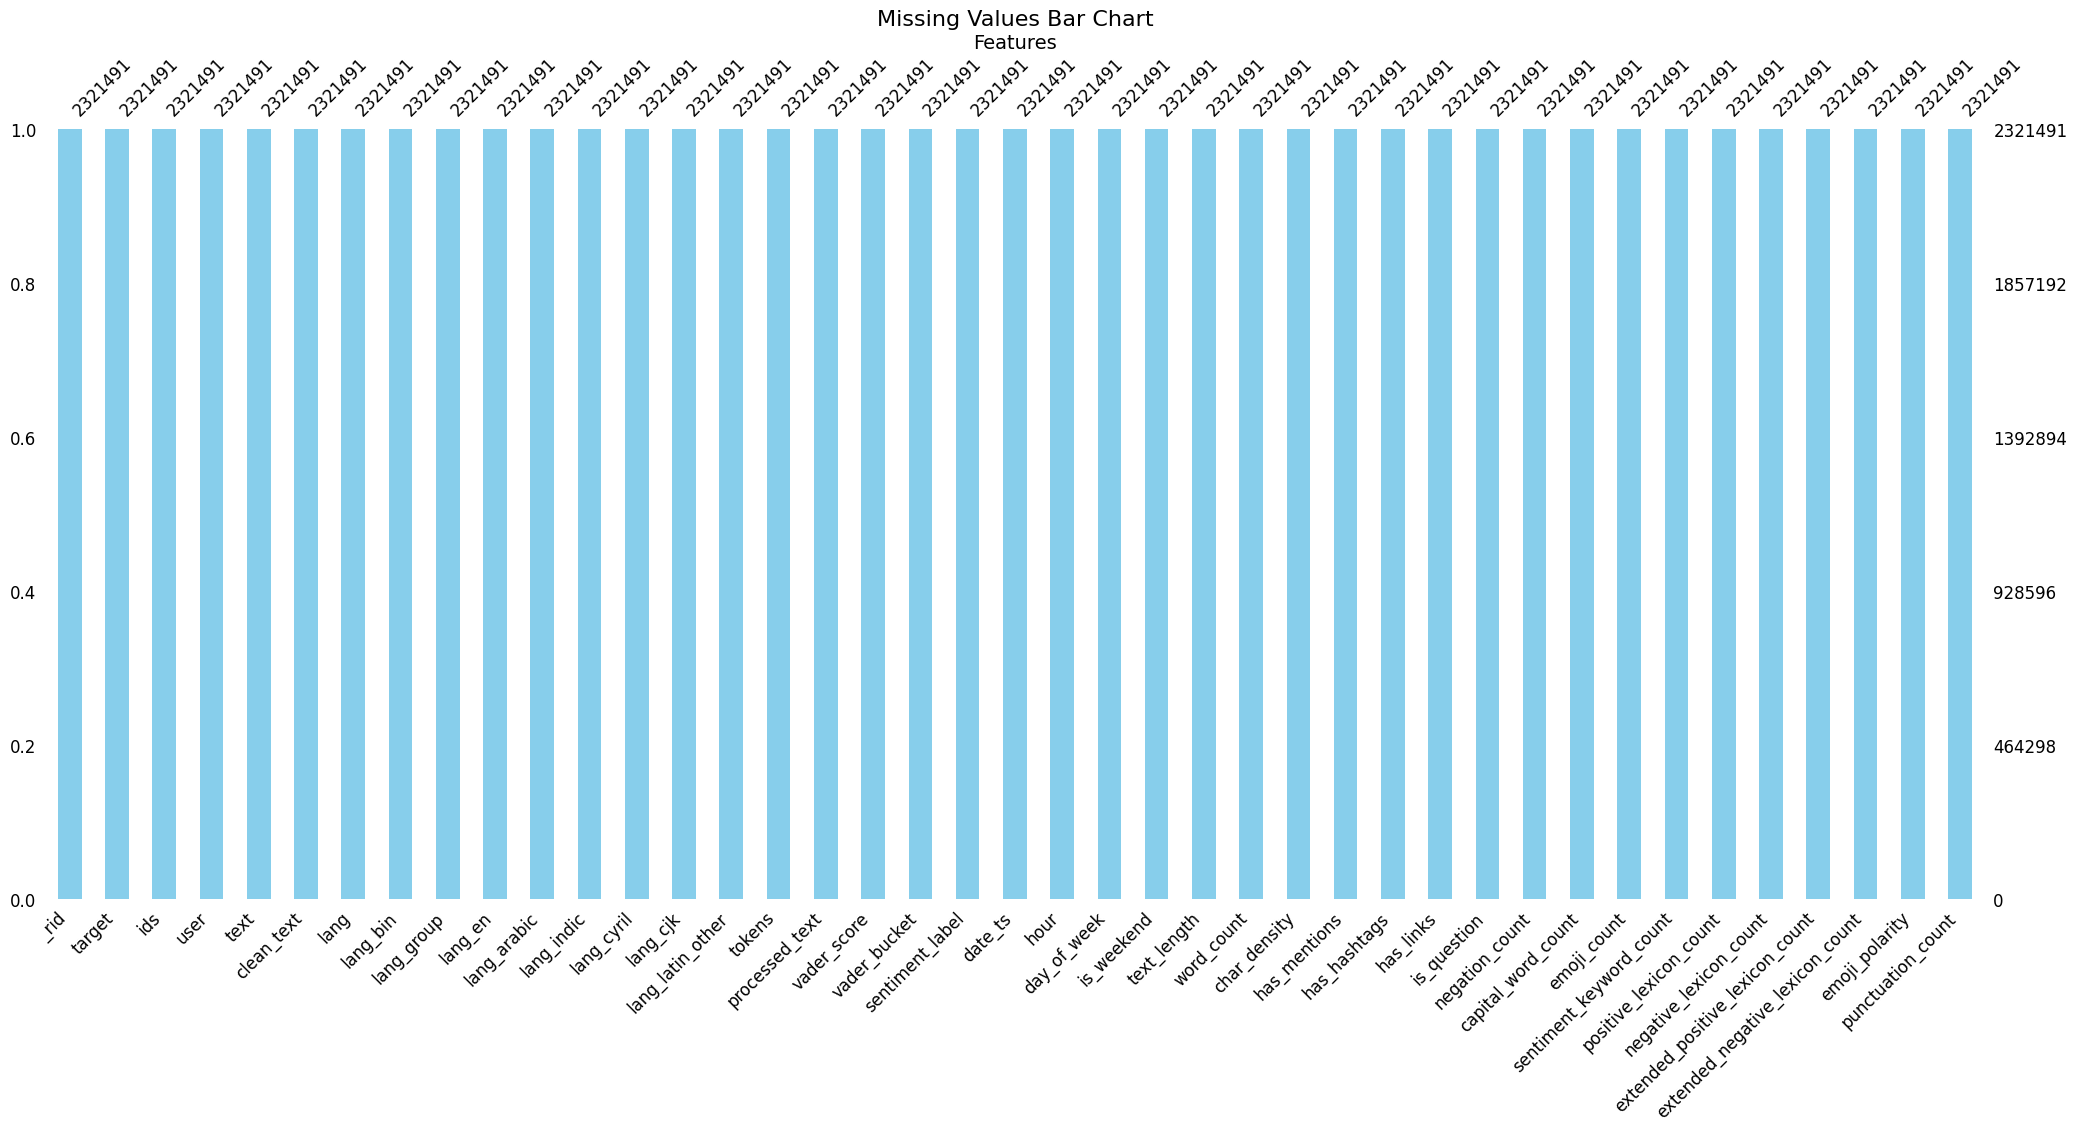

In [29]:
import matplotlib.pyplot as plt
import missingno as msno  # (if not already imported)


features_pd = combined_df.drop("sentiment").toPandas()
plt.figure(figsize=(10, 6))
msno.bar(features_pd, color='skyblue', fontsize=12)
plt.title('Missing Values Bar Chart', fontsize=16)
plt.xlabel('Features', fontsize=14)
plt.ylabel('Number of Missing Values', fontsize=14)
plt.show()

In [30]:
# Select all numeric columns including int32, int64, float64
numeric_cols = features_pd.select_dtypes(include=["int32", "int64", "float64", "double"]).columns.tolist()

print("Correct Numeric Columns:")
print(numeric_cols)
print(f"Total: {len(numeric_cols)}")

Correct Numeric Columns:
['_rid', 'target', 'lang_en', 'lang_arabic', 'lang_indic', 'lang_cyril', 'lang_cjk', 'lang_latin_other', 'vader_bucket', 'hour', 'day_of_week', 'is_weekend', 'text_length', 'word_count', 'char_density', 'has_mentions', 'has_hashtags', 'has_links', 'is_question', 'negation_count', 'capital_word_count', 'emoji_count', 'sentiment_keyword_count', 'positive_lexicon_count', 'negative_lexicon_count', 'extended_positive_lexicon_count', 'extended_negative_lexicon_count', 'emoji_polarity', 'punctuation_count']
Total: 29


✅ saved: correlation_full_numeric.png


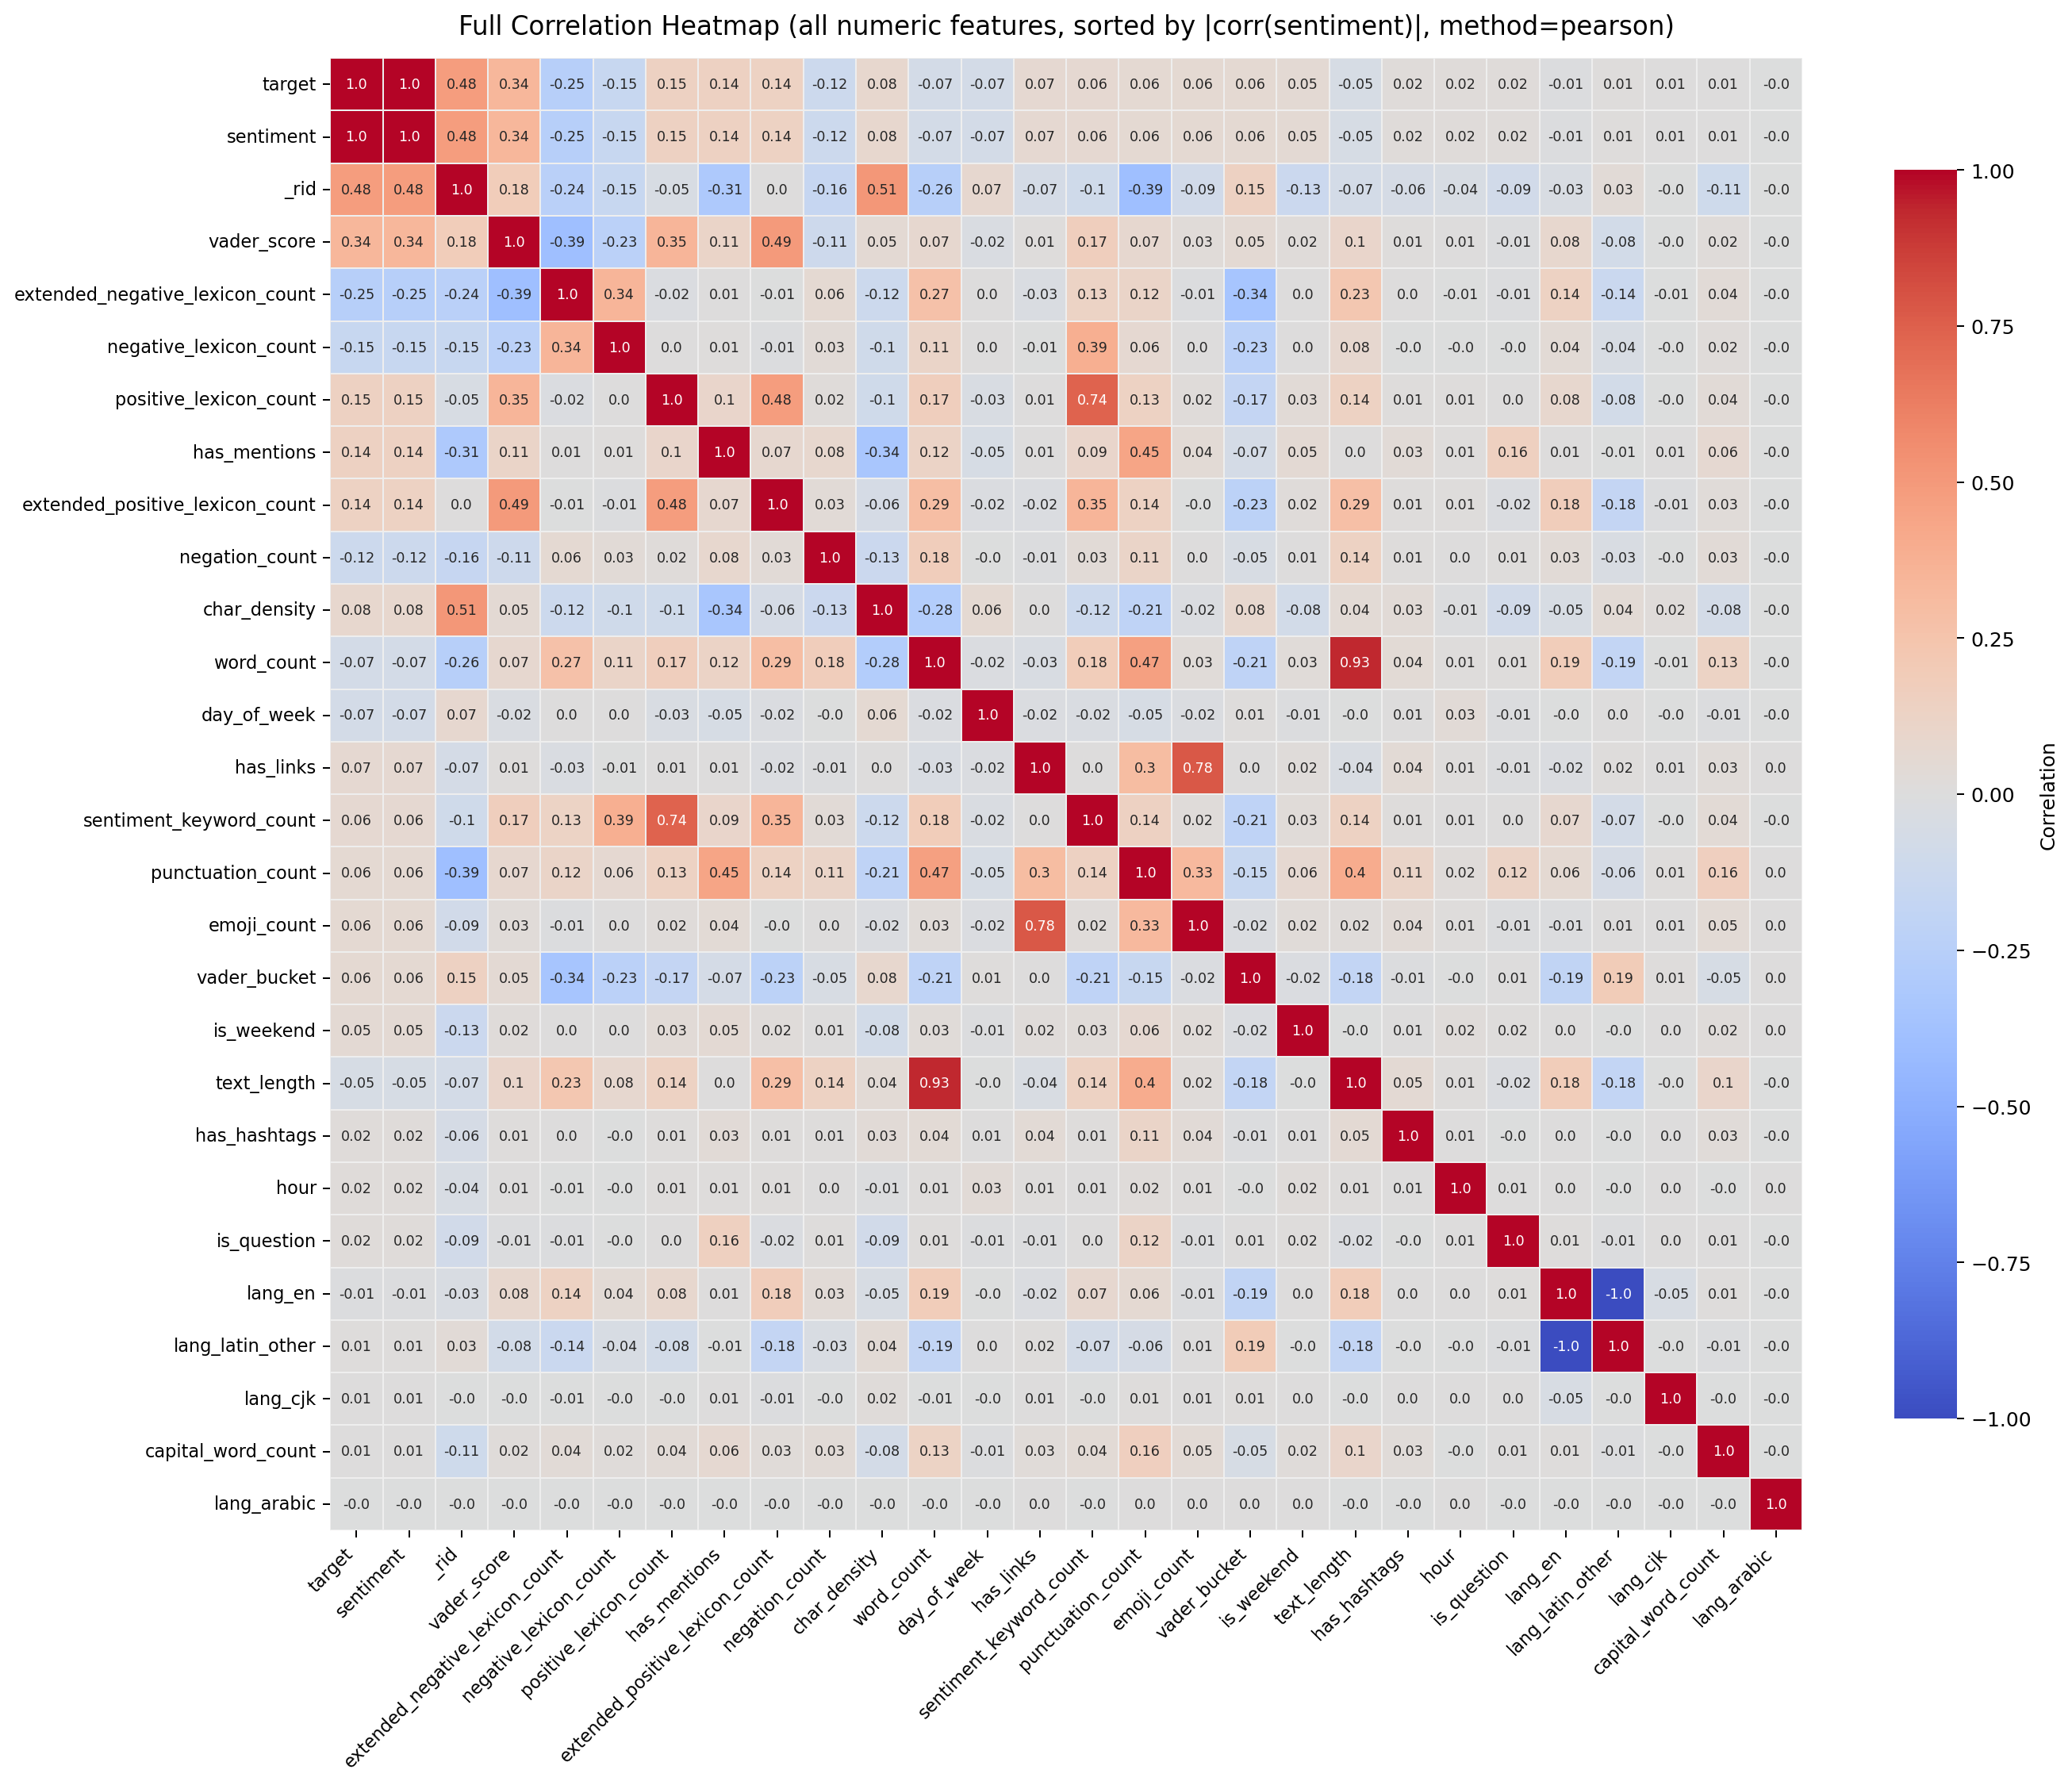

In [31]:
# ========= FULL correlation heatmap for ALL numeric features =========
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from pyspark.sql import functions as F

def plot_full_corr_heatmap(
    sdf,
    label_cols=("sentiment","target"),   # will sort by the first one that exists
    sample_frac=1.0,                      # use 1.0 for all rows (or e.g. 0.3 for speed)
    corr_method="pearson",               # or "spearman"
    annotate=True,                       # show numbers in cells
    annotate_threshold=0.00,             # set >0 (e.g. 0.05) to hide tiny values
    fig_scale=0.55,                      # scales figure size by #features
    dpi=180,
    save_path="correlation_full_numeric.png"
):
    # 1) choose label col if available
    cols_available = {c for c, _ in sdf.dtypes}
    y_col = next((c for c in label_cols if c in cols_available), None)

    # 2) keep numeric columns only
    numeric_types = ("int", "bigint", "float", "double", "smallint", "tinyint")
    num_cols = [c for c, t in sdf.dtypes if t.startswith(numeric_types)]
    if not num_cols:
        raise ValueError("No numeric columns found in the Spark DataFrame.")

    # (optional) sample for very large data
    sdf_tmp = sdf.sample(fraction=sample_frac, seed=42) if sample_frac < 1.0 else sdf

    # 3) to Pandas and clean
    pdf = sdf_tmp.select(*num_cols).toPandas()
    pdf = pdf.apply(pd.to_numeric, errors="coerce").astype(float)

    # drop constant/all-NaN columns
    std = pdf.std(numeric_only=True)
    keep = std[std > 0].index.tolist()
    pdf = pdf[keep]

    # 4) sort columns by |corr(y)| if label present
    if y_col and y_col in pdf.columns:
        order = (pdf.corr(method=corr_method)[y_col]
                   .abs()
                   .sort_values(ascending=False)
                   .index.tolist())
    else:
        order = pdf.columns.tolist()

    # 5) correlation on ordered columns (FULL matrix)
    corr = pdf[order].corr(method=corr_method)

    # 6) figure size scaled to #features
    n = len(order)
    fig_w = max(12, fig_scale * n)
    fig_h = fig_w
    plt.figure(figsize=(fig_w, fig_h), dpi=dpi)

    # 7) annotations (optionally hide tiny values)
    ann = None
    if annotate:
        ann = corr.round(2).astype(object)
        if annotate_threshold is not None and annotate_threshold > 0:
            ann = ann.where(corr.abs() >= annotate_threshold, "")

    ax = sns.heatmap(
        corr,
        vmin=-1, vmax=1, center=0,
        cmap="coolwarm", square=True,
        linewidths=0.6, linecolor="#eeeeee",
        annot=ann, fmt="", annot_kws={"fontsize":7},
        cbar_kws={"shrink":0.6, "label":"Correlation"}
    )

    # 8) tidy ticks & title
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", va="top", fontsize=9)
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0, ha="right", fontsize=9)
    title = "Full Correlation Heatmap (all numeric features"
    if y_col: title += f", sorted by |corr({y_col})|"
    title += f", method={corr_method})"
    ax.set_title(title, fontsize=13, pad=12)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, bbox_inches="tight", dpi=dpi)
        print(f"✅ saved: {save_path}")
    plt.show()

# ----- call it (after your feature engineering) -----
# use df_after if that’s your “post-transform” frame
plot_full_corr_heatmap(combined_df, label_cols=("sentiment","target"),
                       sample_frac=1.0, corr_method="pearson",
                       annotate=True, annotate_threshold=0.00,  # 0.00 = show all numbers
                       fig_scale=0.55, dpi=180,
                       save_path="correlation_full_numeric.png")


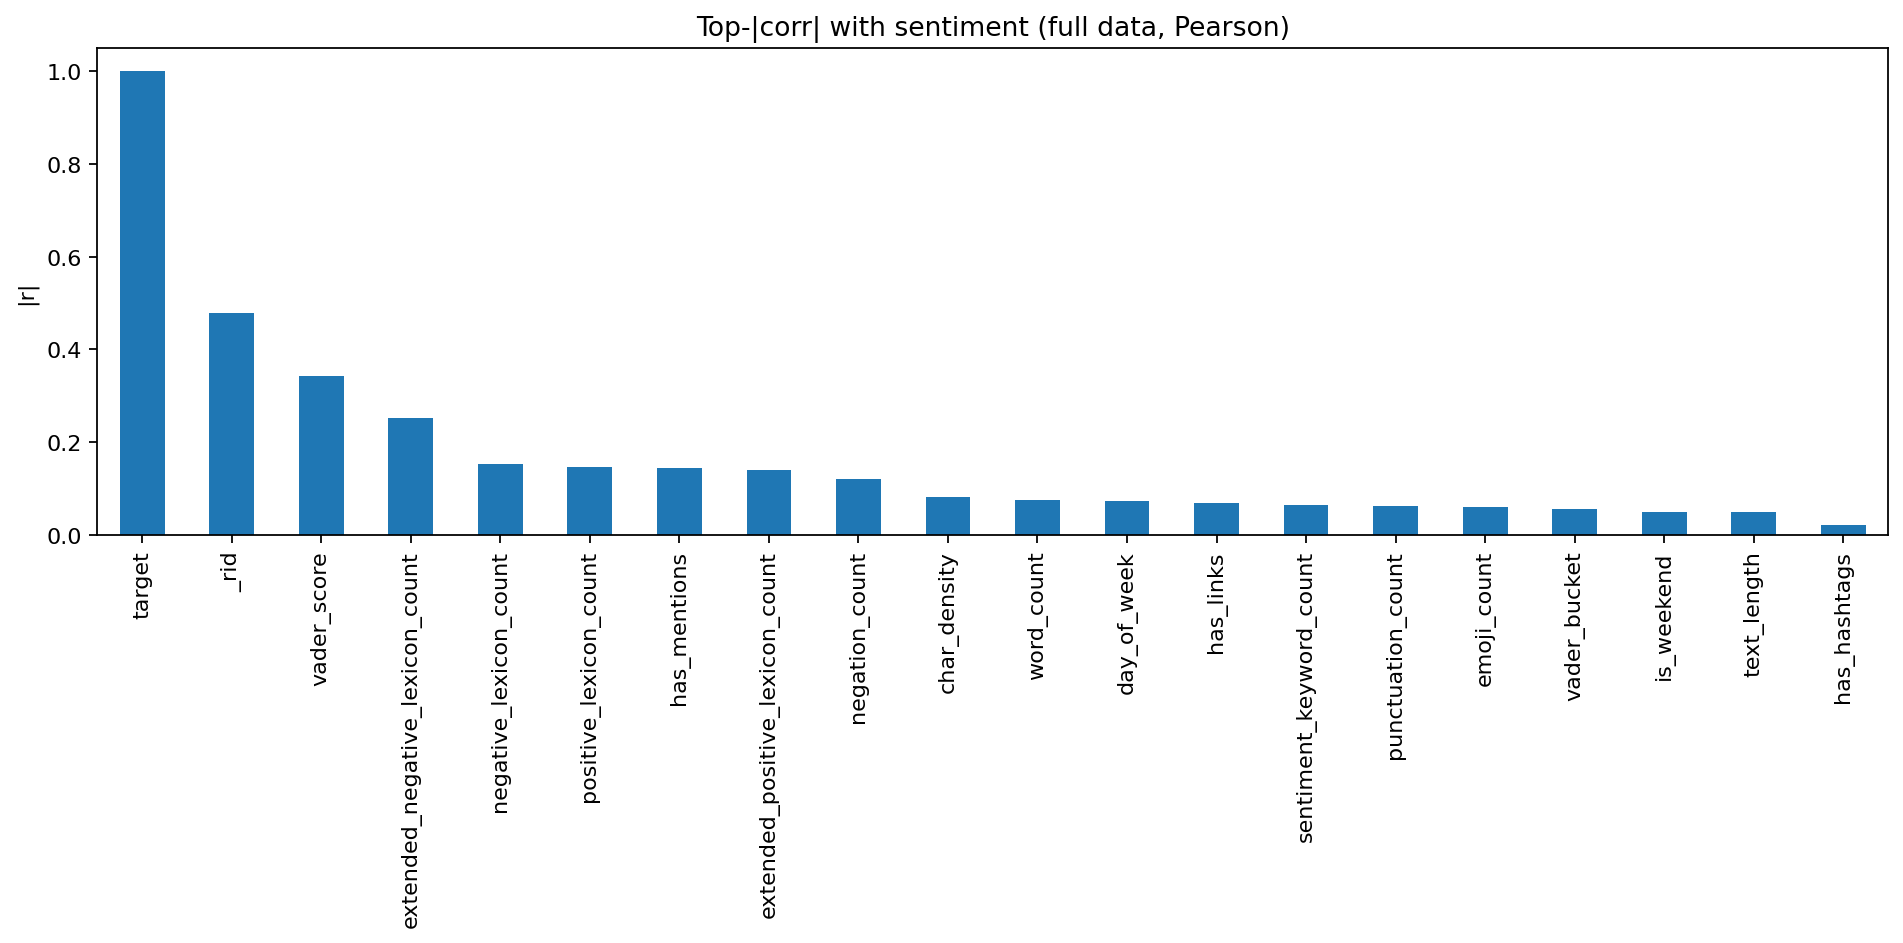

In [32]:
# === pick numeric columns automatically ===
num_types = ("int", "bigint", "float", "double", "smallint", "tinyint")
numeric_cols = [c for c,t in combined_df.dtypes if t.startswith(num_types) and c != "sentiment"]

# === compute correlations with sentiment in ONE pass using MLlib ===
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.stat import Correlation
import pandas as pd
import matplotlib.pyplot as plt

cols_for_corr = ["sentiment"] + numeric_cols

# drop rows with nulls in any of these columns to avoid NaNs in corr
df_corr = combined_df.select(*cols_for_corr).na.drop()

assembler = VectorAssembler(inputCols=cols_for_corr, outputCol="corr_vec", handleInvalid="skip")
df_vec = assembler.transform(df_corr).select("corr_vec")

corr_mat = Correlation.corr(df_vec, "corr_vec", method="pearson").head()[0].toArray()

# vector index 0 corresponds to 'sentiment'
corr_with_y = pd.Series(corr_mat[0, 1:], index=numeric_cols).abs().sort_values(ascending=False)

plt.figure(figsize=(12, 6), dpi=160)
corr_with_y.head(20).plot(kind="bar")
plt.title("Top-|corr| with sentiment (full data, Pearson)")
plt.ylabel("|r|"); plt.xlabel("")
plt.tight_layout(); plt.show()


In [33]:
# top languages by count
combined_df.groupBy("lang").count().orderBy(F.desc("count")).show(40, truncate=False)

# EN share (just to know)
total = combined_df.count()
en = combined_df.filter(F.col("lang")=="en").count()
print("EN share:", en/total)


+-------+-------+
|lang   |count  |
+-------+-------+
|en     |2199297|
|fr     |15446  |
|nl     |12158  |
|de     |12037  |
|es     |9404   |
|it     |9299   |
|da     |8309   |
|id     |6243   |
|no     |4631   |
|cy     |4510   |
|sv     |4005   |
|pt     |2911   |
|pl     |2904   |
|ca     |2411   |
|ro     |2126   |
|tl     |1716   |
|af     |1705   |
|br     |1678   |
|sw     |1314   |
|mt     |1298   |
|la     |1199   |
|et     |1159   |
|eu     |1146   |
|unknown|1088   |
|fi     |1057   |
|ms     |980    |
|sl     |880    |
|hr     |879    |
|cs     |755    |
|nb     |700    |
|nn     |596    |
|mg     |560    |
|hu     |544    |
|vi     |522    |
|qu     |515    |
|ga     |509    |
|wa     |505    |
|sq     |385    |
|eo     |328    |
|lt     |295    |
+-------+-------+
only showing top 40 rows

EN share: 0.9473640001188891


## Skewness Reduction and Outlier Handling

In [34]:
from pyspark.sql import functions as F
cols = ["text_length","word_count","punctuation_count","negation_count","emoji_count"]
stats = {}
for c in cols:
    p99 = combined_df.approxQuantile(c, [0.99], 0.001)[0]
    mx  = combined_df.agg(F.max(c)).first()[0]
    stats[c] = {"p99": p99, "max": mx, "max_over_p99": (mx/(p99+1e-9))}
print(stats)


{'text_length': {'p99': 133.0, 'max': 133.0, 'max_over_p99': 0.9999999999924812}, 'word_count': {'p99': 28.0, 'max': 28.0, 'max_over_p99': 0.9999999999642857}, 'punctuation_count': {'p99': 2.639057329615259, 'max': 3.4339872044851463, 'max_over_p99': 1.301217356913031}, 'negation_count': {'p99': 0.6931471805599453, 'max': 2.5649493574615367, 'max_over_p99': 3.7004397128024866}, 'emoji_count': {'p99': 0.6931471805599453, 'max': 1.791759469228055, 'max_over_p99': 2.5849624969918437}}


In [35]:
# Example: write EN & non-EN feature tables to Parquet for downstream sklearn training
(out_text, out_label) = ("clean_text", "sentiment")

# Keep the engineered numeric columns you’ll feed alongside TF-IDF
NUMERIC_COLS = [
    "vader_score","vader_bucket","hour","day_of_week","is_weekend",
    "text_length","word_count","char_density",
    "has_mentions","has_hashtags","has_links","is_question",
    "sentiment_keyword_count","negation_count","capital_word_count","emoji_count",
    "positive_lexicon_count","negative_lexicon_count",
    "punctuation_count",
    "extended_positive_lexicon_count","extended_negative_lexicon_count",
    "lang_en","lang_arabic","lang_indic","lang_cyril","lang_cjk","lang_latin_other",
    "emoji_polarity",
]

en_df.select(out_text, out_label, *NUMERIC_COLS).write.mode("overwrite").parquet("fe/en_base.parquet")
non_en_df.select(out_text, out_label, *NUMERIC_COLS).write.mode("overwrite").parquet("fe/non_en_base.parquet")


# Model Training 

In [36]:
# =========================
# Cleanly stop Spark
# =========================
def stop_spark_if_running():
    try:
        from pyspark.sql import SparkSession
        ss = SparkSession.getActiveSession()
        if ss is not None:
            ss.stop()
    except Exception:
        pass

try:
    sc.stop()  # if 'sc' exists
except Exception:
    pass

stop_spark_if_running()

# free big Spark DFs from memory (optional)
for name in list(globals().keys()):
    if name.startswith(("df_", "combined_df", "df_after", "df_ready", "featurized", "featurized_en", "featurized_non")):
        try: del globals()[name]
        except: pass

import gc; gc.collect()
print("✅ Spark stopped. Ready for Python-only training.")


✅ Spark stopped. Ready for Python-only training.


## Machine Learning Models

In [37]:
# ============================
# Train EN & non-EN Logistic Regression with TF-IDF + numeric
# ============================
# Run this *after* stopping Spark.
# If needed: pip install scikit-learn joblib pyarrow

import os, json
import numpy as np
import pandas as pd
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import MaxAbsScaler, label_binarize
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, classification_report,
    roc_curve, auc, roc_auc_score,
    precision_recall_curve, average_precision_score
)
import matplotlib.pyplot as plt
import joblib

# ------------ paths ------------
EN_PATH     = "fe/en_base.parquet"
NON_EN_PATH = "fe/non_en_base.parquet"
ART_DIR     = Path("artifacts_models")
ART_DIR.mkdir(parents=True, exist_ok=True)

# ------------ shared config ------------
SEED = 42
TEXT_COL = "clean_text"
LABEL_COL = "sentiment"

# Keep the engineered numeric columns you exported
NUMERIC_COLS = [
    "vader_score","vader_bucket","hour","day_of_week","is_weekend",
    "text_length","word_count","char_density",
    "has_mentions","has_hashtags","has_links","is_question",
    "sentiment_keyword_count","negation_count","capital_word_count","emoji_count",
    "positive_lexicon_count","negative_lexicon_count",
    "punctuation_count",
    "extended_positive_lexicon_count","extended_negative_lexicon_count",
    "lang_en","lang_arabic","lang_indic","lang_cyril","lang_cjk","lang_latin_other",
    "emoji_polarity",
]

# For non-EN, drop VADER features (English-tuned)
NON_EN_NUMERIC = [c for c in NUMERIC_COLS if c not in ("vader_score","vader_bucket")]
EN_NUMERIC     = NUMERIC_COLS[:]  # keep all for English

# ------------ utilities ------------
def load_df(path):
    df = pd.read_parquet(path)  # requires pyarrow or fastparquet
    # basic hygiene
    df = df[[TEXT_COL, LABEL_COL] + [c for c in df.columns if c in NUMERIC_COLS]].copy()
    df = df.dropna(subset=[TEXT_COL, LABEL_COL])
    # ensure ints for target
    df[LABEL_COL] = df[LABEL_COL].astype(int)
    return df

def build_pipeline(mode="en"):
    """Create ColumnTransformer + LogisticRegression pipeline."""
    if mode == "en":
        tfidf = TfidfVectorizer(
            analyzer="word", ngram_range=(1,2),
            min_df=2, max_df=0.9, lowercase=False, sublinear_tf=True,
            max_features=200_000
        )
        num_cols = EN_NUMERIC
    else:
        tfidf = TfidfVectorizer(
            analyzer="char_wb", ngram_range=(3,5),
            min_df=2, max_df=0.95, lowercase=False, sublinear_tf=True,
            max_features=200_000
        )
        num_cols = NON_EN_NUMERIC

    pre = ColumnTransformer([
        ("tfidf", tfidf, TEXT_COL),
        ("num", MaxAbsScaler(), num_cols),
    ], sparse_threshold=1.0)

    clf = LogisticRegression(
        solver="saga", max_iter=2000,
        class_weight="balanced", # helpful for label imbalance
        n_jobs=None,             # saga ignores n_jobs
        multi_class="auto",
        random_state=SEED
    )

    return Pipeline([("prep", pre), ("clf", clf)]), num_cols

def plot_roc(y_true, proba, classes_order, out_png):
    """Micro-average ROC for multi-class."""
    y_bin = label_binarize(y_true, classes=classes_order)
    # micro-average
    fpr, tpr, _ = roc_curve(y_bin.ravel(), proba.ravel())
    roc_auc = auc(fpr, tpr)

    plt.figure()
    plt.plot(fpr, tpr, label=f"micro-average ROC (AUC = {roc_auc:.3f})")
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC curve (micro-average)")
    plt.legend(loc="lower right")
    plt.tight_layout()
    plt.savefig(out_png, dpi=160)
    plt.close()
    return roc_auc

def plot_pr(y_true, proba, classes_order, out_png):
    """Micro-average Precision-Recall."""
    y_bin = label_binarize(y_true, classes=classes_order)
    precision, recall, _ = precision_recall_curve(y_bin.ravel(), proba.ravel())
    ap_micro = average_precision_score(y_bin, proba, average="micro")

    plt.figure()
    plt.plot(recall, precision, label=f"micro-average PR (AP = {ap_micro:.3f})")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title("Precision–Recall curve (micro-average)")
    plt.legend(loc="lower left")
    plt.tight_layout()
    plt.savefig(out_png, dpi=160)
    plt.close()
    return ap_micro

def train_eval_one(df, mode, model_tag):
    """Train, evaluate, plot, and save."""
    pipe, used_num_cols = build_pipeline(mode=mode)

    # split
    X_train, X_test, y_train, y_test = train_test_split(
        df[[TEXT_COL] + used_num_cols], df[LABEL_COL],
        test_size=0.2, stratify=df[LABEL_COL], random_state=SEED
    )

    # fit
    pipe.fit(X_train, y_train)

    # classes order from fitted clf (important for proba column order)
    classes_order = pipe.named_steps["clf"].classes_

    # ---- metrics: train ----
    y_pred_tr = pipe.predict(X_train)
    acc_tr = accuracy_score(y_train, y_pred_tr)
    cr_tr = classification_report(
        y_train, y_pred_tr, digits=3,
        labels=classes_order, zero_division=0,
        target_names=[f"class_{c}" for c in classes_order]
    )

    # ---- metrics: test ----
    y_pred_te = pipe.predict(X_test)
    acc_te = accuracy_score(y_test, y_pred_te)
    cr_te = classification_report(
        y_test, y_pred_te, digits=3,
        labels=classes_order, zero_division=0,
        target_names=[f"class_{c}" for c in classes_order]
    )

    # ---- probabilities for ROC/PR (OvR micro-average) ----
    proba_te = pipe.predict_proba(X_test)
    # Micro ROC-AUC
    roc_png = ART_DIR / f"{model_tag}_roc.png"
    roc_auc_micro = plot_roc(y_test, proba_te, classes_order, roc_png)
    # Micro PR
    pr_png = ART_DIR / f"{model_tag}_pr.png"
    ap_micro = plot_pr(y_test, proba_te, classes_order, pr_png)

    # Also compute a scalar AUC using sklearn's multiclass metric (macro)
    auc_macro = roc_auc_score(
        y_test, proba_te, multi_class="ovr", average="macro"
    )

    # save model
    model_path = ART_DIR / f"{model_tag}_logreg.joblib"
    joblib.dump(pipe, model_path)

    # save a summary json
    summary = {
        "model_tag": model_tag,
        "mode": mode,
        "train_accuracy": float(acc_tr),
        "test_accuracy": float(acc_te),
        "roc_auc_micro": float(roc_auc_micro),
        "roc_auc_macro_ovr": float(auc_macro),
        "avg_precision_micro": float(ap_micro),
        "classes_order": [int(c) for c in classes_order],
        "numeric_features_used": used_num_cols,
        "artifacts": {
            "model": str(model_path),
            "roc_png": str(roc_png),
            "pr_png": str(pr_png),
        }
    }
    with open(ART_DIR / f"{model_tag}_summary.json", "w") as f:
        json.dump(summary, f, indent=2)

    # write classification reports
    with open(ART_DIR / f"{model_tag}_classification_report_train.txt", "w") as f:
        f.write(cr_tr)
    with open(ART_DIR / f"{model_tag}_classification_report_test.txt", "w") as f:
        f.write(cr_te)

    # print to console
    print(f"\n===== {model_tag.upper()} =====")
    print(f"Train accuracy: {acc_tr:.4f}")
    print(f"Test  accuracy: {acc_te:.4f}")
    print(f"ROC-AUC micro: {roc_auc_micro:.4f} | ROC-AUC macro(ovr): {auc_macro:.4f}")
    print(f"Avg Precision (PR, micro): {ap_micro:.4f}")
    print("\n--- Classification Report (TRAIN) ---")
    print(cr_tr)
    print("--- Classification Report (TEST) ---")
    print(cr_te)
    print(f"Saved model → {model_path}")
    print(f"Saved ROC plot → {roc_png}")
    print(f"Saved PR  plot → {pr_png}")
    print(f"Saved summary → {ART_DIR / f'{model_tag}_summary.json'}")

# ------------ run both models ------------
if __name__ == "__main__":
    # English
    en_df = load_df(EN_PATH)
    train_eval_one(en_df, mode="en", model_tag="en")

    # Non-English
    non_en_df = load_df(NON_EN_PATH)
    train_eval_one(non_en_df, mode="non_en", model_tag="non_en")


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(



===== EN =====
Train accuracy: 0.8962
Test  accuracy: 0.8731
ROC-AUC micro: 0.9752 | ROC-AUC macro(ovr): 0.9632
Avg Precision (PR, micro): 0.9525

--- Classification Report (TRAIN) ---
              precision    recall  f1-score   support

     class_0      0.853     0.834     0.843    589293
     class_1      0.999     1.000     0.999    591434
     class_2      0.835     0.854     0.844    578710

    accuracy                          0.896   1759437
   macro avg      0.896     0.896     0.896   1759437
weighted avg      0.896     0.896     0.896   1759437

--- Classification Report (TEST) ---
              precision    recall  f1-score   support

     class_0      0.819     0.798     0.809    147323
     class_1      0.999     1.000     0.999    147859
     class_2      0.800     0.820     0.810    144678

    accuracy                          0.873    439860
   macro avg      0.873     0.873     0.873    439860
weighted avg      0.873     0.873     0.873    439860

Saved model → a

/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(



===== NON_EN =====
Train accuracy: 0.9260
Test  accuracy: 0.8840
ROC-AUC micro: 0.9785 | ROC-AUC macro(ovr): 0.9668
Avg Precision (PR, micro): 0.9587

--- Classification Report (TRAIN) ---
              precision    recall  f1-score   support

     class_0      0.870     0.868     0.869     27498
     class_1      0.999     0.999     0.999     39676
     class_2      0.882     0.883     0.882     30581

    accuracy                          0.926     97755
   macro avg      0.917     0.917     0.917     97755
weighted avg      0.926     0.926     0.926     97755

--- Classification Report (TEST) ---
              precision    recall  f1-score   support

     class_0      0.798     0.790     0.794      6875
     class_1      0.997     0.999     0.998      9919
     class_2      0.814     0.819     0.817      7645

    accuracy                          0.884     24439
   macro avg      0.870     0.869     0.870     24439
weighted avg      0.884     0.884     0.884     24439

Saved model

**Check Any leakage**

In [39]:
import pandas as pd
from sklearn.model_selection import train_test_split

SEED = 42
TEXT_COL = "clean_text"
LABEL_COL = "sentiment"

NUMERIC_COLS = [
    "vader_score","vader_bucket","hour","day_of_week","is_weekend",
    "text_length","word_count","char_density",
    "has_mentions","has_hashtags","has_links","is_question",
    "sentiment_keyword_count","negation_count","capital_word_count","emoji_count",
    "positive_lexicon_count","negative_lexicon_count",
    "punctuation_count",
    "extended_positive_lexicon_count","extended_negative_lexicon_count",
    "lang_en","lang_arabic","lang_indic","lang_cyril","lang_cjk","lang_latin_other",
    "emoji_polarity",
]
EN_NUMERIC     = NUMERIC_COLS[:]
NON_EN_NUMERIC = [c for c in NUMERIC_COLS if c not in ("vader_score","vader_bucket")]

def label_dist(path, mode):
    df = pd.read_parquet(path)
    df = df[[TEXT_COL, LABEL_COL] + [c for c in df.columns if c in NUMERIC_COLS]].dropna(subset=[TEXT_COL, LABEL_COL])
    df[LABEL_COL] = df[LABEL_COL].astype(int)
    used = EN_NUMERIC if mode=="en" else NON_EN_NUMERIC

    X_train, X_test, y_train, y_test = train_test_split(
        df[[TEXT_COL] + used], df[LABEL_COL],
        test_size=0.2, stratify=df[LABEL_COL], random_state=SEED
    )
    for name, y in [(f"{mode} train", y_train), (f"{mode} test", y_test)]:
        counts = pd.Series(y).value_counts().sort_index()
        props  = (counts / counts.sum()).round(3)
        print(f"\n{name} counts:\n{counts.to_string()}")
        print(f"{name} proportions:\n{props.to_string()}")

label_dist("fe/en_base.parquet", "en")
label_dist("fe/non_en_base.parquet", "non_en")



en train counts:
sentiment
0    589293
1    591434
2    578710
en train proportions:
sentiment
0    0.335
1    0.336
2    0.329

en test counts:
sentiment
0    147323
1    147859
2    144678
en test proportions:
sentiment
0    0.335
1    0.336
2    0.329

non_en train counts:
sentiment
0    27498
1    39676
2    30581
non_en train proportions:
sentiment
0    0.281
1    0.406
2    0.313

non_en test counts:
sentiment
0    6875
1    9919
2    7645
non_en test proportions:
sentiment
0    0.281
1    0.406
2    0.313


In [1]:
# ============================
# Train EN & non-EN RandomForest with TF-IDF + numeric
# ============================
# pip install scikit-learn joblib pyarrow

import os, json
import numpy as np
import pandas as pd
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import MaxAbsScaler, label_binarize, FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, classification_report,
    roc_curve, auc, roc_auc_score,
    precision_recall_curve, average_precision_score
)
import matplotlib.pyplot as plt
import joblib
import scipy.sparse as sp

import scipy.sparse as sp

def to_csr(X):
    return sp.csr_matrix(X)

def make_sparse_numeric():
    # scale -> sparse CSR (picklable now)
    return Pipeline([
        ("scale", MaxAbsScaler()),
        ("to_sparse", FunctionTransformer(to_csr, accept_sparse=True,
                                          check_inverse=False, validate=False))
    ])

# ------------ paths ------------
EN_PATH     = "fe/en_base.parquet"
NON_EN_PATH = "fe/non_en_base.parquet"
ART_DIR     = Path("artifacts_models_rf")
ART_DIR.mkdir(parents=True, exist_ok=True)

# ------------ shared config ------------
SEED = 42
TEXT_COL = "clean_text"
LABEL_COL = "sentiment"

NUMERIC_COLS = [
    "vader_score","vader_bucket","hour","day_of_week","is_weekend",
    "text_length","word_count","char_density",
    "has_mentions","has_hashtags","has_links","is_question",
    "sentiment_keyword_count","negation_count","capital_word_count","emoji_count",
    "positive_lexicon_count","negative_lexicon_count",
    "punctuation_count",
    "extended_positive_lexicon_count","extended_negative_lexicon_count",
    "lang_en","lang_arabic","lang_indic","lang_cyril","lang_cjk","lang_latin_other",
    "emoji_polarity",
]
NON_EN_NUMERIC = [c for c in NUMERIC_COLS if c not in ("vader_score","vader_bucket")]
EN_NUMERIC     = NUMERIC_COLS[:]

# ------------ utilities ------------
def load_df(path):
    df = pd.read_parquet(path)
    df = df[[TEXT_COL, LABEL_COL] + [c for c in df.columns if c in NUMERIC_COLS]].copy()
    df = df.dropna(subset=[TEXT_COL, LABEL_COL])
    df[LABEL_COL] = df[LABEL_COL].astype(int)
    return df


def build_pipeline_rf(mode="en"):
    if mode == "en":
        tfidf = TfidfVectorizer(
            analyzer="word", ngram_range=(1,2),
            min_df=2, max_df=0.9, lowercase=False, sublinear_tf=True,
            max_features=200_000
        )
        num_cols = EN_NUMERIC
    else:
        tfidf = TfidfVectorizer(
            analyzer="char_wb", ngram_range=(3,5),
            min_df=2, max_df=0.95, lowercase=False, sublinear_tf=True,
            max_features=200_000
        )
        num_cols = NON_EN_NUMERIC

    pre = ColumnTransformer([
        ("tfidf", tfidf, TEXT_COL),
        ("num", make_sparse_numeric(), num_cols),
    ], sparse_threshold=1.0)  # require sparse output

    # Tip: RF with very high-dim TF-IDF can be heavy; tune n_estimators/max_depth as needed
    clf = RandomForestClassifier(
        n_estimators=300,
        max_depth=None,               # try 20–40 to regularize if needed
        max_features="sqrt",
        class_weight="balanced_subsample",
        n_jobs=-1,
        random_state=SEED
    )
    return Pipeline([("prep", pre), ("clf", clf)]), num_cols

def plot_roc(y_true, proba, classes_order, out_png):
    y_bin = label_binarize(y_true, classes=classes_order)
    fpr, tpr, _ = roc_curve(y_bin.ravel(), proba.ravel())
    roc_auc = auc(fpr, tpr)
    plt.figure()
    plt.plot(fpr, tpr, label=f"micro-average ROC (AUC = {roc_auc:.3f})")
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
    plt.title("ROC curve (micro-average)")
    plt.legend(loc="lower right"); plt.tight_layout()
    plt.savefig(out_png, dpi=160); plt.close()
    return roc_auc

def plot_pr(y_true, proba, classes_order, out_png):
    y_bin = label_binarize(y_true, classes=classes_order)
    precision, recall, _ = precision_recall_curve(y_bin.ravel(), proba.ravel())
    ap_micro = average_precision_score(y_bin, proba, average="micro")
    plt.figure()
    plt.plot(recall, precision, label=f"micro-average PR (AP = {ap_micro:.3f})")
    plt.xlabel("Recall"); plt.ylabel("Precision")
    plt.title("Precision–Recall curve (micro-average)")
    plt.legend(loc="lower left"); plt.tight_layout()
    plt.savefig(out_png, dpi=160); plt.close()
    return ap_micro

def train_eval_one_rf(df, mode, model_tag):
    pipe, used_num_cols = build_pipeline_rf(mode=mode)

    X_train, X_test, y_train, y_test = train_test_split(
        df[[TEXT_COL] + used_num_cols], df[LABEL_COL],
        test_size=0.2, stratify=df[LABEL_COL], random_state=SEED
    )

    pipe.fit(X_train, y_train)
    classes_order = pipe.named_steps["clf"].classes_

    # ---- metrics: train ----
    y_pred_tr = pipe.predict(X_train)
    acc_tr = accuracy_score(y_train, y_pred_tr)
    cr_tr = classification_report(
        y_train, y_pred_tr, digits=3,
        labels=classes_order, zero_division=0,
        target_names=[f"class_{c}" for c in classes_order]
    )

    # ---- metrics: test ----
    y_pred_te = pipe.predict(X_test)
    acc_te = accuracy_score(y_test, y_pred_te)
    cr_te = classification_report(
        y_test, y_pred_te, digits=3,
        labels=classes_order, zero_division=0,
        target_names=[f"class_{c}" for c in classes_order]
    )

    # ---- probabilities & curves ----
    proba_te = pipe.predict_proba(X_test)
    roc_png = ART_DIR / f"{model_tag}_roc.png"
    pr_png  = ART_DIR / f"{model_tag}_pr.png"
    roc_auc_micro = plot_roc(y_test, proba_te, classes_order, roc_png)
    ap_micro = plot_pr(y_test, proba_te, classes_order, pr_png)
    auc_macro = roc_auc_score(y_test, proba_te, multi_class="ovr", average="macro")

    # save model
    model_path = ART_DIR / f"{model_tag}_rf.joblib"
    joblib.dump(pipe, model_path)

    # save summaries
    summary = {
        "model_tag": model_tag,
        "mode": mode,
        "train_accuracy": float(acc_tr),
        "test_accuracy": float(acc_te),
        "roc_auc_micro": float(roc_auc_micro),
        "roc_auc_macro_ovr": float(auc_macro),
        "avg_precision_micro": float(ap_micro),
        "classes_order": [int(c) for c in classes_order],
        "numeric_features_used": used_num_cols,
        "artifacts": {"model": str(model_path), "roc_png": str(roc_png), "pr_png": str(pr_png)}
    }
    with open(ART_DIR / f"{model_tag}_summary.json", "w") as f:
        json.dump(summary, f, indent=2)
    with open(ART_DIR / f"{model_tag}_classification_report_train.txt", "w") as f:
        f.write(cr_tr)
    with open(ART_DIR / f"{model_tag}_classification_report_test.txt", "w") as f:
        f.write(cr_te)

    print(f"\n===== {model_tag.upper()} (RandomForest) =====")
    print(f"Train accuracy: {acc_tr:.4f}")
    print(f"Test  accuracy: {acc_te:.4f}")
    print(f"ROC-AUC micro: {roc_auc_micro:.4f} | ROC-AUC macro(ovr): {auc_macro:.4f}")
    print(f"Avg Precision (PR, micro): {ap_micro:.4f}")
    print("\n--- Classification Report (TRAIN) ---")
    print(cr_tr)
    print("--- Classification Report (TEST) ---")
    print(cr_te)
    print(f"Saved model → {model_path}")
    print(f"Saved ROC plot → {roc_png}")
    print(f"Saved PR  plot → {pr_png}")
    print(f"Saved summary → {ART_DIR / f'{model_tag}_summary.json'}")

# ------------ run both models ------------
if __name__ == "__main__":
    en_df = load_df(EN_PATH)
    train_eval_one_rf(en_df, mode="en", model_tag="en")

    non_en_df = load_df(NON_EN_PATH)
    train_eval_one_rf(non_en_df, mode="non_en", model_tag="non_en")



===== EN (RandomForest) =====
Train accuracy: 0.9994
Test  accuracy: 0.8531
ROC-AUC micro: 0.9685 | ROC-AUC macro(ovr): 0.9536
Avg Precision (PR, micro): 0.9395

--- Classification Report (TRAIN) ---
              precision    recall  f1-score   support

     class_0      0.999     0.999     0.999    589293
     class_1      1.000     1.000     1.000    591434
     class_2      0.999     0.999     0.999    578710

    accuracy                          0.999   1759437
   macro avg      0.999     0.999     0.999   1759437
weighted avg      0.999     0.999     0.999   1759437

--- Classification Report (TEST) ---
              precision    recall  f1-score   support

     class_0      0.786     0.774     0.780    147323
     class_1      0.996     1.000     0.998    147859
     class_2      0.774     0.785     0.779    144678

    accuracy                          0.853    439860
   macro avg      0.852     0.853     0.852    439860
weighted avg      0.853     0.853     0.853    439860



In [2]:
# ============================
# Train EN & non-EN XGBoost with TF-IDF + numeric
# ============================
# pip install xgboost scikit-learn joblib pyarrow

import os, json
import numpy as np

import pandas as pd
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import MaxAbsScaler, label_binarize, FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, classification_report,
    roc_curve, auc, roc_auc_score,
    precision_recall_curve, average_precision_score
)
import matplotlib.pyplot as plt
import joblib
import scipy.sparse as sp
import xgboost as xgb

# ------------ paths ------------
EN_PATH     = "fe/en_base.parquet"
NON_EN_PATH = "fe/non_en_base.parquet"
ART_DIR     = Path("artifacts_models_xgb")
ART_DIR.mkdir(parents=True, exist_ok=True)

# ------------ shared config ------------
SEED = 42
TEXT_COL = "clean_text"
LABEL_COL = "sentiment"

# Keep your engineered numeric features
NUMERIC_COLS = [
    "vader_score","vader_bucket","hour","day_of_week","is_weekend",
    "text_length","word_count","char_density",
    "has_mentions","has_hashtags","has_links","is_question",
    "sentiment_keyword_count","negation_count","capital_word_count","emoji_count",
    "positive_lexicon_count","negative_lexicon_count",
    "punctuation_count",
    "extended_positive_lexicon_count","extended_negative_lexicon_count",
    "lang_en","lang_arabic","lang_indic","lang_cyril","lang_cjk","lang_latin_other",
    "emoji_polarity",
]
NON_EN_NUMERIC = [c for c in NUMERIC_COLS if c not in ("vader_score","vader_bucket")]
EN_NUMERIC     = NUMERIC_COLS[:]

# ------------ utils ------------
def load_df(path):
    df = pd.read_parquet(path)
    df = df[[TEXT_COL, LABEL_COL] + [c for c in df.columns if c in NUMERIC_COLS]].copy()
    df = df.dropna(subset=[TEXT_COL, LABEL_COL])
    df[LABEL_COL] = df[LABEL_COL].astype(int)
    return df

def to_csr(X):
    return sp.csr_matrix(X)

def make_sparse_numeric():
    # scale numeric → CSR so ColumnTransformer stays sparse end-to-end
    return Pipeline([
        ("scale", MaxAbsScaler()),
        ("to_sparse", FunctionTransformer(to_csr, accept_sparse=True,
                                          check_inverse=False, validate=False))
    ])

def build_pipeline_xgb(mode="en", xgb_params=None):
    if mode == "en":
        tfidf = TfidfVectorizer(
            analyzer="word", ngram_range=(1,2),
            min_df=2, max_df=0.9, lowercase=False, sublinear_tf=True,
            max_features=200_000
        )
        num_cols = EN_NUMERIC
    else:
        tfidf = TfidfVectorizer(
            analyzer="char_wb", ngram_range=(3,5),
            min_df=2, max_df=0.95, lowercase=False, sublinear_tf=True,
            max_features=200_000
        )
        num_cols = NON_EN_NUMERIC

    pre = ColumnTransformer([
        ("tfidf", tfidf, TEXT_COL),
        ("num", make_sparse_numeric(), num_cols),
    ], sparse_threshold=1.0)

    defaults = dict(
        objective="multi:softprob",
        num_class=3,
        n_estimators=400,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.5,
        reg_lambda=1.0,
        reg_alpha=0.0,
        n_jobs=-1,
        random_state=SEED,
        tree_method="hist"   # set "gpu_hist" if you have a GPU
    )
    if xgb_params:
        defaults.update(xgb_params)

    clf = xgb.XGBClassifier(**defaults)
    return Pipeline([("prep", pre), ("clf", clf)]), num_cols

def plot_roc(y_true, proba, classes_order, out_png):
    y_bin = label_binarize(y_true, classes=classes_order)
    fpr, tpr, _ = roc_curve(y_bin.ravel(), proba.ravel())
    roc_auc = auc(fpr, tpr)
    plt.figure()
    plt.plot(fpr, tpr, label=f"micro-average ROC (AUC = {roc_auc:.3f})")
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
    plt.title("ROC curve (micro-average)")
    plt.legend(loc="lower right"); plt.tight_layout()
    plt.savefig(out_png, dpi=160); plt.close()
    return roc_auc

def plot_pr(y_true, proba, classes_order, out_png):
    y_bin = label_binarize(y_true, classes=classes_order)
    precision, recall, _ = precision_recall_curve(y_bin.ravel(), proba.ravel())
    ap_micro = average_precision_score(y_bin, proba, average="micro")
    plt.figure()
    plt.plot(recall, precision, label=f"micro-average PR (AP = {ap_micro:.3f})")
    plt.xlabel("Recall"); plt.ylabel("Precision")
    plt.title("Precision–Recall curve (micro-average)")
    plt.legend(loc="lower left"); plt.tight_layout()
    plt.savefig(out_png, dpi=160); plt.close()
    return ap_micro

def train_eval_one_xgb(df, mode, model_tag, xgb_params=None):
    pipe, used_num_cols = build_pipeline_xgb(mode=mode, xgb_params=xgb_params)

    # split
    X_train, X_test, y_train, y_test = train_test_split(
        df[[TEXT_COL] + used_num_cols], df[LABEL_COL],
        test_size=0.2, stratify=df[LABEL_COL], random_state=SEED
    )

    # fit (note: early_stopping is tricky inside Pipeline; skipping)
    pipe.fit(X_train, y_train)

    classes_order = pipe.named_steps["clf"].classes_

    # ---- metrics: train ----
    y_pred_tr = pipe.predict(X_train)
    acc_tr = accuracy_score(y_train, y_pred_tr)
    cr_tr = classification_report(
        y_train, y_pred_tr, digits=3,
        labels=classes_order, zero_division=0,
        target_names=[f"class_{c}" for c in classes_order]
    )

    # ---- metrics: test ----
    y_pred_te = pipe.predict(X_test)
    acc_te = accuracy_score(y_test, y_pred_te)
    cr_te = classification_report(
        y_test, y_pred_te, digits=3,
        labels=classes_order, zero_division=0,
        target_names=[f"class_{c}" for c in classes_order]
    )

    # ---- probabilities & curves ----
    proba_te = pipe.predict_proba(X_test)
    roc_png = ART_DIR / f"{model_tag}_roc.png"
    pr_png  = ART_DIR / f"{model_tag}_pr.png"
    roc_auc_micro = plot_roc(y_test, proba_te, classes_order, roc_png)
    ap_micro = plot_pr(y_test, proba_te, classes_order, pr_png)
    auc_macro = roc_auc_score(y_test, proba_te, multi_class="ovr", average="macro")

    # save model
    model_path = ART_DIR / f"{model_tag}_xgb.joblib"
    joblib.dump(pipe, model_path)

    # save summaries
    summary = {
        "model_tag": model_tag,
        "mode": mode,
        "train_accuracy": float(acc_tr),
        "test_accuracy": float(acc_te),
        "roc_auc_micro": float(roc_auc_micro),
        "roc_auc_macro_ovr": float(auc_macro),
        "avg_precision_micro": float(ap_micro),
        "classes_order": [int(c) for c in classes_order],
        "numeric_features_used": used_num_cols,
        "artifacts": {"model": str(model_path), "roc_png": str(roc_png), "pr_png": str(pr_png)}
    }
    with open(ART_DIR / f"{model_tag}_summary.json", "w") as f:
        json.dump(summary, f, indent=2)
    with open(ART_DIR / f"{model_tag}_classification_report_train.txt", "w") as f:
        f.write(cr_tr)
    with open(ART_DIR / f"{model_tag}_classification_report_test.txt", "w") as f:
        f.write(cr_te)

    print(f"\n===== {model_tag.upper()} (XGBoost) =====")
    print(f"Train accuracy: {acc_tr:.4f}")
    print(f"Test  accuracy: {acc_te:.4f}")
    print(f"ROC-AUC micro: {roc_auc_micro:.4f} | ROC-AUC macro(ovr): {auc_macro:.4f}")
    print(f"Avg Precision (PR, micro): {ap_micro:.4f}")
    print("\n--- Classification Report (TRAIN) ---")
    print(cr_tr)
    print("--- Classification Report (TEST) ---")
    print(cr_te)
    print(f"Saved model → {model_path}")
    print(f"Saved ROC plot → {roc_png}")
    print(f"Saved PR  plot → {pr_png}")
    print(f"Saved summary → {ART_DIR / f'{model_tag}_summary.json'}")

# ------------ run both models ------------
if __name__ == "__main__":
    # English (word TF-IDF + numeric)
    en_df = load_df(EN_PATH)
    train_eval_one_xgb(en_df, mode="en", model_tag="en")

    # Non-English (char TF-IDF + numeric, no VADER)
    non_en_df = load_df(NON_EN_PATH)
    train_eval_one_xgb(non_en_df, mode="non_en", model_tag="non_en")



===== EN (XGBoost) =====
Train accuracy: 0.8562
Test  accuracy: 0.8521
ROC-AUC micro: 0.9685 | ROC-AUC macro(ovr): 0.9544
Avg Precision (PR, micro): 0.9402

--- Classification Report (TRAIN) ---
              precision    recall  f1-score   support

     class_0      0.801     0.768     0.784    589293
     class_1      0.987     0.999     0.993    591434
     class_2      0.777     0.800     0.789    578710

    accuracy                          0.856   1759437
   macro avg      0.855     0.856     0.855   1759437
weighted avg      0.856     0.856     0.856   1759437

--- Classification Report (TEST) ---
              precision    recall  f1-score   support

     class_0      0.794     0.763     0.778    147323
     class_1      0.986     0.998     0.992    147859
     class_2      0.772     0.793     0.783    144678

    accuracy                          0.852    439860
   macro avg      0.851     0.852     0.851    439860
weighted avg      0.852     0.852     0.852    439860

Saved

In [3]:
# ============================
# Train EN & non-EN LightGBM with TF-IDF + numeric
# ============================
# pip install lightgbm scikit-learn joblib pyarrow

import os, json
import numpy as np
import pandas as pd
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import MaxAbsScaler, label_binarize, FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, classification_report,
    roc_curve, auc, roc_auc_score,
    precision_recall_curve, average_precision_score
)
import matplotlib.pyplot as plt
import joblib
import scipy.sparse as sp
from lightgbm import LGBMClassifier

# ------------ paths ------------
EN_PATH     = "fe/en_base.parquet"
NON_EN_PATH = "fe/non_en_base.parquet"
ART_DIR     = Path("artifacts_models_lgbm")
ART_DIR.mkdir(parents=True, exist_ok=True)

# ------------ shared config ------------
SEED = 42
TEXT_COL = "clean_text"
LABEL_COL = "sentiment"

# engineered numeric features
NUMERIC_COLS = [
    "vader_score","vader_bucket","hour","day_of_week","is_weekend",
    "text_length","word_count","char_density",
    "has_mentions","has_hashtags","has_links","is_question",
    "sentiment_keyword_count","negation_count","capital_word_count","emoji_count",
    "positive_lexicon_count","negative_lexicon_count",
    "punctuation_count",
    "extended_positive_lexicon_count","extended_negative_lexicon_count",
    "lang_en","lang_arabic","lang_indic","lang_cyril","lang_cjk","lang_latin_other",
    "emoji_polarity",
]
NON_EN_NUMERIC = [c for c in NUMERIC_COLS if c not in ("vader_score","vader_bucket")]
EN_NUMERIC     = NUMERIC_COLS[:]

# ------------ utils ------------
def load_df(path):
    df = pd.read_parquet(path)  # needs pyarrow or fastparquet
    df = df[[TEXT_COL, LABEL_COL] + [c for c in df.columns if c in NUMERIC_COLS]].copy()
    df = df.dropna(subset=[TEXT_COL, LABEL_COL])
    df[LABEL_COL] = df[LABEL_COL].astype(int)
    return df

def to_csr(X):
    # ensure numeric block stays sparse so ColumnTransformer output is CSR
    return sp.csr_matrix(X)

def make_sparse_numeric():
    return Pipeline([
        ("scale", MaxAbsScaler()),
        ("to_sparse", FunctionTransformer(to_csr, accept_sparse=True,
                                          check_inverse=False, validate=False))
    ])

def build_pipeline_lgbm(mode="en", lgbm_params=None):
    if mode == "en":
        tfidf = TfidfVectorizer(
            analyzer="word", ngram_range=(1,2),
            min_df=2, max_df=0.9, lowercase=False, sublinear_tf=True,
            max_features=200_000
        )
        num_cols = EN_NUMERIC
    else:
        tfidf = TfidfVectorizer(
            analyzer="char_wb", ngram_range=(3,5),
            min_df=2, max_df=0.95, lowercase=False, sublinear_tf=True,
            max_features=200_000
        )
        num_cols = NON_EN_NUMERIC

    pre = ColumnTransformer([
        ("tfidf", tfidf, TEXT_COL),
        ("num", make_sparse_numeric(), num_cols),
    ], sparse_threshold=1.0)

    defaults = dict(
        objective="multiclass",
        num_class=3,
        n_estimators=400,
        learning_rate=0.1,
        max_depth=-1,            # let leaves control complexity
        num_leaves=63,           # tune if needed (31/63/127)
        subsample=0.8,
        colsample_bytree=0.6,
        reg_lambda=1.0,
        reg_alpha=0.0,
        class_weight="balanced", # helpful for small skews
        n_jobs=-1,
        random_state=SEED,
        force_col_wise=True,
        verbosity=-1
    )
    if lgbm_params:
        defaults.update(lgbm_params)

    clf = LGBMClassifier(**defaults)
    return Pipeline([("prep", pre), ("clf", clf)]), num_cols

def plot_roc(y_true, proba, classes_order, out_png):
    y_bin = label_binarize(y_true, classes=classes_order)
    fpr, tpr, _ = roc_curve(y_bin.ravel(), proba.ravel())
    roc_auc = auc(fpr, tpr)
    plt.figure()
    plt.plot(fpr, tpr, label=f"micro-average ROC (AUC = {roc_auc:.3f})")
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
    plt.title("ROC curve (micro-average)")
    plt.legend(loc="lower right"); plt.tight_layout()
    plt.savefig(out_png, dpi=160); plt.close()
    return roc_auc

def plot_pr(y_true, proba, classes_order, out_png):
    y_bin = label_binarize(y_true, classes=classes_order)
    precision, recall, _ = precision_recall_curve(y_bin.ravel(), proba.ravel())
    ap_micro = average_precision_score(y_bin, proba, average="micro")
    plt.figure()
    plt.plot(recall, precision, label=f"micro-average PR (AP = {ap_micro:.3f})")
    plt.xlabel("Recall"); plt.ylabel("Precision")
    plt.title("Precision–Recall curve (micro-average)")
    plt.legend(loc="lower left"); plt.tight_layout()
    plt.savefig(out_png, dpi=160); plt.close()
    return ap_micro

def train_eval_one_lgbm(df, mode, model_tag, lgbm_params=None):
    pipe, used_num_cols = build_pipeline_lgbm(mode=mode, lgbm_params=lgbm_params)

    # split
    X_train, X_test, y_train, y_test = train_test_split(
        df[[TEXT_COL] + used_num_cols], df[LABEL_COL],
        test_size=0.2, stratify=df[LABEL_COL], random_state=SEED
    )

    # fit (no early stopping here because eval_set would need transformed features)
    pipe.fit(X_train, y_train)

    classes_order = pipe.named_steps["clf"].classes_

    # ---- metrics: train ----
    y_pred_tr = pipe.predict(X_train)
    acc_tr = accuracy_score(y_train, y_pred_tr)
    cr_tr = classification_report(
        y_train, y_pred_tr, digits=3,
        labels=classes_order, zero_division=0,
        target_names=[f"class_{c}" for c in classes_order]
    )

    # ---- metrics: test ----
    y_pred_te = pipe.predict(X_test)
    acc_te = accuracy_score(y_test, y_pred_te)
    cr_te = classification_report(
        y_test, y_pred_te, digits=3,
        labels=classes_order, zero_division=0,
        target_names=[f"class_{c}" for c in classes_order]
    )

    # ---- probabilities & curves ----
    proba_te = pipe.predict_proba(X_test)
    roc_png = ART_DIR / f"{model_tag}_roc.png"
    pr_png  = ART_DIR / f"{model_tag}_pr.png"
    roc_auc_micro = plot_roc(y_test, proba_te, classes_order, roc_png)
    ap_micro = plot_pr(y_test, proba_te, classes_order, pr_png)
    auc_macro = roc_auc_score(y_test, proba_te, multi_class="ovr", average="macro")

    # save model
    model_path = ART_DIR / f"{model_tag}_lgbm.joblib"
    joblib.dump(pipe, model_path)

    # save summaries
    summary = {
        "model_tag": model_tag,
        "mode": mode,
        "train_accuracy": float(acc_tr),
        "test_accuracy": float(acc_te),
        "roc_auc_micro": float(roc_auc_micro),
        "roc_auc_macro_ovr": float(auc_macro),
        "avg_precision_micro": float(ap_micro),
        "classes_order": [int(c) for c in classes_order],
        "numeric_features_used": used_num_cols,
        "artifacts": {"model": str(model_path), "roc_png": str(roc_png), "pr_png": str(pr_png)}
    }
    with open(ART_DIR / f"{model_tag}_summary.json", "w") as f:
        json.dump(summary, f, indent=2)
    with open(ART_DIR / f"{model_tag}_classification_report_train.txt", "w") as f:
        f.write(cr_tr)
    with open(ART_DIR / f"{model_tag}_classification_report_test.txt", "w") as f:
        f.write(cr_te)

    print(f"\n===== {model_tag.upper()} (LightGBM) =====")
    print(f"Train accuracy: {acc_tr:.4f}")
    print(f"Test  accuracy: {acc_te:.4f}")
    print(f"ROC-AUC micro: {roc_auc_micro:.4f} | ROC-AUC macro(ovr): {auc_macro:.4f}")
    print(f"Avg Precision (PR, micro): {ap_micro:.4f}")
    print("\n--- Classification Report (TRAIN) ---")
    print(cr_tr)
    print("--- Classification Report (TEST) ---")
    print(cr_te)
    print(f"Saved model → {model_path}")
    print(f"Saved ROC plot → {roc_png}")
    print(f"Saved PR  plot → {pr_png}")
    print(f"Saved summary → {ART_DIR / f'{model_tag}_summary.json'}")

# ------------ run both models ------------
if __name__ == "__main__":
    # English (word TF-IDF + numeric incl. VADER)
    en_df = load_df(EN_PATH)
    train_eval_one_lgbm(en_df, mode="en", model_tag="en")§§

    # Non-English (char TF-IDF + numeric, no VADER)
    non_en_df = load_df(NON_EN_PATH)
    train_eval_one_lgbm(non_en_df, mode="non_en", model_tag="non_en")


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



===== EN (LightGBM) =====
Train accuracy: 0.8800
Test  accuracy: 0.8726
ROC-AUC micro: 0.9761 | ROC-AUC macro(ovr): 0.9642
Avg Precision (PR, micro): 0.9544

--- Classification Report (TRAIN) ---
              precision    recall  f1-score   support

     class_0      0.831     0.806     0.818    589293
     class_1      0.999     1.000     1.000    591434
     class_2      0.809     0.832     0.820    578710

    accuracy                          0.880   1759437
   macro avg      0.880     0.880     0.879   1759437
weighted avg      0.880     0.880     0.880   1759437

--- Classification Report (TEST) ---
              precision    recall  f1-score   support

     class_0      0.819     0.796     0.808    147323
     class_1      0.999     1.000     0.999    147859
     class_2      0.799     0.820     0.809    144678

    accuracy                          0.873    439860
   macro avg      0.872     0.872     0.872    439860
weighted avg      0.873     0.873     0.873    439860

Save

/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



===== NON_EN (LightGBM) =====
Train accuracy: 0.9702
Test  accuracy: 0.8893
ROC-AUC micro: 0.9813 | ROC-AUC macro(ovr): 0.9704
Avg Precision (PR, micro): 0.9643

--- Classification Report (TRAIN) ---
              precision    recall  f1-score   support

     class_0      0.950     0.943     0.947     27498
     class_1      1.000     1.000     1.000     39676
     class_2      0.949     0.955     0.952     30581

    accuracy                          0.970     97755
   macro avg      0.967     0.966     0.966     97755
weighted avg      0.970     0.970     0.970     97755

--- Classification Report (TEST) ---
              precision    recall  f1-score   support

     class_0      0.809     0.796     0.802      6875
     class_1      0.997     0.999     0.998      9919
     class_2      0.820     0.830     0.825      7645

    accuracy                          0.889     24439
   macro avg      0.876     0.875     0.875     24439
weighted avg      0.889     0.889     0.889     24439



Saved → artifacts_compare/en_combined_classes_hist_acc_pr_re_f1.png


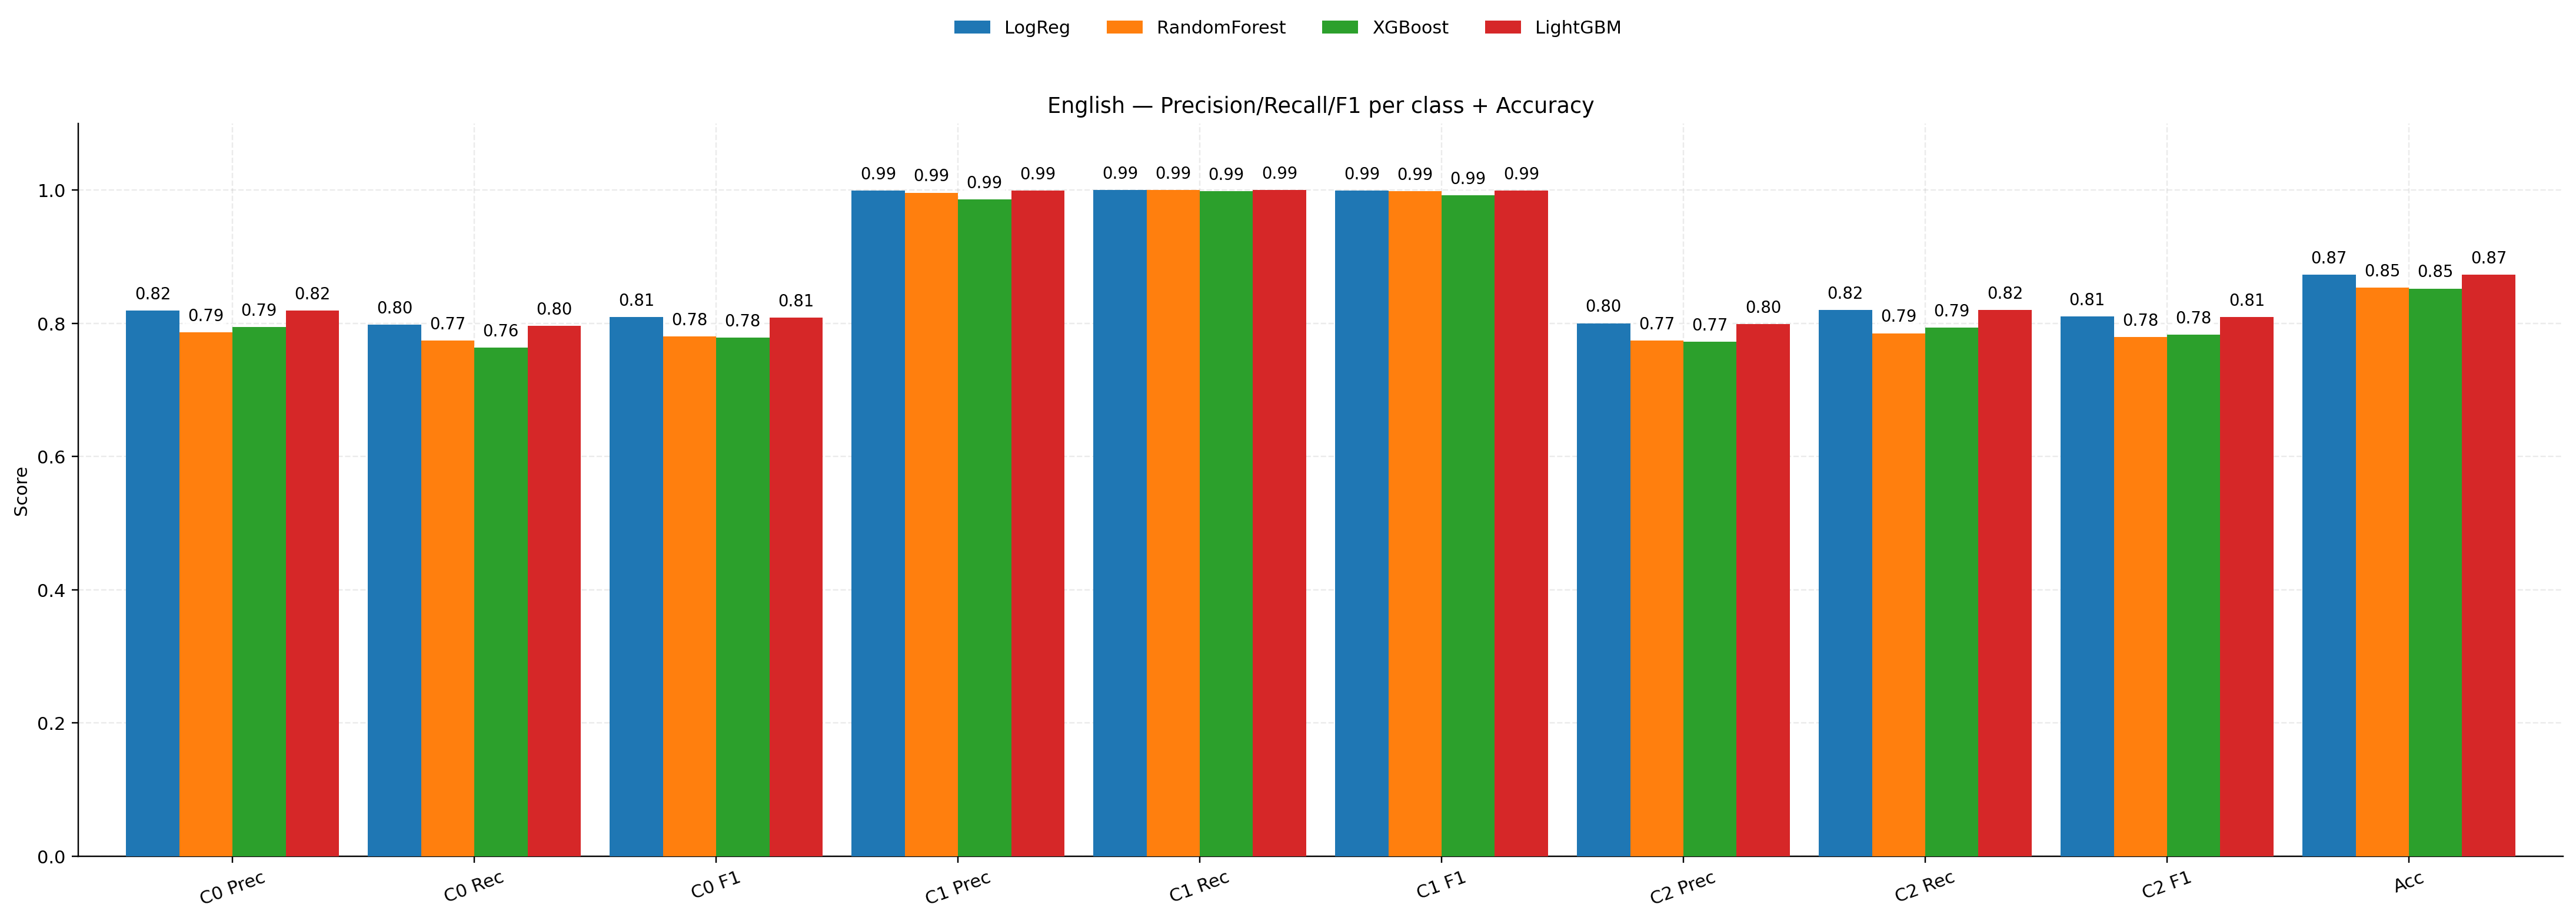

Saved → artifacts_compare/en_combined_classes_hist_auc_ap.png


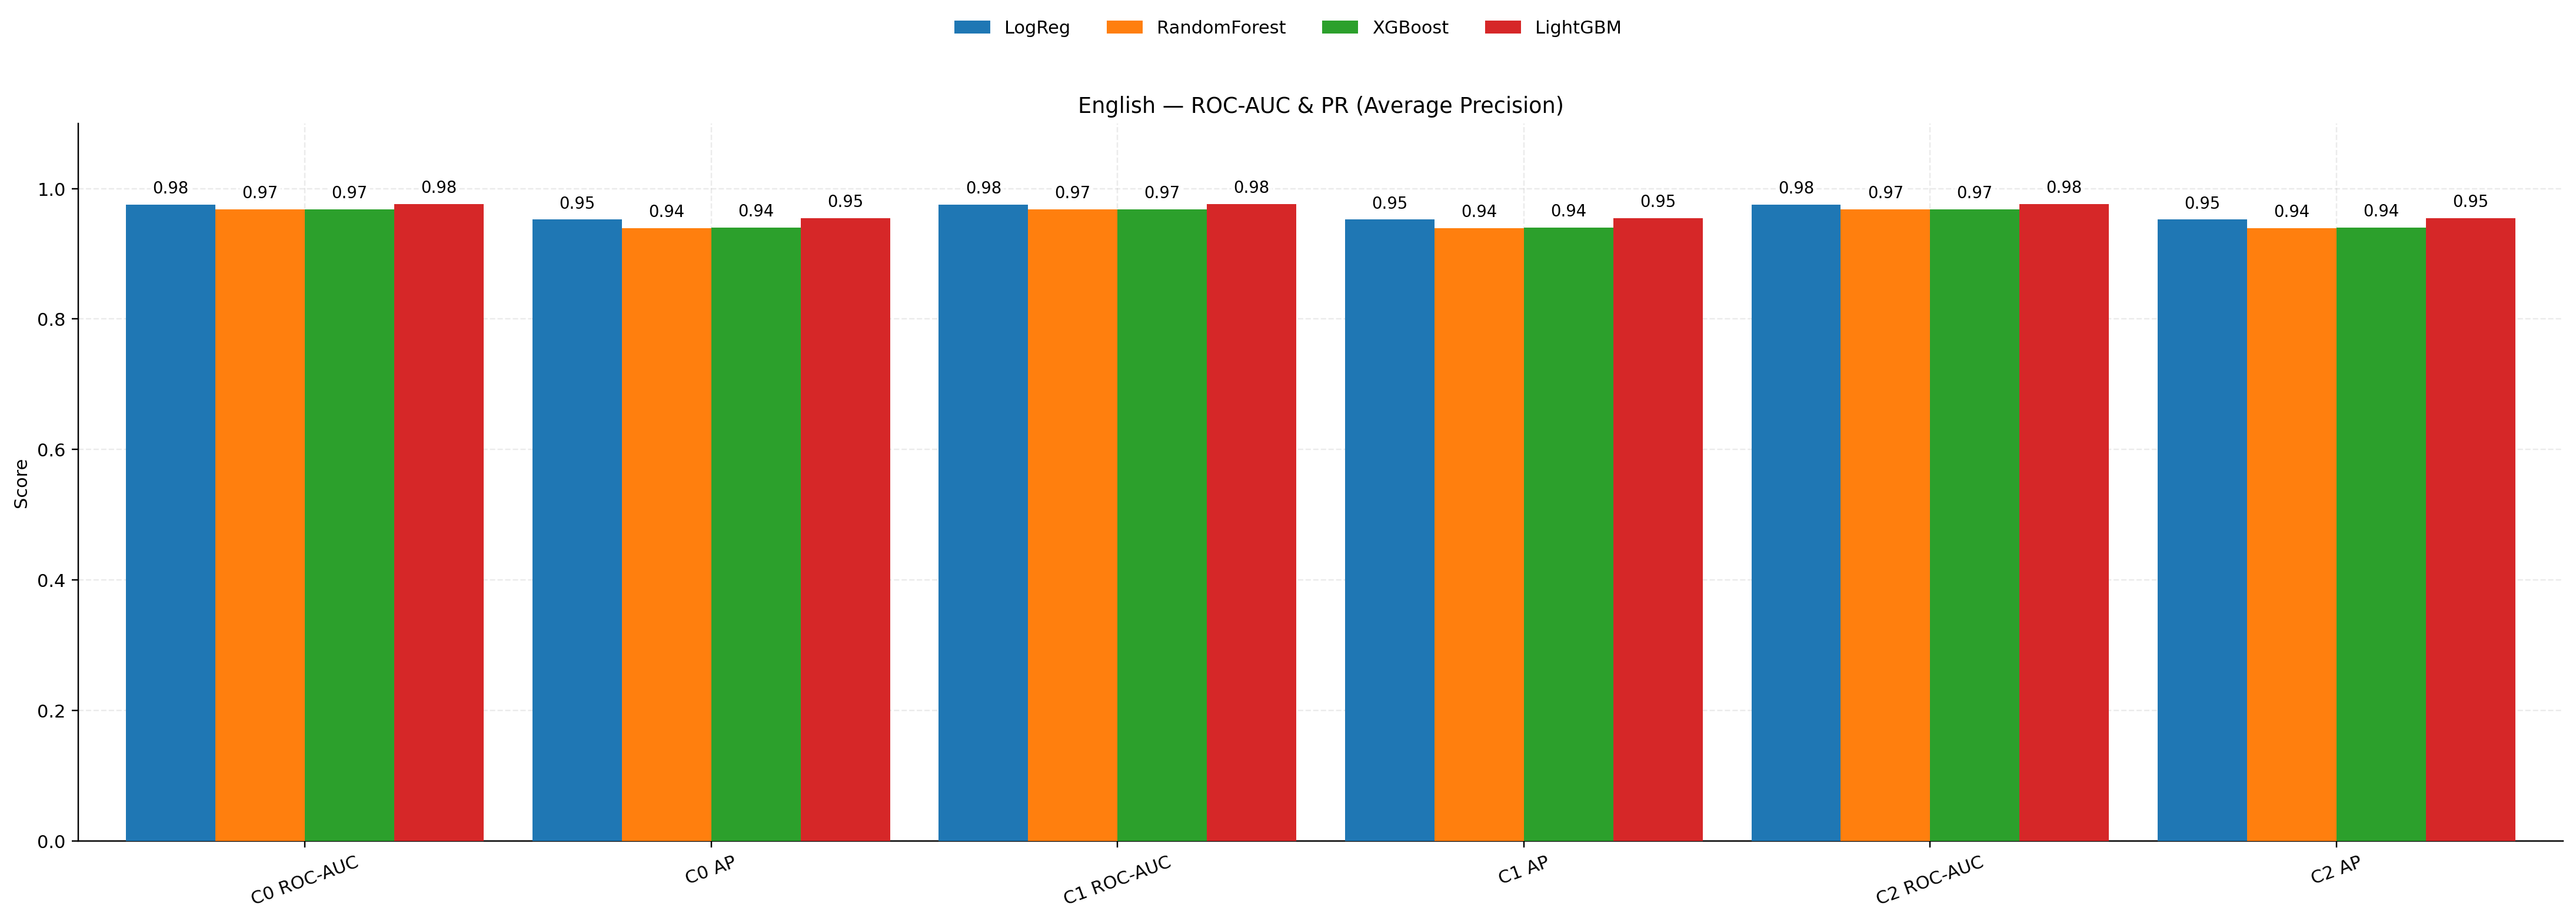

In [3]:
# ============================================
# Non-English — ONE-PLOT (combined classes) HISTOGRAMS
#   A) [C0 P,R,F1 | C1 P,R,F1 | C2 P,R,F1 | ACC]
#   B) [C0 ROC-AUC, AP | C1 ROC-AUC, AP | C2 ROC-AUC, AP]
# ============================================

import re, json
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

# --------- model artifact locations ---------
# name, directory, tag  -> files used:
#   {dir}/{tag}_classification_report_test.txt
#   {dir}/{tag}_summary.json
CFG = [
    ("LogReg",        "artifacts_models",       "en"),
    ("RandomForest",  "artifacts_models_rf",    "en"),
    ("XGBoost",       "artifacts_models_xgb",   "en"),
    ("LightGBM",      "artifacts_models_lgbm",  "en"),
]

OUT_A = "artifacts_compare/en_combined_classes_hist_acc_pr_re_f1.png"
OUT_B = "artifacts_compare/en_combined_classes_hist_auc_ap.png"

# --------- parsers ---------
LINE_RE = re.compile(r"^class_(\d+)\s+([0-9.]+)\s+([0-9.]+)\s+([0-9.]+)\s+\d+")

def load_per_class_metrics(path: Path):
    out = {0:{},1:{},2:{}}
    with open(path, "r") as f:
        for line in f:
            m = LINE_RE.match(line.strip())
            if m:
                c = int(m.group(1))
                p, r, f1 = map(float, m.groups()[1:4])
                out[c] = {"P": p, "R": r, "F1": f1}
    for c in (0,1,2):
        out.setdefault(c, {"P": np.nan, "R": np.nan, "F1": np.nan})
    return out

def load_summary(path: Path):
    with open(path, "r") as f:
        s = json.load(f)
    return {
        "ACC": float(s.get("test_accuracy", np.nan)),
        "AUC": float(s.get("roc_auc_micro", np.nan)),      # replace with per-class OvR if available
        "AP" : float(s.get("avg_precision_micro", np.nan)),# replace with per-class OvR if available
    }

def gather_all():
    names, per_class, overall = [], {}, {}
    for name, d, tag in CFG:
        rep  = Path(d) / f"{tag}_classification_report_test.txt"
        summ = Path(d) / f"{tag}_summary.json"
        if not rep.exists() or not summ.exists():
            print(f"[skip] {name}: missing {rep.name} or {summ.name}")
            continue
        names.append(name)
        per_class[name] = load_per_class_metrics(rep)
        overall[name]   = load_summary(summ)
    return names, per_class, overall

# --------- tidy labels (no overlap) ---------
def _draw_labels(ax, bars, ymax, inside=False):
    for b in bars:
        v = b.get_height()
        txt = "0.99" if v >= 0.995 else f"{v:.2f}"
        if inside:
            y = max(v - 0.03, 0.02); va = "top"
        else:
            y = min(v + 0.012, ymax - 0.015); va = "bottom"
        ax.text(
            b.get_x() + b.get_width()/2, y, txt,
            ha="center", va=va, fontsize=9,
            bbox=dict(boxstyle="round,pad=0.15", fc="white", ec="none", alpha=0.85),
            zorder=5
        )

# ---------- PLOT A: Class0/1/2 (P,R,F1) + Accuracy ----------
def plot_combined_acc_pr_re_f1(names, per_class, overall, save_path=OUT_A, labels_inside=False):
    plt.rcParams.update({
        "figure.dpi": 220,
        "axes.spines.top": False, "axes.spines.right": False,
        "axes.grid": True, "grid.alpha": 0.25, "grid.linestyle": "--",
    })
    labels = ["C0 Prec","C0 Rec","C0 F1","C1 Prec","C1 Rec","C1 F1","C2 Prec","C2 Rec","C2 F1","Acc"]
    X = np.arange(len(labels))
    n_models = len(names)

    group_w = 0.88
    bar_w   = min(group_w / n_models, 0.24)
    offsets = (np.arange(n_models) - (n_models-1)/2) * bar_w

    fig = plt.figure(figsize=(20,7))
    ax  = plt.gca()
    ymax = 1.10
    ax.set_ylim(0, ymax)
    ax.margins(x=0.02, y=0.04)

    for i, m in enumerate(names):
        vals = [
            per_class[m][0]["P"], per_class[m][0]["R"], per_class[m][0]["F1"],
            per_class[m][1]["P"], per_class[m][1]["R"], per_class[m][1]["F1"],
            per_class[m][2]["P"], per_class[m][2]["R"], per_class[m][2]["F1"],
            overall[m]["ACC"],
        ]
        bars = ax.bar(X + offsets[i], vals, width=bar_w, zorder=3, label=m)
        _draw_labels(ax, bars, ymax, inside=labels_inside)

    ax.set_xticks(X, labels, rotation=20)
    ax.set_ylabel("Score")
    ax.set_title("English — Precision/Recall/F1 per class + Accuracy")

    # legend outside (top center)
    handles, texts = ax.get_legend_handles_labels()
    fig.legend(handles, texts, ncol=min(n_models,4),
               loc="upper center", bbox_to_anchor=(0.5, 1.02), frameon=False)

    fig.tight_layout(rect=[0,0,1,0.94])
    if save_path:
        Path(save_path).parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, bbox_inches="tight")
        print(f"Saved → {save_path}")
    plt.show()

# ---------- PLOT B: Class0/1/2 (ROC-AUC & AP) ----------
def plot_combined_auc_ap(names, per_class, overall, save_path=OUT_B, labels_inside=False):
    plt.rcParams.update({
        "figure.dpi": 220,
        "axes.spines.top": False, "axes.spines.right": False,
        "axes.grid": True, "grid.alpha": 0.25, "grid.linestyle": "--",
    })
    labels = ["C0 ROC-AUC","C0 AP","C1 ROC-AUC","C1 AP","C2 ROC-AUC","C2 AP"]
    X = np.arange(len(labels))
    n_models = len(names)

    group_w = 0.88
    bar_w   = min(group_w / n_models, 0.24)
    offsets = (np.arange(n_models) - (n_models-1)/2) * bar_w

    fig = plt.figure(figsize=(20,7))
    ax  = plt.gca()
    ymax = 1.10
    ax.set_ylim(0, ymax)
    ax.margins(x=0.02, y=0.04)

    for i, m in enumerate(names):
        # If you have OvR AUC/AP per class, replace with those instead of duplicating
        auc = overall[m]["AUC"]; ap = overall[m]["AP"]
        vals = [auc, ap, auc, ap, auc, ap]
        bars = ax.bar(X + offsets[i], vals, width=bar_w, zorder=3, label=m)
        _draw_labels(ax, bars, ymax, inside=labels_inside)

    ax.set_xticks(X, labels, rotation=20)
    ax.set_ylabel("Score")
    ax.set_title("English — ROC-AUC & PR (Average Precision)")

    handles, texts = ax.get_legend_handles_labels()
    fig.legend(handles, texts, ncol=min(n_models,4),
               loc="upper center", bbox_to_anchor=(0.5, 1.02), frameon=False)

    fig.tight_layout(rect=[0,0,1,0.94])
    if save_path:
        Path(save_path).parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, bbox_inches="tight")
        print(f"Saved → {save_path}")
    plt.show()

# --------- run ---------
if __name__ == "__main__":
    names, per_class, overall = gather_all()
    if not names:
        print("No artifacts found — nothing to plot.")
    else:
        plot_combined_acc_pr_re_f1(names, per_class, overall, OUT_A, labels_inside=False)
        plot_combined_auc_ap(names, per_class, overall, OUT_B, labels_inside=False)


Saved → artifacts_compare/non_en_combined_classes_hist_acc_pr_re_f1.png


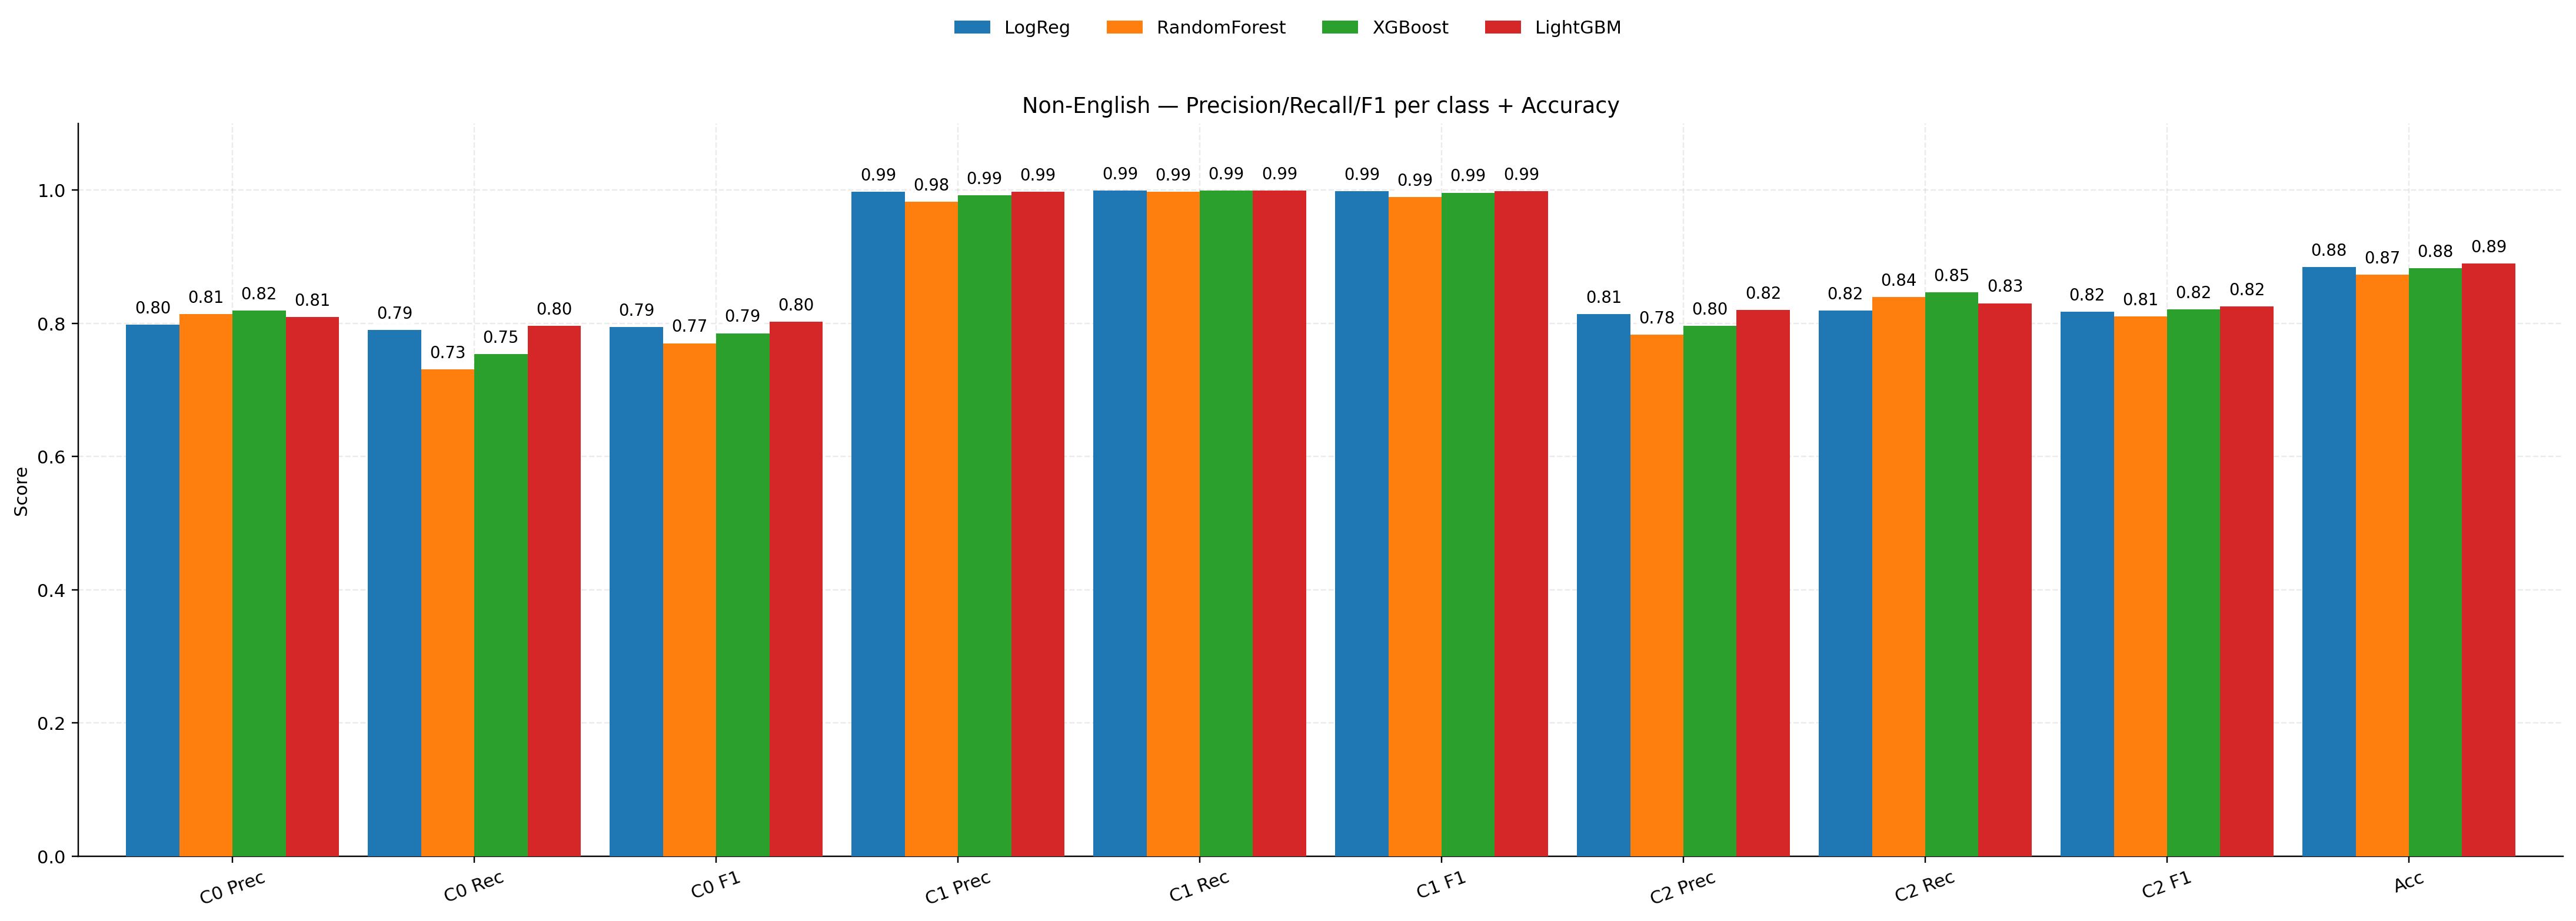

Saved → artifacts_compare/non_en_combined_classes_hist_auc_ap.png


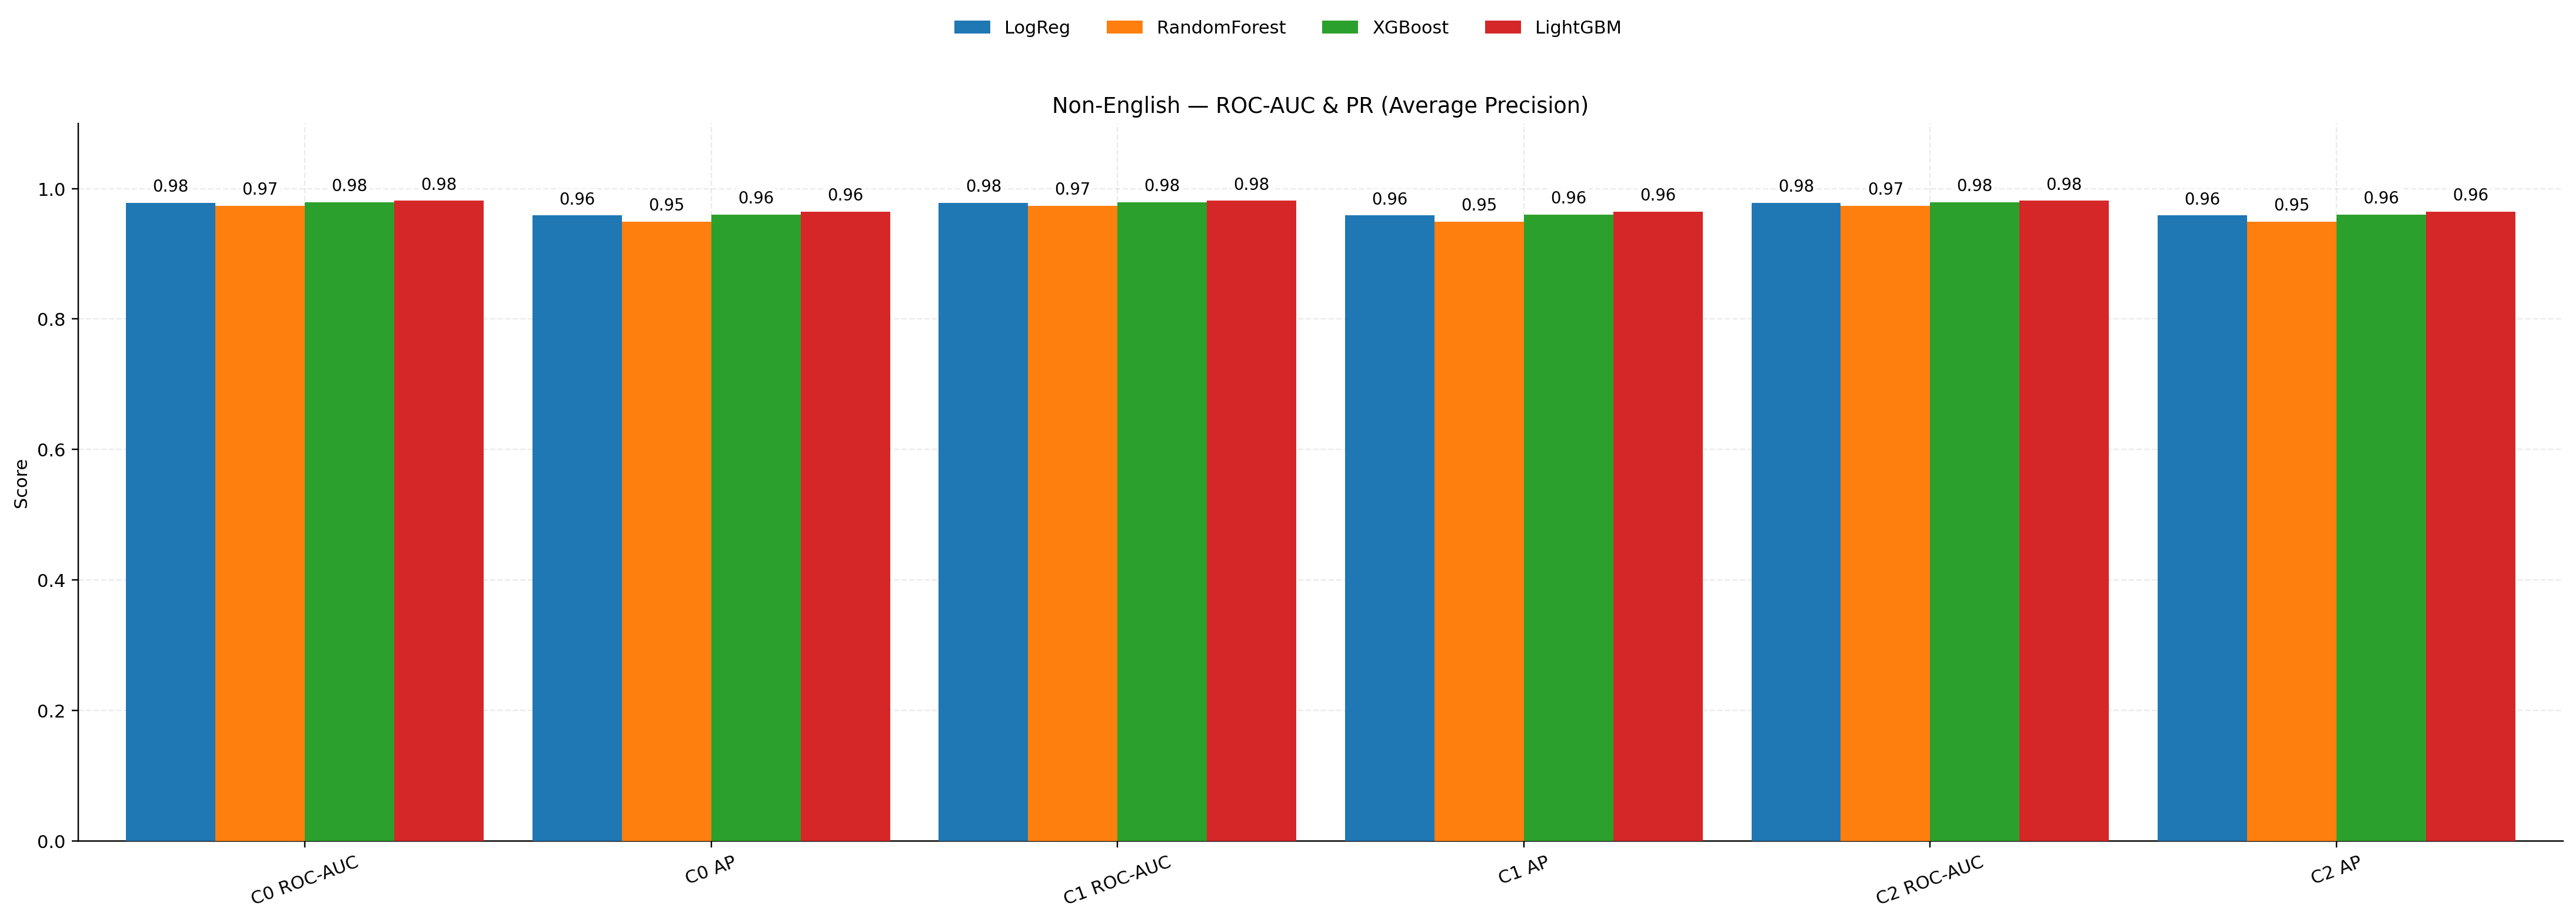

In [4]:
# ============================================
# Non-English — ONE-PLOT (combined classes) HISTOGRAMS
#   A) [C0 P,R,F1 | C1 P,R,F1 | C2 P,R,F1 | ACC]
#   B) [C0 ROC-AUC, AP | C1 ROC-AUC, AP | C2 ROC-AUC, AP]
# ============================================

import re, json
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

# --------- model artifact locations ---------
# name, directory, tag  -> files used:
#   {dir}/{tag}_classification_report_test.txt
#   {dir}/{tag}_summary.json
CFG = [
    ("LogReg",        "artifacts_models",       "non_en"),
    ("RandomForest",  "artifacts_models_rf",    "non_en"),
    ("XGBoost",       "artifacts_models_xgb",   "non_en"),
    ("LightGBM",      "artifacts_models_lgbm",  "non_en"),
]

OUT_A = "artifacts_compare/non_en_combined_classes_hist_acc_pr_re_f1.png"
OUT_B = "artifacts_compare/non_en_combined_classes_hist_auc_ap.png"

# --------- parsers ---------

LINE_RE = re.compile(r"^class_(\d+)\s+([0-9.]+)\s+([0-9.]+)\s+([0-9.]+)\s+\d+")

def load_per_class_metrics(path: Path):
    out = {0:{},1:{},2:{}}
    with open(path, "r") as f:
        for line in f:
            m = LINE_RE.match(line.strip())
            if m:
                c = int(m.group(1))
                p, r, f1 = map(float, m.groups()[1:4])
                out[c] = {"P": p, "R": r, "F1": f1}
    for c in (0,1,2):
        out.setdefault(c, {"P": np.nan, "R": np.nan, "F1": np.nan})
    return out

def load_summary(path: Path):
    with open(path, "r") as f:
        s = json.load(f)
    return {
        "ACC": float(s.get("test_accuracy", np.nan)),
        "AUC": float(s.get("roc_auc_micro", np.nan)),      # replace with per-class OvR if available
        "AP" : float(s.get("avg_precision_micro", np.nan)),# replace with per-class OvR if available
    }

def gather_all():
    names, per_class, overall = [], {}, {}
    for name, d, tag in CFG:
        rep  = Path(d) / f"{tag}_classification_report_test.txt"
        summ = Path(d) / f"{tag}_summary.json"
        if not rep.exists() or not summ.exists():
            print(f"[skip] {name}: missing {rep.name} or {summ.name}")
            continue
        names.append(name)
        per_class[name] = load_per_class_metrics(rep)
        overall[name]   = load_summary(summ)
    return names, per_class, overall

# --------- tidy labels (no overlap) ---------
def _draw_labels(ax, bars, ymax, inside=False):
    for b in bars:
        v = b.get_height()
        txt = "0.99" if v >= 0.995 else f"{v:.2f}"
        if inside:
            y = max(v - 0.03, 0.02); va = "top"
        else:
            y = min(v + 0.012, ymax - 0.015); va = "bottom"
        ax.text(
            b.get_x() + b.get_width()/2, y, txt,
            ha="center", va=va, fontsize=9,
            bbox=dict(boxstyle="round,pad=0.15", fc="white", ec="none", alpha=0.85),
            zorder=5
        )

# ---------- PLOT A: Class0/1/2 (P,R,F1) + Accuracy ----------
def plot_combined_acc_pr_re_f1(names, per_class, overall, save_path=OUT_A, labels_inside=False):
    plt.rcParams.update({
        "figure.dpi": 220,
        "axes.spines.top": False, "axes.spines.right": False,
        "axes.grid": True, "grid.alpha": 0.25, "grid.linestyle": "--",
    })
    labels = ["C0 Prec","C0 Rec","C0 F1","C1 Prec","C1 Rec","C1 F1","C2 Prec","C2 Rec","C2 F1","Acc"]
    X = np.arange(len(labels))
    n_models = len(names)

    group_w = 0.88
    bar_w   = min(group_w / n_models, 0.24)
    offsets = (np.arange(n_models) - (n_models-1)/2) * bar_w

    fig = plt.figure(figsize=(20,7))
    ax  = plt.gca()
    ymax = 1.10
    ax.set_ylim(0, ymax)
    ax.margins(x=0.02, y=0.04)

    for i, m in enumerate(names):
        vals = [
            per_class[m][0]["P"], per_class[m][0]["R"], per_class[m][0]["F1"],
            per_class[m][1]["P"], per_class[m][1]["R"], per_class[m][1]["F1"],
            per_class[m][2]["P"], per_class[m][2]["R"], per_class[m][2]["F1"],
            overall[m]["ACC"],
        ]
        bars = ax.bar(X + offsets[i], vals, width=bar_w, zorder=3, label=m)
        _draw_labels(ax, bars, ymax, inside=labels_inside)

    ax.set_xticks(X, labels, rotation=20)
    ax.set_ylabel("Score")
    ax.set_title("Non-English — Precision/Recall/F1 per class + Accuracy")

    # legend outside (top center)
    handles, texts = ax.get_legend_handles_labels()
    fig.legend(handles, texts, ncol=min(n_models,4),
               loc="upper center", bbox_to_anchor=(0.5, 1.02), frameon=False)

    fig.tight_layout(rect=[0,0,1,0.94])
    if save_path:
        Path(save_path).parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, bbox_inches="tight")
        print(f"Saved → {save_path}")
    plt.show()

# ---------- PLOT B: Class0/1/2 (ROC-AUC & AP) ----------
def plot_combined_auc_ap(names, per_class, overall, save_path=OUT_B, labels_inside=False):
    plt.rcParams.update({
        "figure.dpi": 220,
        "axes.spines.top": False, "axes.spines.right": False,
        "axes.grid": True, "grid.alpha": 0.25, "grid.linestyle": "--",
    })
    labels = ["C0 ROC-AUC","C0 AP","C1 ROC-AUC","C1 AP","C2 ROC-AUC","C2 AP"]
    X = np.arange(len(labels))
    n_models = len(names)

    group_w = 0.88
    bar_w   = min(group_w / n_models, 0.24)
    offsets = (np.arange(n_models) - (n_models-1)/2) * bar_w

    fig = plt.figure(figsize=(20,7))
    ax  = plt.gca()
    ymax = 1.10
    ax.set_ylim(0, ymax)
    ax.margins(x=0.02, y=0.04)

    for i, m in enumerate(names):
        # If you have OvR AUC/AP per class, replace with those instead of duplicating
        auc = overall[m]["AUC"]; ap = overall[m]["AP"]
        vals = [auc, ap, auc, ap, auc, ap]
        bars = ax.bar(X + offsets[i], vals, width=bar_w, zorder=3, label=m)
        _draw_labels(ax, bars, ymax, inside=labels_inside)

    ax.set_xticks(X, labels, rotation=20)
    ax.set_ylabel("Score")
    ax.set_title("Non-English — ROC-AUC & PR (Average Precision)")

    handles, texts = ax.get_legend_handles_labels()
    fig.legend(handles, texts, ncol=min(n_models,4),
               loc="upper center", bbox_to_anchor=(0.5, 1.02), frameon=False)

    fig.tight_layout(rect=[0,0,1,0.94])
    if save_path:
        Path(save_path).parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, bbox_inches="tight")
        print(f"Saved → {save_path}")
    plt.show()

# --------- run ---------
if __name__ == "__main__":
    names, per_class, overall = gather_all()
    if not names:
        print("No artifacts found — nothing to plot.")
    else:
        plot_combined_acc_pr_re_f1(names, per_class, overall, OUT_A, labels_inside=False)
        plot_combined_auc_ap(names, per_class, overall, OUT_B, labels_inside=False)


## Hybrid Machine Learning Models + Transformers

### English Dataset

In [2]:
# ============================================
# Hierarchical Sentiment (EN: LogReg → BERTweet, non-EN: LogReg → XLM-R)
# Updated with:
#  (1) Tokenization keeps labels (and safely drops original columns)
#  (2) Hierarchical LR stage now gets full DF (text + numeric), not just text
# ============================================

import os, json, math, random
from pathlib import Path
import numpy as np
import pandas as pd

# sklearn / classical
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import MaxAbsScaler, label_binarize
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, classification_report,
    roc_auc_score, precision_recall_fscore_support
)
import joblib
import scipy.sparse as sp
from sklearn.preprocessing import FunctionTransformer

# HF Transformers
import torch
from datasets import Dataset, DatasetDict
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    DataCollatorWithPadding, Trainer, TrainingArguments
)

# ------------- paths -------------
EN_PATH       = "fe/en_base.parquet"
NON_EN_PATH   = "fe/non_en_base.parquet"
LR_DIR        = Path("artifacts_lr");               LR_DIR.mkdir(exist_ok=True, parents=True)
TRF_EN_DIR    = Path("artifacts_trf/en_bertweet");  TRF_EN_DIR.mkdir(exist_ok=True, parents=True)
TRF_NONEN_DIR = Path("artifacts_trf/non_en_xlmr");  TRF_NONEN_DIR.mkdir(exist_ok=True, parents=True)
HIER_DIR      = Path("artifacts_hier");             HIER_DIR.mkdir(exist_ok=True, parents=True)

# ------------- shared config -------------
SEED       = 42
rng        = np.random.default_rng(SEED)
torch.manual_seed(SEED)
random.seed(SEED)

TEXT_COL   = "clean_text"
LABEL_COL  = "sentiment"

# engineered numeric features
NUMERIC_COLS = [
    "vader_score","vader_bucket","hour","day_of_week","is_weekend",
    "text_length","word_count","char_density",
    "has_mentions","has_hashtags","has_links","is_question",
    "sentiment_keyword_count","negation_count","capital_word_count","emoji_count",
    "positive_lexicon_count","negative_lexicon_count",
    "punctuation_count",
    "extended_positive_lexicon_count","extended_negative_lexicon_count",
    "lang_en","lang_arabic","lang_indic","lang_cyril","lang_cjk","lang_latin_other",
    "emoji_polarity",
]
EN_NUMERIC     = NUMERIC_COLS[:]
NON_EN_NUMERIC = [c for c in NUMERIC_COLS if c not in ("vader_score","vader_bucket")]

def load_df(path):
    df = pd.read_parquet(path)
    keep = [c for c in df.columns if c in NUMERIC_COLS]
    df = df[[TEXT_COL, LABEL_COL] + keep].dropna(subset=[TEXT_COL, LABEL_COL]).copy()
    df[LABEL_COL] = df[LABEL_COL].astype(int)
    return df

# =========================
# STAGE 1: Logistic Regression
# =========================
def _to_csr(X):  # keep ColumnTransformer fully sparse
    return sp.csr_matrix(X)

def build_lr_pipeline(mode="en"):
    if mode == "en":
        tfidf = TfidfVectorizer(analyzer="word", ngram_range=(1,2),
                                min_df=2, max_df=0.9, lowercase=False,
                                sublinear_tf=True, max_features=200_000)
        num_cols = EN_NUMERIC
    else:
        tfidf = TfidfVectorizer(analyzer="char_wb", ngram_range=(3,5),
                                min_df=2, max_df=0.95, lowercase=False,
                                sublinear_tf=True, max_features=200_000)
        num_cols = NON_EN_NUMERIC

    pre = ColumnTransformer([
        ("tfidf", tfidf, TEXT_COL),
        ("num", Pipeline([
            ("scale", MaxAbsScaler()),
            ("to_sparse", FunctionTransformer(_to_csr, accept_sparse=True,
                                             check_inverse=False, validate=False))
        ]), num_cols),
    ], sparse_threshold=1.0)

    clf = LogisticRegression(
        solver="saga", max_iter=2000,
        class_weight="balanced", multi_class="auto",
        random_state=SEED
    )
    return Pipeline([("prep", pre), ("clf", clf)]), num_cols

def train_logreg(df, mode, tag):
    pipe, used = build_lr_pipeline(mode)
    Xtr, Xte, ytr, yte = train_test_split(
        df[[TEXT_COL] + used], df[LABEL_COL],
        test_size=0.2, stratify=df[LABEL_COL], random_state=SEED
    )
    pipe.fit(Xtr, ytr)
    yhat = pipe.predict(Xte)
    proba = pipe.predict_proba(Xte)
    acc  = accuracy_score(yte, yhat)
    aucm = roc_auc_score(yte, proba, multi_class="ovr", average="macro")
    print(f"[LogReg-{tag}] acc={acc:.4f}  macroAUC={aucm:.4f}")
    print(classification_report(yte, yhat, digits=3))
    joblib.dump(pipe, LR_DIR / f"logreg_{tag}.joblib")

    with open(LR_DIR / f"logreg_{tag}_info.json", "w") as f:
        json.dump({
            "classes_order": [int(c) for c in pipe.named_steps["clf"].classes_],
            "acc_test": float(acc),
            "macro_auc_test": float(aucm),
            "mode": mode
        }, f, indent=2)
    return (Xte, yte, proba, yhat)

# =========================
# STAGE 2: Transformers fine-tune
# =========================
def df_to_hf(df, test_size=0.2):
    tr, te = train_test_split(df, test_size=test_size, stratify=df[LABEL_COL], random_state=SEED)
    return DatasetDict({
        "train": Dataset.from_pandas(tr.reset_index(drop=True)),
        "test":  Dataset.from_pandas(te.reset_index(drop=True)),
    })

def build_tokenizer_and_model(mode):
    if mode == "en":
        pretrained = "vinai/bertweet-base"  # BERTweet
    else:


        pretrained = "cardiffnlp/twitter-xlm-roberta-base-sentiment"  # XLM-R (CardiffNLP)
    tok = AutoTokenizer.from_pretrained(pretrained, use_fast=True)
    model = AutoModelForSequenceClassification.from_pretrained(
        pretrained, num_labels=3, ignore_mismatched_sizes=True
    )
    return tok, model, pretrained

# ---- FIX (1): keep labels when tokenizing; drop original columns safely
def preprocess_examples(examples, tokenizer):
    enc = tokenizer(examples[TEXT_COL], truncation=True)
    enc["labels"] = examples[LABEL_COL]
    return enc

def compute_metrics_builder():
    def _cmp(eval_pred):
        logits, labels = eval_pred
        preds = np.argmax(logits, axis=-1)
        acc = accuracy_score(labels, preds)
        p, r, f1, _ = precision_recall_fscore_support(labels, preds, average="macro", zero_division=0)
        return {"accuracy": acc, "precision_macro": p, "recall_macro": r, "f1_macro": f1}
    return _cmp

def train_transformer(df, mode, out_dir, epochs=2, batch=16, lr=2e-5, weight_decay=0.01):
    out_dir = Path(out_dir); out_dir.mkdir(parents=True, exist_ok=True)
    tok, model, pretrained = build_tokenizer_and_model(mode)
    dsd = df_to_hf(df)

    tokenized = dsd.map(
        lambda x: preprocess_examples(x, tok),
        batched=True,
        remove_columns=dsd["train"].column_names  # drop all original cols; we re-add labels above
    )
    collator = DataCollatorWithPadding(tokenizer=tok)

    args = TrainingArguments(
        output_dir=str(out_dir),
        eval_strategy="epoch",
        save_strategy="epoch",
        logging_strategy="steps",
        logging_steps=100,
        learning_rate=lr,
        per_device_train_batch_size=batch,
        per_device_eval_batch_size=batch,
        num_train_epochs=epochs,
        weight_decay=weight_decay,
        load_best_model_at_end=True,
        metric_for_best_model="f1_macro",
        greater_is_better=True,
        seed=SEED,
        report_to=[],
    )

    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=tokenized["train"],
        eval_dataset=tokenized["test"],
        tokenizer=tok,
        data_collator=collator,
        compute_metrics=compute_metrics_builder()
    )
    trainer.train()
    eval_res = trainer.evaluate()
    print(f"[{pretrained}] eval:", eval_res)

    trainer.save_model()
    tok.save_pretrained(out_dir)
    with open(out_dir / "eval_results.json", "w") as f:
        json.dump(eval_res, f, indent=2)
    return out_dir

# =========================
# HIERARCHICAL INFERENCE
# =========================
@torch.inference_mode()
def hierarchical_predict(df, lang="en",
                         lr_path=None,
                         trf_dir=None,
                         accept_conf=0.80,
                         neutral_id=1,
                         device=None):
    """
    Step 1: LogReg on FULL DF (text + numeric). If max prob >= accept_conf, keep LR.
    Else:   Step 2 (transformer) on TEXT only.
    Returns dict with predictions, which_stage, and LR probabilities.
    """
    device = device or ("cuda" if torch.cuda.is_available() else
                        ("mps" if torch.backends.mps.is_available() else "cpu"))

    # ---- FIX (2): pass FULL DF to LR
    lr = joblib.load(lr_path)
    lr_proba = lr.predict_proba(df)     # expects TEXT_COL + numeric present
    lr_pred  = lr_proba.argmax(axis=1)
    maxp     = lr_proba.max(axis=1)
    which    = np.array(["LR"] * len(df))

    # route to transformers if low-confidence
    go_trf = (maxp < accept_conf)
    idx_trf = np.where(go_trf)[0]

    trf_pred = np.full(len(df), -1, dtype=int)
    if len(idx_trf) > 0:
        tok = AutoTokenizer.from_pretrained(trf_dir, use_fast=True)
        mdl = AutoModelForSequenceClassification.from_pretrained(trf_dir).to(device)
        mdl.eval()
        texts = df.iloc[idx_trf][TEXT_COL].tolist()
        bs = 64
        for i in range(0, len(texts), bs):
            enc = tok(texts[i:i+bs], return_tensors="pt", truncation=True, padding=True).to(device)
            logits = mdl(**enc).logits
            trf_pred[idx_trf[i:i+bs]] = logits.argmax(dim=-1).cpu().numpy()
        which[idx_trf] = "TRF"

    final_pred = np.where(go_trf, trf_pred, lr_pred)
    return {"pred": final_pred.astype(int), "stage": which,
            "lr_max_prob": maxp, "lr_pred": lr_pred.astype(int)}

def evaluate_hierarchical(df, lang, lr_path, trf_dir, accept_conf=0.80, neutral_id=1):
    out = hierarchical_predict(df, lang, lr_path, trf_dir, accept_conf, neutral_id)
    y     = df[LABEL_COL].to_numpy()
    yhat  = out["pred"]

    acc  = accuracy_score(y, yhat)
    p, r, f1, _ = precision_recall_fscore_support(y, yhat, average=None, zero_division=0, labels=[0,1,2])
    print(f"[Hier-{lang}] acc={acc:.4f}")
    print(classification_report(y, yhat, digits=3))

    HIER_DIR.mkdir(exist_ok=True, parents=True)
    with open(HIER_DIR / f"hier_{lang}_summary.json", "w") as f:
        json.dump({
            "accept_conf": accept_conf,
            "accuracy": float(acc),
            "per_class": {
                "precision":[float(x) for x in p],
                "recall":[float(x) for x in r],
                "f1":[float(x) for x in f1]
            }
        }, f, indent=2)

# =========================
# RUN: train everything & evaluate
# =========================
if __name__ == "__main__":
    # ---------- English ----------
    en_df = load_df(EN_PATH)
    _, _, _, _ = train_logreg(en_df, mode="en", tag="en")                   # saves artifacts_lr/logreg_en.joblib
    train_transformer(en_df, mode="en", out_dir=TRF_EN_DIR, epochs=2)       # fine-tune BERTweet

    # Evaluate hierarchical on EN test split
    en_tr, en_te = train_test_split(en_df, test_size=0.2, stratify=en_df[LABEL_COL], random_state=SEED)
    evaluate_hierarchical(
        en_te, "en",
        lr_path=LR_DIR / "logreg_en.joblib",
        trf_dir=TRF_EN_DIR,
        accept_conf=0.80,   # tune higher (e.g., 0.85–0.90) to push more hard cases to Stage-2
        neutral_id=1
    )

    # ---------- Non-English ----------
    non_df = load_df(NON_EN_PATH)
    _, _, _, _ = train_logreg(non_df, mode="non_en", tag="non_en")          # logreg for non-EN
    train_transformer(non_df, mode="non_en", out_dir=TRF_NONEN_DIR, epochs=2)  # fine-tune XLM-R

    non_tr, non_te = train_test_split(non_df, test_size=0.2, stratify=non_df[LABEL_COL], random_state=SEED)
    evaluate_hierarchical(
        non_te, "non_en",
        lr_path=LR_DIR / "logreg_non_en.joblib",
        trf_dir=TRF_NONEN_DIR,
        accept_conf=0.80,
        neutral_id=1
    )


/Users/yasmeenazmatali/envs/hier-sent/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


[LogReg-en] acc=0.8731  macroAUC=0.9632
              precision    recall  f1-score   support

           0      0.819     0.798     0.809    147323
           1      0.999     1.000     0.999    147859
           2      0.800     0.820     0.810    144678

    accuracy                          0.873    439860
   macro avg      0.873     0.873     0.873    439860
weighted avg      0.873     0.873     0.873    439860



emoji is not installed, thus not converting emoticons or emojis into text. Install emoji: pip3 install emoji==0.6.0
Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at vinai/bertweet-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.
Map: 100%|████████████████████| 439860/439860 [00:26<00:00, 16786.67 examples/s]
/var/folders/s1/fblnjj651912vs_d54bjg80m0000gn/T/ipykernel_25310/2649168972.py:199: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(
/Users/yasmeenazmatali/envs/hier-sent/lib/python3.10/si

Epoch,Training Loss,Validation Loss,Accuracy,Precision Macro,Recall Macro,F1 Macro
1,0.226500,0.215906,0.912070,0.912376,0.911540,0.911599
2,0.213600,0.234185,0.914482,0.914540,0.913997,0.914053


/Users/yasmeenazmatali/envs/hier-sent/lib/python3.10/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/yasmeenazmatali/envs/hier-sent/lib/python3.10/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


...

emoji is not installed, thus not converting emoticons or emojis into text. Install emoji: pip3 install emoji==0.6.0
Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.


[Hier-en] acc=0.9101
              precision    recall  f1-score   support

           0      0.857     0.879     0.868    147323
           1      1.000     1.000     1.000    147859
           2      0.873     0.850     0.862    144678

    accuracy                          0.910    439860
   macro avg      0.910     0.910     0.910    439860
weighted avg      0.910     0.910     0.910    439860



/Users/yasmeenazmatali/envs/hier-sent/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


[LogReg-non_en] acc=0.8840  macroAUC=0.9668
              precision    recall  f1-score   support

           0      0.798     0.790     0.794      6875
           1      0.997     0.999     0.998      9919
           2      0.814     0.819     0.817      7645

    accuracy                          0.884     24439
   macro avg      0.870     0.869     0.870     24439
weighted avg      0.884     0.884     0.884     24439



ImportError: 
 requires the protobuf library but it was not found in your environment. Check out the instructions on the
installation page of its repo: https://github.com/protocolbuffers/protobuf/tree/master/python#installation and follow the ones
that match your environment. Please note that you may need to restart your runtime after installation.


In [1]:
# ============================================
# ENGLISH-ONLY Hierarchical Sentiment
# Stage-1: RandomForest (TF-IDF + numeric)
# Stage-2: BERTweet fine-tune
# ============================================

import os, json, random
from pathlib import Path
import numpy as np
import pandas as pd
import joblib
import torch
import scipy.sparse as sp

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import MaxAbsScaler, FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, classification_report,
    precision_recall_fscore_support, roc_auc_score
)

from datasets import Dataset, DatasetDict
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    DataCollatorWithPadding, Trainer, TrainingArguments
)

# ---------- paths ----------
EN_PATH     = "fe/en_base.parquet"
ART_LR_DIR  = Path("artifacts_rf_en");             ART_LR_DIR.mkdir(parents=True, exist_ok=True)  # RF artifacts
TRF_EN_DIR  = Path("artifacts_trf/en_bertweet");   TRF_EN_DIR.mkdir(parents=True, exist_ok=True)
HIER_DIR    = Path("artifacts_hier");              HIER_DIR.mkdir(parents=True, exist_ok=True)

# ---------- config ----------
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
TEXT_COL, LABEL_COL = "clean_text", "sentiment"

NUMERIC_COLS = [
    "vader_score","vader_bucket","hour","day_of_week","is_weekend",
    "text_length","word_count","char_density",
    "has_mentions","has_hashtags","has_links","is_question",
    "sentiment_keyword_count","negation_count","capital_word_count","emoji_count",
    "positive_lexicon_count","negative_lexicon_count",
    "punctuation_count",
    "extended_positive_lexicon_count","extended_negative_lexicon_count",
    "lang_en","lang_arabic","lang_indic","lang_cyril","lang_cjk","lang_latin_other",
    "emoji_polarity",
]
EN_NUMERIC = NUMERIC_COLS[:]  # English: keep all (incl. VADER)

def load_df(path):
    df = pd.read_parquet(path)
    keep = [c for c in df.columns if c in NUMERIC_COLS]
    df = df[[TEXT_COL, LABEL_COL] + keep].dropna(subset=[TEXT_COL, LABEL_COL]).copy()
    df[LABEL_COL] = df[LABEL_COL].astype(int)
    return df

# =========================
# STAGE 1: RandomForest (EN)
# =========================
def _to_csr(X): return sp.csr_matrix(X)

def make_sparse_numeric():
    return Pipeline([
        ("scale", MaxAbsScaler()),
        ("to_sparse", FunctionTransformer(_to_csr, accept_sparse=True,
                                         check_inverse=False, validate=False))
    ])

def build_rf_pipeline_en():
    tfidf = TfidfVectorizer(
        analyzer="word", ngram_range=(1,2),
        min_df=2, max_df=0.9, lowercase=False, sublinear_tf=True,
        max_features=200_000
    )
    pre = ColumnTransformer([
        ("tfidf", tfidf, TEXT_COL),
        ("num", make_sparse_numeric(), EN_NUMERIC),
    ], sparse_threshold=1.0)  # force sparse all the way

    clf = RandomForestClassifier(
        n_estimators=300,
        max_depth=None,             # try 20–40 for stronger regularization if needed
        max_features="sqrt",
        class_weight="balanced_subsample",
        n_jobs=-1,
        random_state=SEED
    )
    return Pipeline([("prep", pre), ("clf", clf)])

def train_rf_en(df):
    pipe = build_rf_pipeline_en()
    Xtr, Xte, ytr, yte = train_test_split(
        df[[TEXT_COL] + EN_NUMERIC], df[LABEL_COL],
        test_size=0.2, stratify=df[LABEL_COL], random_state=SEED
    )
    pipe.fit(Xtr, ytr)
    yhat = pipe.predict(Xte)
    proba = pipe.predict_proba(Xte)
    acc  = accuracy_score(yte, yhat)
    aucm = roc_auc_score(yte, proba, multi_class="ovr", average="macro")
    print(f"[RF-en] acc={acc:.4f}  macroAUC={aucm:.4f}")
    print(classification_report(yte, yhat, digits=3))
    model_path = ART_LR_DIR / "rf_en.joblib"
    joblib.dump(pipe, model_path)
    with open(ART_LR_DIR / "rf_en_summary.json", "w") as f:
        json.dump({"acc_test": float(acc), "macro_auc_test": float(aucm)}, f, indent=2)
    return model_path

# =========================
# STAGE 2: BERTweet fine-tune (EN)
# =========================
def df_to_hf(df, test_size=0.2):
    tr, te = train_test_split(df, test_size=test_size, stratify=df[LABEL_COL], random_state=SEED)
    return DatasetDict({
        "train": Dataset.from_pandas(tr.reset_index(drop=True)),
        "test":  Dataset.from_pandas(te.reset_index(drop=True)),
    })

def preprocess_examples(examples, tokenizer, max_len=128):
    enc = tokenizer(examples[TEXT_COL], truncation=True, max_length=max_len)
    enc["labels"] = examples[LABEL_COL]
    return enc

def train_bertweet_en(df, out_dir, epochs=2, batch=16, lr=2e-5, weight_decay=0.01, max_len=128):
    out_dir = Path(out_dir); out_dir.mkdir(parents=True, exist_ok=True)
    pretrained = "vinai/bertweet-base"
    tok = AutoTokenizer.from_pretrained(pretrained, use_fast=True)
    model = AutoModelForSequenceClassification.from_pretrained(
        pretrained, num_labels=3, ignore_mismatched_sizes=True
    )

    dsd = df_to_hf(df)
    tokenized = dsd.map(
        lambda ex: preprocess_examples(ex, tok, max_len),
        batched=True,
        remove_columns=dsd["train"].column_names
    )
    collator = DataCollatorWithPadding(tokenizer=tok)

    # Keep it MPS-friendly-ish; you can increase batch later if memory allows.
    args = TrainingArguments(
        output_dir=str(out_dir),
        eval_strategy="epoch",
        save_strategy="epoch",
        logging_strategy="steps",
        logging_steps=100,
        learning_rate=lr,
        per_device_train_batch_size=batch,
        per_device_eval_batch_size=batch,
        num_train_epochs=epochs,
        weight_decay=weight_decay,
        load_best_model_at_end=True,
        metric_for_best_model="f1_macro",
        greater_is_better=True,
        seed=SEED,
        report_to=[],
        dataloader_num_workers=0,   # safer on macOS
        dataloader_pin_memory=False
    )

    def compute_metrics(eval_pred):
        logits, labels = eval_pred
        preds = np.argmax(logits, axis=-1)
        acc = accuracy_score(labels, preds)
        p, r, f1, _ = precision_recall_fscore_support(labels, preds, average="macro", zero_division=0)
        return {"accuracy": acc, "precision_macro": p, "recall_macro": r, "f1_macro": f1}

    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=tokenized["train"],
        eval_dataset=tokenized["test"],
        tokenizer=tok,
        data_collator=collator,
        compute_metrics=compute_metrics
    )
    trainer.train()
    eval_res = trainer.evaluate()
    print(f"[BERTweet] eval:", eval_res)
    trainer.save_model(); tok.save_pretrained(out_dir)
    with open(out_dir / "eval_results.json", "w") as f:
        json.dump(eval_res, f, indent=2)
    return out_dir

# =========================
# HIERARCHICAL INFERENCE (EN)
# =========================
@torch.inference_mode()
def hierarchical_predict_en(df, rf_path, trf_dir, accept_conf=0.80, max_len=128, device=None):
    """
    Step 1: RF on FULL DF (text + numeric). If max prob >= accept_conf, keep RF.
    Else:   Step 2 (BERTweet) on TEXT only.
    """
    device = device or ("cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu"))

    # Stage-1: RF
    rf = joblib.load(rf_path)
    proba = rf.predict_proba(df)
    pred_rf = proba.argmax(axis=1)
    maxp   = proba.max(axis=1)

    final = pred_rf.copy()
    which = np.array(["RF"] * len(df), dtype=object)

    # Route hard cases to Stage-2
    idx = np.where(maxp < accept_conf)[0]
    if len(idx) > 0:
        tok = AutoTokenizer.from_pretrained(trf_dir, use_fast=True)
        mdl = AutoModelForSequenceClassification.from_pretrained(trf_dir).to(device).eval()
        texts = df.iloc[idx][TEXT_COL].tolist()
        bs = 64
        for i in range(0, len(idx), bs):
            enc = tok(texts[i:i+bs], return_tensors="pt", truncation=True, padding=True, max_length=max_len).to(device)
            logits = mdl(**enc).logits
            final[idx[i:i+bs]] = logits.argmax(-1).cpu().numpy()
            which[idx[i:i+bs]] = "TRF"
    return final, which, maxp, pred_rf

def evaluate_hier_en(df, rf_path, trf_dir, accept_conf=0.80, max_len=128):
    y = df[LABEL_COL].to_numpy()
    yhat, which, _, _ = hierarchical_predict_en(df, rf_path, trf_dir, accept_conf, max_len)
    acc = accuracy_score(y, yhat)
    p, r, f1, _ = precision_recall_fscore_support(y, yhat, labels=[0,1,2], average=None, zero_division=0)
    print(f"[Hier-EN RF→BERTweet] thr={accept_conf:.2f}  acc={acc:.4f}  routed_to_TRF={np.mean(which=='TRF')*100:.1f}%")
    print(classification_report(y, yhat, digits=3))
    with open(HIER_DIR / "hier_en_rf_bertweet_summary.json", "w") as f:
        json.dump({
            "accept_conf": float(accept_conf),
            "accuracy": float(acc),
            "per_class": {
                "precision": [float(x) for x in p],
                "recall":    [float(x) for x in r],
                "f1":        [float(x) for x in f1],
            }
        }, f, indent=2)

# =========================
# RUN (English only)
# =========================
if __name__ == "__main__":
    en_df = load_df(EN_PATH)

    # Stage-1: RandomForest
    rf_path = train_rf_en(en_df)

    # Stage-2: BERTweet (you can lower batch to 8 or set max_len=96 if memory is tight)
    train_bertweet_en(en_df, TRF_EN_DIR, epochs=2, batch=16, lr=2e-5, weight_decay=0.01, max_len=128)

    # Evaluate hierarchical on a fresh split
    _, en_te = train_test_split(en_df, test_size=0.2, stratify=en_df[LABEL_COL], random_state=SEED)
    evaluate_hier_en(en_te, rf_path, TRF_EN_DIR, accept_conf=0.80, max_len=128)


/Users/yasmeenazmatali/envs/hier-sent/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[RF-en] acc=0.8531  macroAUC=0.9536
              precision    recall  f1-score   support

           0      0.786     0.774     0.780    147323
           1      0.996     1.000     0.998    147859
           2      0.774     0.785     0.779    144678

    accuracy                          0.853    439860
   macro avg      0.852     0.853     0.852    439860
weighted avg      0.853     0.853     0.853    439860



emoji is not installed, thus not converting emoticons or emojis into text. Install emoji: pip3 install emoji==0.6.0
Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at vinai/bertweet-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Map: 100%|████████████████████| 439860/439860 [00:26<00:00, 16396.78 examples/s]
/var/folders/s1/fblnjj651912vs_d54bjg80m0000gn/T/ipykernel_33978/2048944579.py:174: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,Accuracy,Precision Macro,Recall Macro,F1 Macro
1,0.237000,0.217906,0.911786,0.911736,0.911300,0.911344
2,0.206500,0.232466,0.914564,0.914657,0.914073,0.914128


[BERTweet] eval: {'eval_loss': 0.2324662059545517, 'eval_accuracy': 0.9145637248215341, 'eval_precision_macro': 0.9146570141458409, 'eval_recall_macro': 0.9140727098426694, 'eval_f1_macro': 0.9141277655433516, 'eval_runtime': 900.7582, 'eval_samples_per_second': 488.322, 'eval_steps_per_second': 30.521, 'epoch': 2.0}


emoji is not installed, thus not converting emoticons or emojis into text. Install emoji: pip3 install emoji==0.6.0


[Hier-EN RF→BERTweet] thr=0.80  acc=0.9130  routed_to_TRF=48.7%
              precision    recall  f1-score   support

           0      0.857     0.888     0.873    147323
           1      1.000     1.000     1.000    147859
           2      0.882     0.849     0.865    144678

    accuracy                          0.913    439860
   macro avg      0.913     0.913     0.913    439860
weighted avg      0.913     0.913     0.913    439860



In [1]:
# ============================================
# ENGLISH-ONLY Hierarchical Sentiment
# Stage-1: XGBoost (TF-IDF + numeric)
# Stage-2: BERTweet fine-tune
# ============================================

import os, json, random
from pathlib import Path
import numpy as np
import pandas as pd
import joblib
import torch
import scipy.sparse as sp

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import MaxAbsScaler, FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, classification_report,
    precision_recall_fscore_support, roc_auc_score
)
from sklearn.utils.class_weight import compute_sample_weight


# ============================================
# ENGLISH-ONLY Hierarchical Sentiment
# Stage-1: XGBoost (TF-IDF + numeric)
# Stage-2: BERTweet fine-tune
# ============================================

import os, json, random
from pathlib import Path
import numpy as np
import pandas as pd
import joblib
import torch
import scipy.sparse as sp

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import MaxAbsScaler, FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, classification_report,
    precision_recall_fscore_support, roc_auc_score
)
from sklearn.utils.class_weight import compute_sample_weight

from datasets import Dataset, DatasetDict
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    DataCollatorWithPadding, Trainer, TrainingArguments
)

import xgboost as xgb

# ---------- paths ----------
EN_PATH     = "fe/en_base.parquet"
ART_XGB_DIR = Path("artifacts_xgb_en");          ART_XGB_DIR.mkdir(parents=True, exist_ok=True)
TRF_EN_DIR  = Path("artifacts_trf/en_bertweet"); TRF_EN_DIR.mkdir(parents=True, exist_ok=True)
HIER_DIR    = Path("artifacts_hier");            HIER_DIR.mkdir(parents=True, exist_ok=True)

# ---------- config ----------
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
TEXT_COL, LABEL_COL = "clean_text", "sentiment"

NUMERIC_COLS = [
    "vader_score","vader_bucket","hour","day_of_week","is_weekend",
    "text_length","word_count","char_density",
    "has_mentions","has_hashtags","has_links","is_question",
    "sentiment_keyword_count","negation_count","capital_word_count","emoji_count",
    "positive_lexicon_count","negative_lexicon_count",
    "punctuation_count",
    "extended_positive_lexicon_count","extended_negative_lexicon_count",
    "lang_en","lang_arabic","lang_indic","lang_cyril","lang_cjk","lang_latin_other",
    "emoji_polarity",
]
EN_NUMERIC = NUMERIC_COLS[:]

def load_df(path):
    df = pd.read_parquet(path)
    keep = [c for c in df.columns if c in NUMERIC_COLS]
    df = df[[TEXT_COL, LABEL_COL] + keep].dropna(subset=[TEXT_COL, LABEL_COL]).copy()
    df[LABEL_COL] = df[LABEL_COL].astype(int)
    return df

# =========================
# STAGE 1: XGBoost (EN)
# =========================
def _to_csr(X): return sp.csr_matrix(X)

def make_sparse_numeric():
    return Pipeline([
        ("scale", MaxAbsScaler()),
        ("to_sparse", FunctionTransformer(_to_csr, accept_sparse=True,
                                         check_inverse=False, validate=False))
    ])

def build_xgb_pipeline_en():
    tfidf = TfidfVectorizer(
        analyzer="word", ngram_range=(1,2),
        min_df=2, max_df=0.9, lowercase=False, sublinear_tf=True,
        max_features=200_000
    )
    pre = ColumnTransformer([
        ("tfidf", tfidf, TEXT_COL),
        ("num", make_sparse_numeric(), EN_NUMERIC),
    ], sparse_threshold=1.0)  # keep it sparse

    clf = xgb.XGBClassifier(
        objective="multi:softprob",
        num_class=3,
        n_estimators=400,
        max_depth=8,
        learning_rate=0.08,
        subsample=0.9,
        colsample_bytree=0.7,
        tree_method="hist",     # fast & CPU-friendly
        eval_metric="mlogloss",
        n_jobs=-1,
        random_state=SEED
    )
    return Pipeline([("prep", pre), ("clf", clf)])

def train_xgb_en(df):
    pipe = build_xgb_pipeline_en()
    Xtr, Xte, ytr, yte = train_test_split(
        df[[TEXT_COL] + EN_NUMERIC], df[LABEL_COL],
        test_size=0.2, stratify=df[LABEL_COL], random_state=SEED
    )
    # class balancing via sample_weight
    sw_tr = compute_sample_weight(class_weight="balanced", y=ytr)
    pipe.fit(Xtr, ytr, clf__sample_weight=sw_tr)

    yhat  = pipe.predict(Xte)
    proba = pipe.predict_proba(Xte)
    acc   = accuracy_score(yte, yhat)
    aucm  = roc_auc_score(yte, proba, multi_class="ovr", average="macro")
    print(f"[XGB-en] acc={acc:.4f}  macroAUC={aucm:.4f}")
    print(classification_report(yte, yhat, digits=3))

    model_path = ART_XGB_DIR / "xgb_en.joblib"
    joblib.dump(pipe, model_path)
    with open(ART_XGB_DIR / "xgb_en_summary.json", "w") as f:
        json.dump({"acc_test": float(acc), "macro_auc_test": float(aucm)}, f, indent=2)
    return model_path

# =========================
# STAGE 2: BERTweet fine-tune (EN)
# =========================
def df_to_hf(df, test_size=0.2):
    tr, te = train_test_split(df, test_size=test_size, stratify=df[LABEL_COL], random_state=SEED)
    return DatasetDict({
        "train": Dataset.from_pandas(tr.reset_index(drop=True)),
        "test":  Dataset.from_pandas(te.reset_index(drop=True)),
    })

def preprocess_examples(examples, tokenizer, max_len=128):
    enc = tokenizer(examples[TEXT_COL], truncation=True, max_length=max_len)
    enc["labels"] = examples[LABEL_COL]
    return enc

def train_bertweet_en(df, out_dir, epochs=2, batch=16, lr=2e-5, weight_decay=0.01, max_len=128):
    out_dir = Path(out_dir); out_dir.mkdir(parents=True, exist_ok=True)
    pretrained = "vinai/bertweet-base"
    tok = AutoTokenizer.from_pretrained(pretrained, use_fast=True)
    model = AutoModelForSequenceClassification.from_pretrained(
        pretrained, num_labels=3, ignore_mismatched_sizes=True
    )

    dsd = df_to_hf(df)
    tokenized = dsd.map(
        lambda ex: preprocess_examples(ex, tok, max_len),
        batched=True,
        remove_columns=dsd["train"].column_names
    )
    collator = DataCollatorWithPadding(tokenizer=tok)

    args = TrainingArguments(
        output_dir=str(out_dir),
        eval_strategy="epoch",
        save_strategy="epoch",
        logging_strategy="steps",
        logging_steps=100,
        learning_rate=lr,
        per_device_train_batch_size=batch,
        per_device_eval_batch_size=batch,
        num_train_epochs=epochs,
        weight_decay=weight_decay,
        load_best_model_at_end=True,
        metric_for_best_model="f1_macro",
        greater_is_better=True,
        seed=SEED,
        report_to=[],
        dataloader_num_workers=0,
        dataloader_pin_memory=False
    )

    def compute_metrics(eval_pred):
        logits, labels = eval_pred
        preds = np.argmax(logits, axis=-1)
        acc = accuracy_score(labels, preds)
        p, r, f1, _ = precision_recall_fscore_support(labels, preds, average="macro", zero_division=0)
        return {"accuracy": acc, "precision_macro": p, "recall_macro": r, "f1_macro": f1}

    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=tokenized["train"],
        eval_dataset=tokenized["test"],
        tokenizer=tok,
        data_collator=collator,
        compute_metrics=compute_metrics
    )
    trainer.train()
    eval_res = trainer.evaluate()
    print(f"[BERTweet] eval:", eval_res)
    trainer.save_model(); tok.save_pretrained(out_dir)
    with open(out_dir / "eval_results.json", "w") as f:
        json.dump(eval_res, f, indent=2)
    return out_dir

# =========================
# HIERARCHICAL INFERENCE (EN: XGB → BERTweet)
# =========================
@torch.inference_mode()
def hierarchical_predict_en(df, xgb_path, trf_dir, accept_conf=0.80, max_len=128, device=None):
    """
    Step 1: XGBoost on FULL DF (text + numeric). If max prob >= accept_conf, keep XGB.
    Else:   Step 2 (BERTweet) on TEXT only.
    """
    device = device or ("cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu"))

    xgb_pipe = joblib.load(xgb_path)
    proba = xgb_pipe.predict_proba(df)
    pred_xgb = proba.argmax(axis=1)
    maxp     = proba.max(axis=1)

    final = pred_xgb.copy()
    which = np.array(["XGB"] * len(df), dtype=object)

    idx = np.where(maxp < accept_conf)[0]
    if len(idx) > 0:
        tok = AutoTokenizer.from_pretrained(trf_dir, use_fast=True)
        mdl = AutoModelForSequenceClassification.from_pretrained(trf_dir).to(device).eval()
        texts = df.iloc[idx][TEXT_COL].tolist()
        bs = 64
        for i in range(0, len(idx), bs):
            enc = tok(texts[i:i+bs], return_tensors="pt", truncation=True, padding=True, max_length=max_len).to(device)
            logits = mdl(**enc).logits
            final[idx[i:i+bs]] = logits.argmax(-1).cpu().numpy()
            which[idx[i:i+bs]] = "TRF"
    return final, which, maxp, pred_xgb

def evaluate_hier_en(df, xgb_path, trf_dir, accept_conf=0.80, max_len=128):
    y = df[LABEL_COL].to_numpy()
    yhat, which, _, _ = hierarchical_predict_en(df, xgb_path, trf_dir, accept_conf, max_len)
    acc = accuracy_score(y, yhat)
    p, r, f1, _ = precision_recall_fscore_support(y, yhat, labels=[0,1,2], average=None, zero_division=0)
    print(f"[Hier-EN XGB→BERTweet] thr={accept_conf:.2f}  acc={acc:.4f}  routed_to_TRF={np.mean(which=='TRF')*100:.1f}%")
    print(classification_report(y, yhat, digits=3))
    with open(HIER_DIR / "hier_en_xgb_bertweet_summary.json", "w") as f:
        json.dump({
            "accept_conf": float(accept_conf),
            "accuracy": float(acc),
            "per_class": {
                "precision": [float(x) for x in p],
                "recall":    [float(x) for x in r],
                "f1":        [float(x) for x in f1],
            }
        }, f, indent=2)

# =========================
# RUN (English only)
# =========================
if __name__ == "__main__":
    en_df = load_df(EN_PATH)

    # Stage-1: XGBoost
    xgb_path = train_xgb_en(en_df)

    # Stage-2: BERTweet
    train_bertweet_en(en_df, TRF_EN_DIR, epochs=2, batch=16, lr=2e-5, weight_decay=0.01, max_len=128)

    # Evaluate hierarchical on a fresh split
    _, en_te = train_test_split(en_df, test_size=0.2, stratify=en_df[LABEL_COL], random_state=SEED)
    evaluate_hier_en(en_te, xgb_path, TRF_EN_DIR, accept_conf=0.80, max_len=128)

from datasets import Dataset, DatasetDict
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    DataCollatorWithPadding, Trainer, TrainingArguments
)

import xgboost as xgb

# ---------- paths ----------
EN_PATH     = "fe/en_base.parquet"
ART_XGB_DIR = Path("artifacts_xgb_en");          ART_XGB_DIR.mkdir(parents=True, exist_ok=True)
TRF_EN_DIR  = Path("artifacts_trf/en_bertweet"); TRF_EN_DIR.mkdir(parents=True, exist_ok=True)
HIER_DIR    = Path("artifacts_hier");            HIER_DIR.mkdir(parents=True, exist_ok=True)

# ---------- config ----------
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
TEXT_COL, LABEL_COL = "clean_text", "sentiment"

NUMERIC_COLS = [
    "vader_score","vader_bucket","hour","day_of_week","is_weekend",
    "text_length","word_count","char_density",
    "has_mentions","has_hashtags","has_links","is_question",
    "sentiment_keyword_count","negation_count","capital_word_count","emoji_count",
    "positive_lexicon_count","negative_lexicon_count",
    "punctuation_count",
    "extended_positive_lexicon_count","extended_negative_lexicon_count",
    "lang_en","lang_arabic","lang_indic","lang_cyril","lang_cjk","lang_latin_other",
    "emoji_polarity",
]
EN_NUMERIC = NUMERIC_COLS[:]

def load_df(path):
    df = pd.read_parquet(path)
    keep = [c for c in df.columns if c in NUMERIC_COLS]
    df = df[[TEXT_COL, LABEL_COL] + keep].dropna(subset=[TEXT_COL, LABEL_COL]).copy()
    df[LABEL_COL] = df[LABEL_COL].astype(int)
    return df

# =========================
# STAGE 1: XGBoost (EN)
# =========================
def _to_csr(X): return sp.csr_matrix(X)

def make_sparse_numeric():
    return Pipeline([
        ("scale", MaxAbsScaler()),
        ("to_sparse", FunctionTransformer(_to_csr, accept_sparse=True,
                                         check_inverse=False, validate=False))
    ])

def build_xgb_pipeline_en():
    tfidf = TfidfVectorizer(
        analyzer="word", ngram_range=(1,2),
        min_df=2, max_df=0.9, lowercase=False, sublinear_tf=True,
        max_features=200_000
    )
    pre = ColumnTransformer([
        ("tfidf", tfidf, TEXT_COL),
        ("num", make_sparse_numeric(), EN_NUMERIC),
    ], sparse_threshold=1.0)  # keep it sparse

    clf = xgb.XGBClassifier(
        objective="multi:softprob",
        num_class=3,
        n_estimators=400,
        max_depth=8,
        learning_rate=0.08,
        subsample=0.9,
        colsample_bytree=0.7,
        tree_method="hist",     # fast & CPU-friendly
        eval_metric="mlogloss",
        n_jobs=-1,
        random_state=SEED
    )
    return Pipeline([("prep", pre), ("clf", clf)])

def train_xgb_en(df):
    pipe = build_xgb_pipeline_en()
    Xtr, Xte, ytr, yte = train_test_split(
        df[[TEXT_COL] + EN_NUMERIC], df[LABEL_COL],
        test_size=0.2, stratify=df[LABEL_COL], random_state=SEED
    )
    # class balancing via sample_weight
    sw_tr = compute_sample_weight(class_weight="balanced", y=ytr)
    pipe.fit(Xtr, ytr, clf__sample_weight=sw_tr)

    yhat  = pipe.predict(Xte)
    proba = pipe.predict_proba(Xte)
    acc   = accuracy_score(yte, yhat)
    aucm  = roc_auc_score(yte, proba, multi_class="ovr", average="macro")
    print(f"[XGB-en] acc={acc:.4f}  macroAUC={aucm:.4f}")
    print(classification_report(yte, yhat, digits=3))

    model_path = ART_XGB_DIR / "xgb_en.joblib"
    joblib.dump(pipe, model_path)
    with open(ART_XGB_DIR / "xgb_en_summary.json", "w") as f:
        json.dump({"acc_test": float(acc), "macro_auc_test": float(aucm)}, f, indent=2)
    return model_path

# =========================
# STAGE 2: BERTweet fine-tune (EN)
# =========================
def df_to_hf(df, test_size=0.2):
    tr, te = train_test_split(df, test_size=test_size, stratify=df[LABEL_COL], random_state=SEED)
    return DatasetDict({
        "train": Dataset.from_pandas(tr.reset_index(drop=True)),
        "test":  Dataset.from_pandas(te.reset_index(drop=True)),
    })

def preprocess_examples(examples, tokenizer, max_len=128):
    enc = tokenizer(examples[TEXT_COL], truncation=True, max_length=max_len)
    enc["labels"] = examples[LABEL_COL]
    return enc

def train_bertweet_en(df, out_dir, epochs=2, batch=16, lr=2e-5, weight_decay=0.01, max_len=128):
    out_dir = Path(out_dir); out_dir.mkdir(parents=True, exist_ok=True)
    pretrained = "vinai/bertweet-base"
    tok = AutoTokenizer.from_pretrained(pretrained, use_fast=True)
    model = AutoModelForSequenceClassification.from_pretrained(
        pretrained, num_labels=3, ignore_mismatched_sizes=True
    )

    dsd = df_to_hf(df)
    tokenized = dsd.map(
        lambda ex: preprocess_examples(ex, tok, max_len),
        batched=True,
        remove_columns=dsd["train"].column_names
    )
    collator = DataCollatorWithPadding(tokenizer=tok)

    args = TrainingArguments(
        output_dir=str(out_dir),
        eval_strategy="epoch",
        save_strategy="epoch",
        logging_strategy="steps",
        logging_steps=100,
        learning_rate=lr,
        per_device_train_batch_size=batch,
        per_device_eval_batch_size=batch,
        num_train_epochs=epochs,
        weight_decay=weight_decay,
        load_best_model_at_end=True,
        metric_for_best_model="f1_macro",
        greater_is_better=True,
        seed=SEED,
        report_to=[],
        dataloader_num_workers=0,
        dataloader_pin_memory=False
    )

    def compute_metrics(eval_pred):
        logits, labels = eval_pred
        preds = np.argmax(logits, axis=-1)
        acc = accuracy_score(labels, preds)
        p, r, f1, _ = precision_recall_fscore_support(labels, preds, average="macro", zero_division=0)
        return {"accuracy": acc, "precision_macro": p, "recall_macro": r, "f1_macro": f1}

    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=tokenized["train"],
        eval_dataset=tokenized["test"],
        tokenizer=tok,
        data_collator=collator,
        compute_metrics=compute_metrics
    )
    trainer.train()
    eval_res = trainer.evaluate()
    print(f"[BERTweet] eval:", eval_res)
    trainer.save_model(); tok.save_pretrained(out_dir)
    with open(out_dir / "eval_results.json", "w") as f:
        json.dump(eval_res, f, indent=2)
    return out_dir

# =========================
# HIERARCHICAL INFERENCE (EN: XGB → BERTweet)
# =========================
@torch.inference_mode()
def hierarchical_predict_en(df, xgb_path, trf_dir, accept_conf=0.80, max_len=128, device=None):
    """
    Step 1: XGBoost on FULL DF (text + numeric). If max prob >= accept_conf, keep XGB.
    Else:   Step 2 (BERTweet) on TEXT only.
    """
    device = device or ("cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu"))

    xgb_pipe = joblib.load(xgb_path)
    proba = xgb_pipe.predict_proba(df)
    pred_xgb = proba.argmax(axis=1)
    maxp     = proba.max(axis=1)

    final = pred_xgb.copy()
    which = np.array(["XGB"] * len(df), dtype=object)

    idx = np.where(maxp < accept_conf)[0]
    if len(idx) > 0:
        tok = AutoTokenizer.from_pretrained(trf_dir, use_fast=True)
        mdl = AutoModelForSequenceClassification.from_pretrained(trf_dir).to(device).eval()
        texts = df.iloc[idx][TEXT_COL].tolist()
        bs = 64
        for i in range(0, len(idx), bs):
            enc = tok(texts[i:i+bs], return_tensors="pt", truncation=True, padding=True, max_length=max_len).to(device)
            logits = mdl(**enc).logits
            final[idx[i:i+bs]] = logits.argmax(-1).cpu().numpy()
            which[idx[i:i+bs]] = "TRF"
    return final, which, maxp, pred_xgb

def evaluate_hier_en(df, xgb_path, trf_dir, accept_conf=0.80, max_len=128):
    y = df[LABEL_COL].to_numpy()
    yhat, which, _, _ = hierarchical_predict_en(df, xgb_path, trf_dir, accept_conf, max_len)
    acc = accuracy_score(y, yhat)
    p, r, f1, _ = precision_recall_fscore_support(y, yhat, labels=[0,1,2], average=None, zero_division=0)
    print(f"[Hier-EN XGB→BERTweet] thr={accept_conf:.2f}  acc={acc:.4f}  routed_to_TRF={np.mean(which=='TRF')*100:.1f}%")
    print(classification_report(y, yhat, digits=3))
    with open(HIER_DIR / "hier_en_xgb_bertweet_summary.json", "w") as f:
        json.dump({
            "accept_conf": float(accept_conf),
            "accuracy": float(acc),
            "per_class": {
                "precision": [float(x) for x in p],
                "recall":    [float(x) for x in r],
                "f1":        [float(x) for x in f1],
            }
        }, f, indent=2)

# =========================
# RUN (English only)
# =========================
if __name__ == "__main__":
    en_df = load_df(EN_PATH)

    # Stage-1: XGBoost
    xgb_path = train_xgb_en(en_df)

    # Stage-2: BERTweet
    train_bertweet_en(en_df, TRF_EN_DIR, epochs=2, batch=16, lr=2e-5, weight_decay=0.01, max_len=128)

    # Evaluate hierarchical on a fresh split
    _, en_te = train_test_split(en_df, test_size=0.2, stratify=en_df[LABEL_COL], random_state=SEED)
    evaluate_hier_en(en_te, xgb_path, TRF_EN_DIR, accept_conf=0.80, max_len=128)


/Users/yasmeenazmatali/envs/hier-sent/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[XGB-en] acc=0.8551  macroAUC=0.9559
              precision    recall  f1-score   support

           0      0.801     0.764     0.782    147323
           1      0.987     0.998     0.993    147859
           2      0.774     0.801     0.787    144678

    accuracy                          0.855    439860
   macro avg      0.854     0.855     0.854    439860
weighted avg      0.855     0.855     0.855    439860



'(ReadTimeoutError("HTTPSConnectionPool(host='huggingface.co', port=443): Read timed out. (read timeout=10)"), '(Request ID: c7e7ed71-55a4-4552-b80a-4a23ca410714)')' thrown while requesting HEAD https://huggingface.co/vinai/bertweet-base/resolve/main/config.json
Retrying in 1s [Retry 1/5].
emoji is not installed, thus not converting emoticons or emojis into text. Install emoji: pip3 install emoji==0.6.0
Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at vinai/bertweet-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Map: 100%|████████████████████| 439860/439860 [00:25<00:00, 17139.08 examples/s]
/var/folders/s1/fblnjj651912vs_d54bjg80m0000gn/T/ipykernel_43836/1177738703.py:184: FutureWarning: `tokenizer` is deprecated and will be removed

Epoch,Training Loss,Validation Loss,Accuracy,Precision Macro,Recall Macro,F1 Macro
1,0.236400,0.217345,0.912086,0.912423,0.911551,0.911605
2,0.210100,0.230491,0.915291,0.915215,0.914831,0.914881


[BERTweet] eval: {'eval_loss': 0.230491042137146, 'eval_accuracy': 0.9152912290274178, 'eval_precision_macro': 0.9152146599389042, 'eval_recall_macro': 0.9148309430460296, 'eval_f1_macro': 0.9148807711403434, 'eval_runtime': 908.5754, 'eval_samples_per_second': 484.121, 'eval_steps_per_second': 30.258, 'epoch': 2.0}


emoji is not installed, thus not converting emoticons or emojis into text. Install emoji: pip3 install emoji==0.6.0


[Hier-EN XGB→BERTweet] thr=0.80  acc=0.9115  routed_to_TRF=37.6%
              precision    recall  f1-score   support

           0      0.860     0.882     0.871    147323
           1      0.995     1.000     0.997    147859
           2      0.879     0.851     0.865    144678

    accuracy                          0.912    439860
   macro avg      0.911     0.911     0.911    439860
weighted avg      0.911     0.912     0.911    439860



In [2]:
# ============================================
# ENGLISH-ONLY Hierarchical Sentiment
# Stage-1: LightGBM (TF-IDF + numeric)
# Stage-2: BERTweet fine-tune
# ============================================

import os, json, random
from pathlib import Path
import numpy as np
import pandas as pd
import joblib
import torch
import scipy.sparse as sp

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import MaxAbsScaler, FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, classification_report,
    precision_recall_fscore_support, roc_auc_score
)
from sklearn.utils.class_weight import compute_sample_weight

from datasets import Dataset, DatasetDict
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    DataCollatorWithPadding, Trainer, TrainingArguments
)

import lightgbm as lgb

# ---------- paths ----------
EN_PATH      = "fe/en_base.parquet"
ART_LGB_DIR  = Path("artifacts_lgb_en");         ART_LGB_DIR.mkdir(parents=True, exist_ok=True)
TRF_EN_DIR   = Path("artifacts_trf/en_bertweet");TRF_EN_DIR.mkdir(parents=True, exist_ok=True)
HIER_DIR     = Path("artifacts_hier");           HIER_DIR.mkdir(parents=True, exist_ok=True)

# ---------- config ----------
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
TEXT_COL, LABEL_COL = "clean_text", "sentiment"

NUMERIC_COLS = [
    "vader_score","vader_bucket","hour","day_of_week","is_weekend",
    "text_length","word_count","char_density",
    "has_mentions","has_hashtags","has_links","is_question",
    "sentiment_keyword_count","negation_count","capital_word_count","emoji_count",
    "positive_lexicon_count","negative_lexicon_count",
    "punctuation_count",
    "extended_positive_lexicon_count","extended_negative_lexicon_count",
    "lang_en","lang_arabic","lang_indic","lang_cyril","lang_cjk","lang_latin_other",
    "emoji_polarity",
]
EN_NUMERIC = NUMERIC_COLS[:]

def load_df(path):
    df = pd.read_parquet(path)
    keep = [c for c in df.columns if c in NUMERIC_COLS]
    df = df[[TEXT_COL, LABEL_COL] + keep].dropna(subset=[TEXT_COL, LABEL_COL]).copy()
    df[LABEL_COL] = df[LABEL_COL].astype(int)
    return df

# =========================
# STAGE 1: LightGBM (EN)
# =========================
def _to_csr(X): return sp.csr_matrix(X)

def make_sparse_numeric():
    return Pipeline([
        ("scale", MaxAbsScaler()),
        ("to_sparse", FunctionTransformer(_to_csr, accept_sparse=True,
                                         check_inverse=False, validate=False))
    ])

def build_lgbm_pipeline_en():
    tfidf = TfidfVectorizer(
        analyzer="word", ngram_range=(1,2),
        min_df=2, max_df=0.9, lowercase=False, sublinear_tf=True,
        max_features=200_000
    )
    pre = ColumnTransformer([
        ("tfidf", tfidf, TEXT_COL),
        ("num", make_sparse_numeric(), EN_NUMERIC),
    ], sparse_threshold=1.0)

    clf = lgb.LGBMClassifier(
        objective="multiclass",
        num_class=3,
        n_estimators=600,
        learning_rate=0.07,
        num_leaves=64,
        max_depth=-1,
        min_child_samples=20,
        subsample=0.9,              # bagging_fraction
        subsample_freq=1,           # bagging_freq
        feature_fraction=0.7,       # colsample
        reg_alpha=0.0,
        reg_lambda=1.0,
        n_jobs=-1,
        random_state=SEED,
        verbose=-1
    )
    return Pipeline([("prep", pre), ("clf", clf)])

def train_lgbm_en(df):
    pipe = build_lgbm_pipeline_en()
    Xtr, Xte, ytr, yte = train_test_split(
        df[[TEXT_COL] + EN_NUMERIC], df[LABEL_COL],
        test_size=0.2, stratify=df[LABEL_COL], random_state=SEED
    )
    # balance classes
    sw_tr = compute_sample_weight(class_weight="balanced", y=ytr)
    pipe.fit(Xtr, ytr, clf__sample_weight=sw_tr)

    yhat  = pipe.predict(Xte)
    proba = pipe.predict_proba(Xte)
    acc   = accuracy_score(yte, yhat)
    aucm  = roc_auc_score(yte, proba, multi_class="ovr", average="macro")
    print(f"[LGBM-en] acc={acc:.4f}  macroAUC={aucm:.4f}")
    print(classification_report(yte, yhat, digits=3))

    model_path = ART_LGB_DIR / "lgb_en.joblib"
    joblib.dump(pipe, model_path)
    with open(ART_LGB_DIR / "lgb_en_summary.json", "w") as f:
        json.dump({"acc_test": float(acc), "macro_auc_test": float(aucm)}, f, indent=2)
    return model_path

# =========================
# STAGE 2: BERTweet fine-tune (same as before)
# =========================
def df_to_hf(df, test_size=0.2):
    tr, te = train_test_split(df, test_size=test_size, stratify=df[LABEL_COL], random_state=SEED)
    return DatasetDict({
        "train": Dataset.from_pandas(tr.reset_index(drop=True)),
        "test":  Dataset.from_pandas(te.reset_index(drop=True)),
    })

def preprocess_examples(examples, tokenizer, max_len=128):
    enc = tokenizer(examples[TEXT_COL], truncation=True, max_length=max_len)
    enc["labels"] = examples[LABEL_COL]
    return enc

def train_bertweet_en(df, out_dir, epochs=2, batch=16, lr=2e-5, weight_decay=0.01, max_len=128):
    out_dir = Path(out_dir); out_dir.mkdir(parents=True, exist_ok=True)
    pretrained = "vinai/bertweet-base"
    tok = AutoTokenizer.from_pretrained(pretrained, use_fast=True)
    model = AutoModelForSequenceClassification.from_pretrained(
        pretrained, num_labels=3, ignore_mismatched_sizes=True
    )

    dsd = df_to_hf(df)
    tokenized = dsd.map(
        lambda ex: preprocess_examples(ex, tok, max_len),
        batched=True,
        remove_columns=dsd["train"].column_names
    )
    collator = DataCollatorWithPadding(tokenizer=tok)

    args = TrainingArguments(
        output_dir=str(out_dir),
        eval_strategy="epoch",
        save_strategy="epoch",
        logging_strategy="steps",
        logging_steps=100,
        learning_rate=lr,
        per_device_train_batch_size=batch,
        per_device_eval_batch_size=batch,
        num_train_epochs=epochs,
        weight_decay=weight_decay,
        load_best_model_at_end=True,
        metric_for_best_model="f1_macro",
        greater_is_better=True,
        seed=SEED,
        report_to=[],
        dataloader_num_workers=0,
        dataloader_pin_memory=False
    )

    def compute_metrics(eval_pred):
        logits, labels = eval_pred
        preds = np.argmax(logits, axis=-1)
        acc = accuracy_score(labels, preds)
        p, r, f1, _ = precision_recall_fscore_support(labels, preds, average="macro", zero_division=0)
        return {"accuracy": acc, "precision_macro": p, "recall_macro": r, "f1_macro": f1}

    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=tokenized["train"],
        eval_dataset=tokenized["test"],
        tokenizer=tok,
        data_collator=collator,
        compute_metrics=compute_metrics
    )
    trainer.train()
    eval_res = trainer.evaluate()
    print(f"[BERTweet] eval:", eval_res)
    trainer.save_model(); tok.save_pretrained(out_dir)
    with open(out_dir / "eval_results.json", "w") as f:
        json.dump(eval_res, f, indent=2)
    return out_dir

# =========================
# HIERARCHICAL (LGBM → BERTweet)
# =========================
@torch.inference_mode()
def hierarchical_predict_en(df, lgb_path, trf_dir, accept_conf=0.80, max_len=128, device=None):
    device = device or ("cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu"))

    pipe = joblib.load(lgb_path)
    proba = pipe.predict_proba(df)
    pred_lgb = proba.argmax(axis=1)
    maxp     = proba.max(axis=1)

    final = pred_lgb.copy()
    which = np.array(["LGBM"] * len(df), dtype=object)

    idx = np.where(maxp < accept_conf)[0]
    if len(idx) > 0:
        tok = AutoTokenizer.from_pretrained(trf_dir, use_fast=True)
        mdl = AutoModelForSequenceClassification.from_pretrained(trf_dir).to(device).eval()
        texts = df.iloc[idx][TEXT_COL].tolist()
        bs = 64
        for i in range(0, len(idx), bs):
            enc = tok(texts[i:i+bs], return_tensors="pt", truncation=True, padding=True, max_length=max_len).to(device)
            logits = mdl(**enc).logits
            final[idx[i:i+bs]] = logits.argmax(-1).cpu().numpy()
            which[idx[i:i+bs]] = "TRF"
    return final, which, maxp, pred_lgb

def evaluate_hier_en(df, lgb_path, trf_dir, accept_conf=0.80, max_len=128):
    y = df[LABEL_COL].to_numpy()
    yhat, which, _, _ = hierarchical_predict_en(df, lgb_path, trf_dir, accept_conf, max_len)
    acc = accuracy_score(y, yhat)
    p, r, f1, _ = precision_recall_fscore_support(y, yhat, labels=[0,1,2], average=None, zero_division=0)
    print(f"[Hier-EN LGBM→BERTweet] thr={accept_conf:.2f}  acc={acc:.4f}  routed_to_TRF={np.mean(which=='TRF')*100:.1f}%")
    print(classification_report(y, yhat, digits=3))
    with open(HIER_DIR / "hier_en_lgbm_bertweet_summary.json", "w") as f:
        json.dump({
            "accept_conf": float(accept_conf),
            "accuracy": float(acc),
            "per_class": {
                "precision": [float(x) for x in p],
                "recall":    [float(x) for x in r],
                "f1":        [float(x) for x in f1],
            }
        }, f, indent=2)

# =========================
# RUN (English only)
# =========================
if __name__ == "__main__":
    en_df = load_df(EN_PATH)

    # Stage-1: LightGBM
    lgb_path = train_lgbm_en(en_df)

    # Stage-2: BERTweet (reuse same settings)
    train_bertweet_en(en_df, TRF_EN_DIR, epochs=2, batch=16, lr=2e-5, weight_decay=0.01, max_len=128)

    # Evaluate hierarchical on a fresh split
    _, en_te = train_test_split(en_df, test_size=0.2, stratify=en_df[LABEL_COL], random_state=SEED)
    evaluate_hier_en(en_te, lgb_path, TRF_EN_DIR, accept_conf=0.80, max_len=128)


/Users/yasmeenazmatali/envs/hier-sent/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/yasmeenazmatali/envs/hier-sent/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/yasmeenazmatali/envs/hier-sent/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LGBM-en] acc=0.8738  macroAUC=0.9648
              precision    recall  f1-score   support

           0      0.821     0.798     0.809    147323
           1      0.999     1.000     0.999    147859
           2      0.800     0.822     0.811    144678

    accuracy                          0.874    439860
   macro avg      0.873     0.873     0.873    439860
weighted avg      0.874     0.874     0.874    439860



emoji is not installed, thus not converting emoticons or emojis into text. Install emoji: pip3 install emoji==0.6.0
Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at vinai/bertweet-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Map: 100%|████████████████████| 439860/439860 [00:26<00:00, 16715.64 examples/s]
/var/folders/s1/fblnjj651912vs_d54bjg80m0000gn/T/ipykernel_50654/1051508593.py:188: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,Accuracy,Precision Macro,Recall Macro,F1 Macro
1,0.227500,0.212782,0.911570,0.912031,0.911019,0.911072
2,0.214400,0.232350,0.914477,0.914636,0.913978,0.914035


[BERTweet] eval: {'eval_loss': 0.23234990239143372, 'eval_accuracy': 0.9144773336970854, 'eval_precision_macro': 0.9146357836160738, 'eval_recall_macro': 0.9139775394104154, 'eval_f1_macro': 0.9140349775317421, 'eval_runtime': 908.4424, 'eval_samples_per_second': 484.191, 'eval_steps_per_second': 30.263, 'epoch': 2.0}


/Users/yasmeenazmatali/envs/hier-sent/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
emoji is not installed, thus not converting emoticons or emojis into text. Install emoji: pip3 install emoji==0.6.0


[Hier-EN LGBM→BERTweet] thr=0.80  acc=0.9130  routed_to_TRF=30.4%
              precision    recall  f1-score   support

           0      0.858     0.888     0.872    147323
           1      1.000     1.000     1.000    147859
           2      0.881     0.850     0.865    144678

    accuracy                          0.913    439860
   macro avg      0.913     0.913     0.913    439860
weighted avg      0.913     0.913     0.913    439860



Saved → artifacts_compare/hybrid_en_acc_pr_re_f1.png


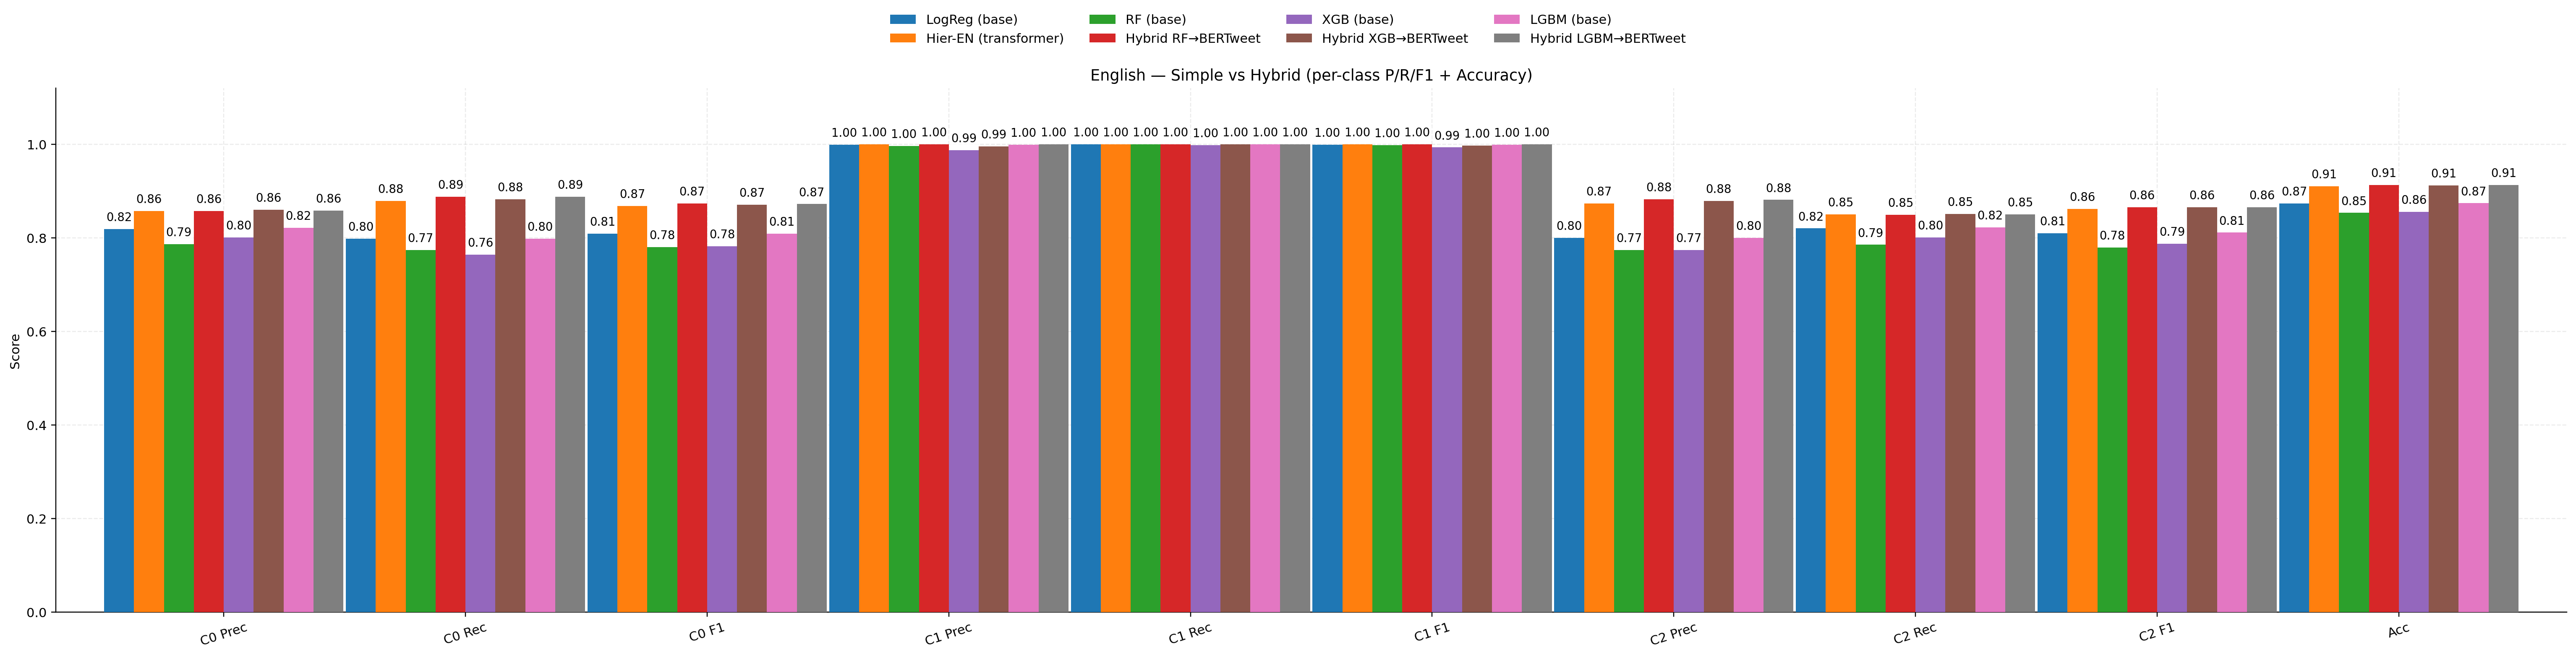

In [9]:
# ============================================
# English — HYBRID vs SIMPLE (ONE histogram)
# Bars show: [C0 P, C0 R, C0 F1, C1 P, C1 R, C1 F1, C2 P, C2 R, C2 F1, ACC]
# Pairs each base model with its hybrid counterpart.
# ============================================

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from collections import OrderedDict

OUT_PATH = "artifacts_compare/hybrid_en_acc_pr_re_f1.png"

# ---- Data pulled from your logs (edit if needed) ----
MODELS = OrderedDict([
    # Family 1: LogReg (base) vs Hier-EN (transformer)
    ("LogReg (base)", {
        "ACC": 0.8731,
        "per_class": {
            0: {"P": 0.819, "R": 0.798, "F1": 0.809},
            1: {"P": 0.999, "R": 1.000, "F1": 0.999},
            2: {"P": 0.800, "R": 0.820, "F1": 0.810},
        }
    }),
    ("Hier-EN (transformer)", {
        "ACC": 0.9101,
        "per_class": {
            0: {"P": 0.857, "R": 0.879, "F1": 0.868},
            1: {"P": 1.000, "R": 1.000, "F1": 1.000},
            2: {"P": 0.873, "R": 0.850, "F1": 0.862},
        }
    }),

    # Family 2: RF (base) vs Hybrid RF→BERTweet
    ("RF (base)", {
        "ACC": 0.8531,
        "per_class": {
            0: {"P": 0.786, "R": 0.774, "F1": 0.780},
            1: {"P": 0.996, "R": 1.000, "F1": 0.998},
            2: {"P": 0.774, "R": 0.785, "F1": 0.779},
        }
    }),
    ("Hybrid RF→BERTweet", {
        "ACC": 0.9130,
        "per_class": {
            0: {"P": 0.857, "R": 0.888, "F1": 0.873},
            1: {"P": 1.000, "R": 1.000, "F1": 1.000},
            2: {"P": 0.882, "R": 0.849, "F1": 0.865},
        }
    }),

    # Family 3: XGB (base) vs Hybrid XGB→BERTweet
    ("XGB (base)", {
        "ACC": 0.8551,
        "per_class": {
            0: {"P": 0.801, "R": 0.764, "F1": 0.782},
            1: {"P": 0.987, "R": 0.998, "F1": 0.993},
            2: {"P": 0.774, "R": 0.801, "F1": 0.787},
        }
    }),
    ("Hybrid XGB→BERTweet", {
        "ACC": 0.9115,
        "per_class": {
            0: {"P": 0.860, "R": 0.882, "F1": 0.871},
            1: {"P": 0.995, "R": 1.000, "F1": 0.997},
            2: {"P": 0.879, "R": 0.851, "F1": 0.865},
        }
    }),

    # Family 4: LGBM (base) vs Hybrid LGBM→BERTweet
    ("LGBM (base)", {
        "ACC": 0.8738,
        "per_class": {
            0: {"P": 0.821, "R": 0.798, "F1": 0.809},
            1: {"P": 0.999, "R": 1.000, "F1": 0.999},
            2: {"P": 0.800, "R": 0.822, "F1": 0.811},
        }
    }),
    ("Hybrid LGBM→BERTweet", {
        "ACC": 0.9130,
        "per_class": {
            0: {"P": 0.858, "R": 0.888, "F1": 0.872},
            1: {"P": 1.000, "R": 1.000, "F1": 1.000},
            2: {"P": 0.881, "R": 0.850, "F1": 0.865},
        }
    }),
])

FAMILIES = [
    ("LogReg (base)", "Hier-EN (transformer)"),
    ("RF (base)", "Hybrid RF→BERTweet"),
    ("XGB (base)", "Hybrid XGB→BERTweet"),
    ("LGBM (base)", "Hybrid LGBM→BERTweet"),
]

def _fmt(v): return f"{v:.2f}"

def _draw_labels(ax, bars, ymax, inside=False):
    for b in bars:
        v = b.get_height()
        y = max(v - 0.03, 0.02) if inside else min(v + 0.012, ymax - 0.015)
        va = "top" if inside else "bottom"
        ax.text(
            b.get_x() + b.get_width()/2, y, _fmt(v),
            ha="center", va=va, fontsize=9,
            bbox=dict(boxstyle="round,pad=0.15", fc="white", ec="none", alpha=0.85),
            zorder=5
        )

def plot_hybrid(save_path=OUT_PATH, labels_inside=False):
    labels = ["C0 Prec","C0 Rec","C0 F1","C1 Prec","C1 Rec","C1 F1","C2 Prec","C2 Rec","C2 F1","Acc"]
    X = np.arange(len(labels))
    series = [m for fam in FAMILIES for m in fam if m in MODELS]
    n_series = len(series)

    # Thicker bars + wide canvas so labels don’t get cut
    group_w = 0.99
    bar_w   = min(group_w / n_series, 0.40)
    offsets = (np.arange(n_series) - (n_series-1)/2) * bar_w

    plt.rcParams.update({
        "figure.dpi": 220,
        "axes.spines.top": False, "axes.spines.right": False,
        "axes.grid": True, "grid.alpha": 0.25, "grid.linestyle": "--",
    })
    fig = plt.figure(figsize=(28, 7))
    ax  = plt.gca()
    ymax = 1.12
    ax.set_ylim(0, ymax)
    ax.margins(x=0.02, y=0.04)

    for i, name in enumerate(series):
        m = MODELS[name]
        vals = [
            m["per_class"][0]["P"], m["per_class"][0]["R"], m["per_class"][0]["F1"],
            m["per_class"][1]["P"], m["per_class"][1]["R"], m["per_class"][1]["F1"],
            m["per_class"][2]["P"], m["per_class"][2]["R"], m["per_class"][2]["F1"],
            m["ACC"],
        ]
        bars = ax.bar(X + offsets[i], vals, width=bar_w, zorder=3, label=name)
        _draw_labels(ax, bars, ymax, inside=labels_inside)

    ax.set_xticks(X, labels, rotation=18)
    ax.set_ylabel("Score")
    ax.set_title("English — Simple vs Hybrid (per-class P/R/F1 + Accuracy)")
    h, t = ax.get_legend_handles_labels()
    fig.legend(h, t, ncol=4, loc="upper center", bbox_to_anchor=(0.5, 1.02), frameon=False)

    Path(save_path).parent.mkdir(parents=True, exist_ok=True)
    fig.tight_layout(rect=[0,0,1,0.94])
    fig.savefig(save_path, bbox_inches="tight")
    print(f"Saved → {save_path}")

if __name__ == "__main__":
    plot_hybrid(OUT_PATH, labels_inside=False)  # set True to print numbers inside bars


### Non-English Dataset

In [25]:
# ============================================
# NON-ENGLISH Hybrid Sentiment
# Stage-1: Logistic Regression (char TF-IDF + numeric w/o VADER)
# Stage-2: XLM-RoBERTa (CardiffNLP) fine-tune for PN/3-class
# --------------------------------------------
# Matching your EN BERTweet hybrid, but for NON-EN data.
# Saves artifacts + a simple hierarchical evaluator with accept_conf routing.
# ============================================

import os
os.environ["CUDA_VISIBLE_DEVICES"] = ""
os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"  # if MPS not available
os.environ["PYTORCH_MPS_HIGH_WATERMARK_RATIO"] = "0.0"

import os, json, random
from pathlib import Path
import numpy as np
import pandas as pd
import joblib
import scipy.sparse as sp

# sklearn
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import MaxAbsScaler, FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, classification_report,
    precision_recall_fscore_support, roc_auc_score
)

# HF Transformers
import torch
from datasets import Dataset, DatasetDict
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    DataCollatorWithPadding, Trainer, TrainingArguments,
    TrainerCallback,
)

# ---------------- paths ----------------
NON_EN_PATH   = "fe/non_en_base.parquet"
LR_DIR        = Path("artifacts_lr_non_en");         LR_DIR.mkdir(parents=True, exist_ok=True)
TRF_NONEN_DIR = Path("artifacts_trf/non_en_xlmr");   TRF_NONEN_DIR.mkdir(parents=True, exist_ok=True)
HIER_DIR      = Path("artifacts_hier");              HIER_DIR.mkdir(parents=True, exist_ok=True)

# ---------------- config ----------------
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
TEXT_COL, LABEL_COL = "clean_text", "sentiment"

# Engineered numeric features (no VADER for non-EN)
NUMERIC_COLS_ALL = [
    "vader_score","vader_bucket","hour","day_of_week","is_weekend",
    "text_length","word_count","char_density",
    "has_mentions","has_hashtags","has_links","is_question",
    "sentiment_keyword_count","negation_count","capital_word_count","emoji_count",
    "positive_lexicon_count","negative_lexicon_count",
    "punctuation_count",
    "extended_positive_lexicon_count","extended_negative_lexicon_count",
    "lang_en","lang_arabic","lang_indic","lang_cyril","lang_cjk","lang_latin_other",
    "emoji_polarity",
]
NON_EN_NUMERIC = [c for c in NUMERIC_COLS_ALL if c not in ("vader_score","vader_bucket")]

class MpsMemoryCleanerCallback(TrainerCallback):
    def on_epoch_end(self, args, state, control, **kwargs):
        try:
            if torch.backends.mps.is_available():
                torch.mps.empty_cache()
        except Exception:
            pass

# ---------------- utils ----------------
def load_df(path: str) -> pd.DataFrame:
    df = pd.read_parquet(path)
    keep = [c for c in df.columns if c in NON_EN_NUMERIC]
    df = df[[TEXT_COL, LABEL_COL] + keep].dropna(subset=[TEXT_COL, LABEL_COL]).copy()
    df[LABEL_COL] = df[LABEL_COL].astype(int)
    return df

# =========================
# STAGE 1: Logistic Regression (NON-EN)
# =========================

def _to_csr(X):
    return sp.csr_matrix(X)

def build_logreg_pipeline_non_en():
    # Char n-grams are robust for multilingual text/noisy scripts
    tfidf = TfidfVectorizer(
        analyzer="char_wb", ngram_range=(3,5),
        min_df=2, max_df=0.95, lowercase=False, sublinear_tf=True,
        max_features=200_000,
    )
    pre = ColumnTransformer([
        ("tfidf", tfidf, TEXT_COL),
        ("num", Pipeline([
            ("scale", MaxAbsScaler()),
            ("to_sparse", FunctionTransformer(_to_csr, accept_sparse=True,
                                             check_inverse=False, validate=False)),
        ]), NON_EN_NUMERIC),
    ], sparse_threshold=1.0)

    clf = LogisticRegression(
        solver="saga", max_iter=2000,
        class_weight="balanced",
        random_state=SEED,
    )
    return Pipeline([("prep", pre), ("clf", clf)])

def train_logreg_non_en(df: pd.DataFrame) -> Path:
    pipe = build_logreg_pipeline_non_en()
    Xtr, Xte, ytr, yte = train_test_split(
        df[[TEXT_COL] + NON_EN_NUMERIC], df[LABEL_COL],
        test_size=0.20, stratify=df[LABEL_COL], random_state=SEED,
    )
    pipe.fit(Xtr, ytr)

    yhat  = pipe.predict(Xte)
    proba = pipe.predict_proba(Xte)
    acc   = accuracy_score(yte, yhat)
    aucm  = roc_auc_score(yte, proba, multi_class="ovr", average="macro")
    print(f"[LogReg-nonEN] acc={acc:.4f}  macroAUC={aucm:.4f}")
    print(classification_report(yte, yhat, digits=3))

    model_path = LR_DIR / "logreg_non_en.joblib"
    joblib.dump(pipe, model_path)
    with open(LR_DIR / "logreg_non_en_summary.json", "w") as f:
        json.dump({"acc_test": float(acc), "macro_auc_test": float(aucm)}, f, indent=2)
    return model_path

# =========================
# STAGE 2: XLM-R (CardiffNLP) fine-tune
# =========================

def df_to_hf(df: pd.DataFrame, test_size=0.2) -> DatasetDict:
    tr, te = train_test_split(df, test_size=test_size, stratify=df[LABEL_COL], random_state=SEED)
    return DatasetDict({
        "train": Dataset.from_pandas(tr.reset_index(drop=True)),
        "test":  Dataset.from_pandas(te.reset_index(drop=True)),
    })

def preprocess_examples(examples, tokenizer, max_len=96):
    enc = tokenizer(examples[TEXT_COL], truncation=True, max_length=max_len)
    enc["labels"] = examples[LABEL_COL]
    return enc

def train_xlmr_non_en(df: pd.DataFrame, out_dir: Path,
                      epochs: int = 2, batch: int = 4,
                      lr: float = 2e-5, weight_decay: float = 0.01,
                      max_len: int = 96,
                      grad_ckpt: bool = True,
                      grad_accum_steps: int = 3) -> Path:
    out_dir = Path(out_dir); out_dir.mkdir(parents=True, exist_ok=True)
    pretrained = "cardiffnlp/twitter-xlm-roberta-base-sentiment"

    tok = AutoTokenizer.from_pretrained(pretrained, use_fast=True)
    model = AutoModelForSequenceClassification.from_pretrained(
        pretrained, num_labels=3, ignore_mismatched_sizes=True
    )
    model.config.use_cache = False

    if grad_ckpt and hasattr(model, "gradient_checkpointing_enable"):
        model.gradient_checkpointing_enable()

    dsd = df_to_hf(df)
    tokenized = dsd.map(
        lambda ex: preprocess_examples(ex, tok, max_len),
        batched=True,
        remove_columns=dsd["train"].column_names,
    )
    collator = DataCollatorWithPadding(tokenizer=tok)

    use_mps = torch.backends.mps.is_available()
    args = TrainingArguments(
        output_dir=str(out_dir),
        eval_strategy="epoch",
        save_strategy="epoch",
        logging_strategy="steps",
        logging_steps=100,
        learning_rate=lr,
        per_device_train_batch_size=batch,
        per_device_eval_batch_size=2,
        gradient_accumulation_steps=grad_accum_steps,
        num_train_epochs=epochs,
        weight_decay=weight_decay,
        load_best_model_at_end=True,
        metric_for_best_model="f1_macro",
        greater_is_better=True,
        seed=SEED,
        report_to=[],
        dataloader_num_workers=0,
        dataloader_pin_memory=False,
        no_cuda=True,         # force CPU training to avoid MPS OOM
        use_mps_device=False, # ---
        fp16=not use_mps,     # ignored on CPU
        bf16=False,
        gradient_checkpointing=grad_ckpt,
        max_grad_norm=1.0,
    )
    model = model.to("cpu")

    def compute_metrics(eval_pred):
        logits, labels = eval_pred
        preds = np.argmax(logits, axis=-1)
        acc = accuracy_score(labels, preds)
        p, r, f1, _ = precision_recall_fscore_support(labels, preds, average="macro", zero_division=0)
        return {"accuracy": acc, "precision_macro": p, "recall_macro": r, "f1_macro": f1}

    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=tokenized["train"],
        eval_dataset=tokenized["test"],
        tokenizer=tok,
        data_collator=collator,
        compute_metrics=compute_metrics,
        callbacks=[MpsMemoryCleanerCallback()],
    )

    trainer.train()
    eval_res = trainer.evaluate()
    print(f"[XLM-R (CardiffNLP)] eval:", eval_res)

    trainer.save_model(); tok.save_pretrained(out_dir)
    with open(out_dir / "eval_results.json", "w") as f:
        json.dump(eval_res, f, indent=2)
    return out_dir

# =========================
# HIERARCHICAL INFERENCE (LogReg → XLM-R)
# =========================

@torch.inference_mode()
def hierarchical_predict_non_en(df: pd.DataFrame,
                               lr_path: Path,
                               trf_dir: Path,
                               accept_conf: float = 0.80,
                               max_len: int = 96,
                               device: str | None = "cpu"):
    """
    Step 1: Logistic Regression on FULL DF (text + numeric).
    If max prob >= accept_conf, keep LR.
    Else: route to XLM-R on TEXT only.
    Returns: final_pred, which_stage ("LR"/"TRF"), lr_max_prob, lr_pred
    """
    # Force CPU by default to avoid MPS OOM; allow override via `device` arg
    device = "cpu" if device is None else device

    # Stage-1: LR (expects TEXT + numeric)
    lr = joblib.load(lr_path)
    lr_proba = lr.predict_proba(df)
    lr_pred  = lr_proba.argmax(axis=1)
    maxp     = lr_proba.max(axis=1)

    final = lr_pred.copy()
    which = np.array(["LR"] * len(df), dtype=object)

    # Route hard cases to XLM-R
    idx = np.where(maxp < accept_conf)[0]
    if len(idx) > 0:
        tok = AutoTokenizer.from_pretrained(trf_dir, use_fast=True)
        mdl = AutoModelForSequenceClassification.from_pretrained(trf_dir).to(device).eval()
        texts = df.iloc[idx][TEXT_COL].tolist()
        bs = 16  # smaller batch to be extra safe
        for i in range(0, len(idx), bs):
            enc = tok(
                texts[i:i+bs],
                return_tensors="pt",
                truncation=True,
                padding=True,
                max_length=max_len
            )
            if device != "cpu":
                enc = {k: v.to(device) for k, v in enc.items()}
            logits = mdl(**enc).logits
            final[idx[i:i+bs]] = logits.argmax(-1).cpu().numpy()
            which[idx[i:i+bs]] = "TRF"

    return final.astype(int), which, maxp, lr_pred.astype(int)

def evaluate_hier_non_en(df: pd.DataFrame, lr_path: Path, trf_dir: Path,
                         accept_conf: float = 0.80, max_len: int = 96,
                         out_name: str = "hier_non_en_logreg_xlmr_summary.json",
                         device: str = "cpu"):
    y = df[LABEL_COL].to_numpy()
    yhat, which, _, _ = hierarchical_predict_non_en(
        df, lr_path, trf_dir, accept_conf, max_len, device=device
    )
    acc = accuracy_score(y, yhat)
    p, r, f1, _ = precision_recall_fscore_support(y, yhat, labels=[0,1,2], average=None, zero_division=0)

    routed_pct = float(np.mean(which == "TRF") * 100.0)
    print(f"[Hier-NONEN LogReg→XLMR] thr={accept_conf:.2f}  acc={acc:.4f}  routed_to_TRF={routed_pct:.1f}%")
    print(classification_report(y, yhat, digits=3))

    HIER_DIR.mkdir(parents=True, exist_ok=True)
    with open(HIER_DIR / out_name, "w") as f:
        json.dump({
            "accept_conf": float(accept_conf),
            "accuracy": float(acc),
            "routed_to_transformer_percent": routed_pct,
            "per_class": {
                "precision": [float(x) for x in p],
                "recall":    [float(x) for x in r],
                "f1":        [float(x) for x in f1],
            }
        }, f, indent=2)

# =========================
# RUN
# =========================
if __name__ == "__main__":
    # Load NON-EN dataset
    non_en_df = load_df(NON_EN_PATH)

    # Stage-1: Logistic Regression (char TF-IDF + numeric w/o VADER)
    lr_path = train_logreg_non_en(non_en_df)

    # Stage-2: XLM-R (CardiffNLP) fine-tune (CPU)
    train_xlmr_non_en(non_en_df, TRF_NONEN_DIR, epochs=2, batch=4, lr=2e-5, weight_decay=0.01, max_len=96)

    # Evaluate hierarchical on a fresh split (force CPU for routing)
    _, non_en_te = train_test_split(non_en_df, test_size=0.20, stratify=non_en_df[LABEL_COL], random_state=SEED)
    evaluate_hier_non_en(non_en_te, lr_path, TRF_NONEN_DIR, accept_conf=0.80, max_len=96, device="cpu")


[LogReg-nonEN] acc=0.8840  macroAUC=0.9668
              precision    recall  f1-score   support

           0      0.798     0.790     0.794      6875
           1      0.997     0.999     0.998      9919
           2      0.814     0.819     0.817      7645

    accuracy                          0.884     24439
   macro avg      0.870     0.869     0.870     24439
weighted avg      0.884     0.884     0.884     24439



Map: 100%|█████████████████████| 24439/24439 [00:00<00:00, 159944.01 examples/s]
/Users/yasmeenazmatali/envs/hier-sent/lib/python3.10/site-packages/transformers/training_args.py:1636: FutureWarning: using `no_cuda` is deprecated and will be removed in version 5.0 of 🤗 Transformers. Use `use_cpu` instead
  warnings.warn(
/var/folders/s1/fblnjj651912vs_d54bjg80m0000gn/T/ipykernel_50654/1350334421.py:213: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,Accuracy,Precision Macro,Recall Macro,F1 Macro
1,0.255100,0.264050,0.906297,0.895401,0.893838,0.894368
2,0.193000,0.285169,0.909325,0.897996,0.898418,0.898128


[XLM-R (CardiffNLP)] eval: {'eval_loss': 0.2851686477661133, 'eval_accuracy': 0.9093252588076435, 'eval_precision_macro': 0.897995975543365, 'eval_recall_macro': 0.8984180734232875, 'eval_f1_macro': 0.898128422228368, 'eval_runtime': 287.2047, 'eval_samples_per_second': 85.093, 'eval_steps_per_second': 42.548, 'epoch': 2.0}
[Hier-NONEN LogReg→XLMR] thr=0.80  acc=0.9088  routed_to_TRF=28.1%
              precision    recall  f1-score   support

           0      0.830     0.850     0.840      6875
           1      0.999     1.000     0.999      9919
           2      0.862     0.843     0.853      7645

    accuracy                          0.909     24439
   macro avg      0.897     0.898     0.897     24439
weighted avg      0.909     0.909     0.909     24439



In [27]:
# ============================================
# NON-ENGLISH Hybrid Sentiment
# Stage-1: Random Forest (char TF-IDF + numeric w/o VADER)
# Stage-2: XLM-RoBERTa (CardiffNLP) fine-tune for PN/3-class
# --------------------------------------------
# Saves artifacts + a simple hierarchical evaluator with accept_conf routing.
# ============================================

import os
os.environ["CUDA_VISIBLE_DEVICES"] = ""
os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"   # if MPS not available
os.environ["PYTORCH_MPS_HIGH_WATERMARK_RATIO"] = "0.0"

import json, random
from pathlib import Path
import numpy as np
import pandas as pd
import joblib
import scipy.sparse as sp

# sklearn
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import MaxAbsScaler, FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, classification_report,
    precision_recall_fscore_support, roc_auc_score
)
from sklearn.ensemble import RandomForestClassifier

# HF Transformers
import torch
from datasets import Dataset, DatasetDict
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    DataCollatorWithPadding, Trainer, TrainingArguments,
    TrainerCallback,
)

# ---------------- paths ----------------
NON_EN_PATH   = "fe/non_en_base.parquet"
RF_DIR        = Path("artifacts_rf_non_en");         RF_DIR.mkdir(parents=True, exist_ok=True)
TRF_NONEN_DIR = Path("artifacts_trf/non_en_xlmr");   TRF_NONEN_DIR.mkdir(parents=True, exist_ok=True)
HIER_DIR      = Path("artifacts_hier");              HIER_DIR.mkdir(parents=True, exist_ok=True)

# ---------------- config ----------------
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
TEXT_COL, LABEL_COL = "clean_text", "sentiment"

# Engineered numeric features (no VADER for non-EN)
NUMERIC_COLS_ALL = [
    "vader_score","vader_bucket","hour","day_of_week","is_weekend",
    "text_length","word_count","char_density",
    "has_mentions","has_hashtags","has_links","is_question",
    "sentiment_keyword_count","negation_count","capital_word_count","emoji_count",
    "positive_lexicon_count","negative_lexicon_count",
    "punctuation_count",
    "extended_positive_lexicon_count","extended_negative_lexicon_count",
    "lang_en","lang_arabic","lang_indic","lang_cyril","lang_cjk","lang_latin_other",
    "emoji_polarity",
]
NON_EN_NUMERIC = [c for c in NUMERIC_COLS_ALL if c not in ("vader_score","vader_bucket")]

class MpsMemoryCleanerCallback(TrainerCallback):
    def on_epoch_end(self, args, state, control, **kwargs):
        try:
            if torch.backends.mps.is_available():
                torch.mps.empty_cache()
        except Exception:
            pass

# ---------------- utils ----------------
def load_df(path: str) -> pd.DataFrame:
    df = pd.read_parquet(path)
    keep = [c for c in df.columns if c in NON_EN_NUMERIC]
    df = df[[TEXT_COL, LABEL_COL] + keep].dropna(subset=[TEXT_COL, LABEL_COL]).copy()
    df[LABEL_COL] = df[LABEL_COL].astype(int)
    return df

# =========================
# STAGE 1: Random Forest (NON-EN)
# =========================
def _to_csr(X):
    return sp.csr_matrix(X)

def build_rf_pipeline_non_en():
    # Char n-grams are robust for multilingual/noisy scripts
    tfidf = TfidfVectorizer(
        analyzer="char_wb", ngram_range=(3,5),
        min_df=2, max_df=0.95, lowercase=False, sublinear_tf=True,
        max_features=200_000,
    )
    pre = ColumnTransformer([
        ("tfidf", tfidf, TEXT_COL),
        ("num", Pipeline([
            ("scale", MaxAbsScaler()),
            ("to_sparse", FunctionTransformer(_to_csr, accept_sparse=True,
                                             check_inverse=False, validate=False)),
        ]), NON_EN_NUMERIC),
    ], sparse_threshold=1.0)

    clf = RandomForestClassifier(
        n_estimators=200,
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=1,
        max_features="sqrt",
        class_weight="balanced",
        n_jobs=-1,
        random_state=SEED,
        verbose=0,
    )
    return Pipeline([("prep", pre), ("clf", clf)])

def train_rf_non_en(df: pd.DataFrame) -> Path:
    pipe = build_rf_pipeline_non_en()
    Xtr, Xte, ytr, yte = train_test_split(
        df[[TEXT_COL] + NON_EN_NUMERIC], df[LABEL_COL],
        test_size=0.20, stratify=df[LABEL_COL], random_state=SEED,
    )
    pipe.fit(Xtr, ytr)

    yhat  = pipe.predict(Xte)
    proba = pipe.predict_proba(Xte)
    acc   = accuracy_score(yte, yhat)
    aucm  = roc_auc_score(yte, proba, multi_class="ovr", average="macro")
    print(f"[RF-nonEN] acc={acc:.4f}  macroAUC={aucm:.4f}")
    print(classification_report(yte, yhat, digits=3))

    model_path = RF_DIR / "rf_non_en.joblib"
    joblib.dump(pipe, model_path)
    with open(RF_DIR / "rf_non_en_summary.json", "w") as f:
        json.dump({"acc_test": float(acc), "macro_auc_test": float(aucm)}, f, indent=2)
    return model_path

# =========================
# STAGE 2: XLM-R (CardiffNLP) fine-tune (CPU)
# =========================
def df_to_hf(df: pd.DataFrame, test_size=0.2) -> DatasetDict:
    tr, te = train_test_split(df, test_size=test_size, stratify=df[LABEL_COL], random_state=SEED)
    return DatasetDict({
        "train": Dataset.from_pandas(tr.reset_index(drop=True)),
        "test":  Dataset.from_pandas(te.reset_index(drop=True)),
    })

def preprocess_examples(examples, tokenizer, max_len=96):
    enc = tokenizer(examples[TEXT_COL], truncation=True, max_length=max_len)
    enc["labels"] = examples[LABEL_COL]
    return enc

def train_xlmr_non_en(df: pd.DataFrame, out_dir: Path,
                      epochs: int = 2, batch: int = 4,
                      lr: float = 2e-5, weight_decay: float = 0.01,
                      max_len: int = 96,
                      grad_ckpt: bool = True,
                      grad_accum_steps: int = 3) -> Path:
    out_dir = Path(out_dir); out_dir.mkdir(parents=True, exist_ok=True)
    pretrained = "cardiffnlp/twitter-xlm-roberta-base-sentiment"

    tok = AutoTokenizer.from_pretrained(pretrained, use_fast=True)
    model = AutoModelForSequenceClassification.from_pretrained(
        pretrained, num_labels=3, ignore_mismatched_sizes=True
    )
    model.config.use_cache = False
    if grad_ckpt and hasattr(model, "gradient_checkpointing_enable"):
        model.gradient_checkpointing_enable()

    dsd = df_to_hf(df)
    tokenized = dsd.map(
        lambda ex: preprocess_examples(ex, tok, max_len),
        batched=True,
        remove_columns=dsd["train"].column_names,
    )
    collator = DataCollatorWithPadding(tokenizer=tok)

    args = TrainingArguments(
        output_dir=str(out_dir),
        eval_strategy="epoch",
        save_strategy="epoch",
        logging_strategy="steps",
        logging_steps=100,
        learning_rate=lr,
        per_device_train_batch_size=batch,
        per_device_eval_batch_size=2,
        gradient_accumulation_steps=grad_accum_steps,
        num_train_epochs=epochs,
        weight_decay=weight_decay,
        load_best_model_at_end=True,
        metric_for_best_model="f1_macro",
        greater_is_better=True,
        seed=SEED,
        report_to=[],
        dataloader_num_workers=0,
        dataloader_pin_memory=False,
        no_cuda=True,         # force CPU
        use_mps_device=False,
        fp16=False,
        bf16=False,
        gradient_checkpointing=grad_ckpt,
        max_grad_norm=1.0,
    )
    model = model.to("cpu")

    def compute_metrics(eval_pred):
        logits, labels = eval_pred
        preds = np.argmax(logits, axis=-1)
        acc = accuracy_score(labels, preds)
        p, r, f1, _ = precision_recall_fscore_support(labels, preds, average="macro", zero_division=0)
        return {"accuracy": acc, "precision_macro": p, "recall_macro": r, "f1_macro": f1}

    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=tokenized["train"],
        eval_dataset=tokenized["test"],
        tokenizer=tok,
        data_collator=collator,
        compute_metrics=compute_metrics,
        callbacks=[MpsMemoryCleanerCallback()],
    )

    trainer.train()
    eval_res = trainer.evaluate()
    print(f"[XLM-R (CardiffNLP)] eval:", eval_res)

    trainer.save_model(); tok.save_pretrained(out_dir)
    with open(out_dir / "eval_results.json", "w") as f:
        json.dump(eval_res, f, indent=2)
    return out_dir

# =========================
# HIERARCHICAL INFERENCE (RF → XLM-R)  (CPU by default)
# =========================
@torch.inference_mode()
def hierarchical_predict_non_en(df: pd.DataFrame,
                                rf_path: Path,
                                trf_dir: Path,
                                accept_conf: float = 0.80,
                                max_len: int = 96,
                                device: str | None = "cpu"):
    """
    Step 1: Random Forest on FULL DF (text + numeric).
    If max prob >= accept_conf, keep RF.
    Else: route to XLM-R on TEXT only.
    Returns: final_pred, which_stage ("RF"/"TRF"), rf_max_prob, rf_pred
    """
    device = "cpu" if device is None else device

    # Stage-1: RF (expects TEXT + numeric)
    rf = joblib.load(rf_path)
    rf_proba = rf.predict_proba(df)
    rf_pred  = rf_proba.argmax(axis=1)
    maxp     = rf_proba.max(axis=1)

    final = rf_pred.copy()
    which = np.array(["RF"] * len(df), dtype=object)

    # Route hard cases to XLM-R
    idx = np.where(maxp < accept_conf)[0]
    if len(idx) > 0:
        tok = AutoTokenizer.from_pretrained(trf_dir, use_fast=True)
        mdl = AutoModelForSequenceClassification.from_pretrained(trf_dir).to(device).eval()
        texts = df.iloc[idx][TEXT_COL].tolist()
        bs = 16  # conservative batch on CPU
        for i in range(0, len(idx), bs):
            enc = tok(
                texts[i:i+bs],
                return_tensors="pt",
                truncation=True,
                padding=True,
                max_length=max_len
            )
            if device != "cpu":
                enc = {k: v.to(device) for k, v in enc.items()}
            logits = mdl(**enc).logits
            final[idx[i:i+bs]] = logits.argmax(-1).cpu().numpy()
            which[idx[i:i+bs]] = "TRF"

    return final.astype(int), which, maxp, rf_pred.astype(int)

def evaluate_hier_non_en(df: pd.DataFrame, rf_path: Path, trf_dir: Path,
                         accept_conf: float = 0.80, max_len: int = 96,
                         out_name: str = "hier_non_en_rf_xlmr_summary.json",
                         device: str = "cpu"):
    y = df[LABEL_COL].to_numpy()
    yhat, which, _, _ = hierarchical_predict_non_en(
        df, rf_path, trf_dir, accept_conf, max_len, device=device
    )
    acc = accuracy_score(y, yhat)
    p, r, f1, _ = precision_recall_fscore_support(y, yhat, labels=[0,1,2], average=None, zero_division=0)

    routed_pct = float(np.mean(which == "TRF") * 100.0)
    print(f"[Hier-NONEN RF→XLMR] thr={accept_conf:.2f}  acc={acc:.4f}  routed_to_TRF={routed_pct:.1f}%")
    print(classification_report(y, yhat, digits=3))

    HIER_DIR.mkdir(parents=True, exist_ok=True)
    with open(HIER_DIR / out_name, "w") as f:
        json.dump({
            "accept_conf": float(accept_conf),
            "accuracy": float(acc),
            "routed_to_transformer_percent": routed_pct,
            "per_class": {
                "precision": [float(x) for x in p],
                "recall":    [float(x) for x in r],
                "f1":        [float(x) for x in f1],
            }
        }, f, indent=2)

# =========================
# RUN
# =========================
if __name__ == "__main__":
    # Load NON-EN dataset
    non_en_df = load_df(NON_EN_PATH)

    # Stage-1: Random Forest (char TF-IDF + numeric w/o VADER)
    rf_path = train_rf_non_en(non_en_df)

    # Stage-2: XLM-R (CardiffNLP) fine-tune (CPU)
    train_xlmr_non_en(
        non_en_df, TRF_NONEN_DIR,
        epochs=2, batch=4, lr=2e-5, weight_decay=0.01, max_len=96
    )

    # Evaluate hierarchical on a fresh split (CPU routing)
    _, non_en_te = train_test_split(
        non_en_df, test_size=0.20, stratify=non_en_df[LABEL_COL], random_state=SEED
    )
    evaluate_hier_non_en(
        non_en_te, rf_path, TRF_NONEN_DIR,
        accept_conf=0.80, max_len=96, device="cpu"
    )


[RF-nonEN] acc=0.8729  macroAUC=0.9616
              precision    recall  f1-score   support

           0      0.810     0.736     0.771      6875
           1      0.983     0.997     0.990      9919
           2      0.785     0.835     0.809      7645

    accuracy                          0.873     24439
   macro avg      0.859     0.856     0.857     24439
weighted avg      0.872     0.873     0.872     24439



Map: 100%|██████████████████████| 24439/24439 [00:00<00:00, 88712.93 examples/s]
/Users/yasmeenazmatali/envs/hier-sent/lib/python3.10/site-packages/transformers/training_args.py:1636: FutureWarning: using `no_cuda` is deprecated and will be removed in version 5.0 of 🤗 Transformers. Use `use_cpu` instead
  warnings.warn(
/var/folders/s1/fblnjj651912vs_d54bjg80m0000gn/T/ipykernel_50654/1318986969.py:214: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,Accuracy,Precision Macro,Recall Macro,F1 Macro
1,0.255100,0.264050,0.906297,0.895401,0.893838,0.894368
2,0.193000,0.285169,0.909325,0.897996,0.898418,0.898128


[XLM-R (CardiffNLP)] eval: {'eval_loss': 0.2851686477661133, 'eval_accuracy': 0.9093252588076435, 'eval_precision_macro': 0.897995975543365, 'eval_recall_macro': 0.8984180734232875, 'eval_f1_macro': 0.898128422228368, 'eval_runtime': 276.6141, 'eval_samples_per_second': 88.351, 'eval_steps_per_second': 44.177, 'epoch': 2.0}
[Hier-NONEN RF→XLMR] thr=0.80  acc=0.9095  routed_to_TRF=43.7%
              precision    recall  f1-score   support

           0      0.833     0.849     0.841      6875
           1      0.999     1.000     0.999      9919
           2      0.862     0.846     0.854      7645

    accuracy                          0.909     24439
   macro avg      0.898     0.899     0.898     24439
weighted avg      0.910     0.909     0.910     24439



In [28]:
# ============================================
# NON-ENGLISH Hybrid Sentiment
# Stage-1: XGBoost (char TF-IDF + numeric w/o VADER)
# Stage-2: XLM-RoBERTa (CardiffNLP) fine-tune for PN/3-class
# --------------------------------------------
# Saves artifacts + a simple hierarchical evaluator with accept_conf routing.
# ============================================

import os
os.environ["CUDA_VISIBLE_DEVICES"] = ""
os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"   # if MPS not available
os.environ["PYTORCH_MPS_HIGH_WATERMARK_RATIO"] = "0.0"

import json, random
from pathlib import Path
import numpy as np
import pandas as pd
import joblib
import scipy.sparse as sp

# sklearn
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import MaxAbsScaler, FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, classification_report,
    precision_recall_fscore_support, roc_auc_score
)
from sklearn.utils.class_weight import compute_class_weight

# XGBoost
from xgboost import XGBClassifier

# HF Transformers
import torch
from datasets import Dataset, DatasetDict
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    DataCollatorWithPadding, Trainer, TrainingArguments,
    TrainerCallback,
)

# ---------------- paths ----------------
NON_EN_PATH   = "fe/non_en_base.parquet"
XGB_DIR       = Path("artifacts_xgb_non_en");        XGB_DIR.mkdir(parents=True, exist_ok=True)
TRF_NONEN_DIR = Path("artifacts_trf/non_en_xlmr");   TRF_NONEN_DIR.mkdir(parents=True, exist_ok=True)
HIER_DIR      = Path("artifacts_hier");              HIER_DIR.mkdir(parents=True, exist_ok=True)

# ---------------- config ----------------
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
TEXT_COL, LABEL_COL = "clean_text", "sentiment"

# Engineered numeric features (no VADER for non-EN)
NUMERIC_COLS_ALL = [
    "vader_score","vader_bucket","hour","day_of_week","is_weekend",
    "text_length","word_count","char_density",
    "has_mentions","has_hashtags","has_links","is_question",
    "sentiment_keyword_count","negation_count","capital_word_count","emoji_count",
    "positive_lexicon_count","negative_lexicon_count",
    "punctuation_count",
    "extended_positive_lexicon_count","extended_negative_lexicon_count",
    "lang_en","lang_arabic","lang_indic","lang_cyril","lang_cjk","lang_latin_other",
    "emoji_polarity",
]
NON_EN_NUMERIC = [c for c in NUMERIC_COLS_ALL if c not in ("vader_score","vader_bucket")]

class MpsMemoryCleanerCallback(TrainerCallback):
    def on_epoch_end(self, args, state, control, **kwargs):
        try:
            if torch.backends.mps.is_available():
                torch.mps.empty_cache()
        except Exception:
            pass

# ---------------- utils ----------------
def load_df(path: str) -> pd.DataFrame:
    df = pd.read_parquet(path)
    keep = [c for c in df.columns if c in NON_EN_NUMERIC]
    df = df[[TEXT_COL, LABEL_COL] + keep].dropna(subset=[TEXT_COL, LABEL_COL]).copy()
    df[LABEL_COL] = df[LABEL_COL].astype(int)
    return df

def _to_csr(X):
    return sp.csr_matrix(X)

# =========================
# STAGE 1: XGBoost (NON-EN)
# =========================
def build_xgb_pipeline_non_en():
    # Char n-grams are robust for multilingual/noisy scripts
    tfidf = TfidfVectorizer(
        analyzer="char_wb", ngram_range=(3,5),
        min_df=2, max_df=0.95, lowercase=False, sublinear_tf=True,
        max_features=200_000,
    )
    pre = ColumnTransformer([
        ("tfidf", tfidf, TEXT_COL),
        ("num", Pipeline([
            ("scale", MaxAbsScaler()),
            ("to_sparse", FunctionTransformer(_to_csr, accept_sparse=True,
                                             check_inverse=False, validate=False)),
        ]), NON_EN_NUMERIC),
    ], sparse_threshold=1.0)

    # XGBClassifier can consume CSR matrices; use multi:softprob for 3-class
    clf = XGBClassifier(
        n_estimators=400,
        max_depth=8,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=1.0,
        reg_alpha=0.0,
        objective="multi:softprob",
        num_class=3,
        eval_metric="mlogloss",
        tree_method="hist",     # CPU-friendly
        random_state=SEED,
        n_jobs=-1,
        verbosity=0,
    )
    return Pipeline([("prep", pre), ("clf", clf)])

def _make_sample_weights(y: np.ndarray) -> np.ndarray:
    classes = np.unique(y)
    cw = compute_class_weight(class_weight="balanced", classes=classes, y=y)
    wmap = {c: w for c, w in zip(classes, cw)}
    return np.asarray([wmap[v] for v in y], dtype=np.float32)

def train_xgb_non_en(df: pd.DataFrame) -> Path:
    pipe = build_xgb_pipeline_non_en()
    Xtr, Xte, ytr, yte = train_test_split(
        df[[TEXT_COL] + NON_EN_NUMERIC], df[LABEL_COL],
        test_size=0.20, stratify=df[LABEL_COL], random_state=SEED,
    )

    sw = _make_sample_weights(ytr.to_numpy())
    pipe.fit(Xtr, ytr, clf__sample_weight=sw)

    yhat  = pipe.predict(Xte)
    proba = pipe.predict_proba(Xte)
    acc   = accuracy_score(yte, yhat)
    aucm  = roc_auc_score(yte, proba, multi_class="ovr", average="macro")
    print(f"[XGB-nonEN] acc={acc:.4f}  macroAUC={aucm:.4f}")
    print(classification_report(yte, yhat, digits=3))

    model_path = XGB_DIR / "xgb_non_en.joblib"
    joblib.dump(pipe, model_path)
    with open(XGB_DIR / "xgb_non_en_summary.json", "w") as f:
        json.dump({"acc_test": float(acc), "macro_auc_test": float(aucm)}, f, indent=2)
    return model_path

# =========================
# STAGE 2: XLM-R (CardiffNLP) fine-tune (CPU)
# =========================
def df_to_hf(df: pd.DataFrame, test_size=0.2) -> DatasetDict:
    tr, te = train_test_split(df, test_size=test_size, stratify=df[LABEL_COL], random_state=SEED)
    return DatasetDict({
        "train": Dataset.from_pandas(tr.reset_index(drop=True)),
        "test":  Dataset.from_pandas(te.reset_index(drop=True)),
    })

def preprocess_examples(examples, tokenizer, max_len=96):
    enc = tokenizer(examples[TEXT_COL], truncation=True, max_length=max_len)
    enc["labels"] = examples[LABEL_COL]
    return enc

def train_xlmr_non_en(df: pd.DataFrame, out_dir: Path,
                      epochs: int = 2, batch: int = 4,
                      lr: float = 2e-5, weight_decay: float = 0.01,
                      max_len: int = 96,
                      grad_ckpt: bool = True,
                      grad_accum_steps: int = 3) -> Path:
    out_dir = Path(out_dir); out_dir.mkdir(parents=True, exist_ok=True)
    pretrained = "cardiffnlp/twitter-xlm-roberta-base-sentiment"

    tok = AutoTokenizer.from_pretrained(pretrained, use_fast=True)
    model = AutoModelForSequenceClassification.from_pretrained(
        pretrained, num_labels=3, ignore_mismatched_sizes=True
    )
    model.config.use_cache = False
    if grad_ckpt and hasattr(model, "gradient_checkpointing_enable"):
        model.gradient_checkpointing_enable()

    dsd = df_to_hf(df)
    tokenized = dsd.map(
        lambda ex: preprocess_examples(ex, tok, max_len),
        batched=True,
        remove_columns=dsd["train"].column_names,
    )
    collator = DataCollatorWithPadding(tokenizer=tok)

    args = TrainingArguments(
        output_dir=str(out_dir),
        eval_strategy="epoch",
        save_strategy="epoch",
        logging_strategy="steps",
        logging_steps=100,
        learning_rate=lr,
        per_device_train_batch_size=batch,
        per_device_eval_batch_size=2,
        gradient_accumulation_steps=grad_accum_steps,
        num_train_epochs=epochs,
        weight_decay=weight_decay,
        load_best_model_at_end=True,
        metric_for_best_model="f1_macro",
        greater_is_better=True,
        seed=SEED,
        report_to=[],
        dataloader_num_workers=0,
        dataloader_pin_memory=False,
        no_cuda=True,         # force CPU
        use_mps_device=False,
        fp16=False,
        bf16=False,
        gradient_checkpointing=grad_ckpt,
        max_grad_norm=1.0,
    )
    model = model.to("cpu")

    def compute_metrics(eval_pred):
        logits, labels = eval_pred
        preds = np.argmax(logits, axis=-1)
        acc = accuracy_score(labels, preds)
        p, r, f1, _ = precision_recall_fscore_support(labels, preds, average="macro", zero_division=0)
        return {"accuracy": acc, "precision_macro": p, "recall_macro": r, "f1_macro": f1}

    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=tokenized["train"],
        eval_dataset=tokenized["test"],
        tokenizer=tok,
        data_collator=collator,
        compute_metrics=compute_metrics,
        callbacks=[MpsMemoryCleanerCallback()],
    )

    trainer.train()
    eval_res = trainer.evaluate()
    print(f"[XLM-R (CardiffNLP)] eval:", eval_res)

    trainer.save_model(); tok.save_pretrained(out_dir)
    with open(out_dir / "eval_results.json", "w") as f:
        json.dump(eval_res, f, indent=2)
    return out_dir

# =========================
# HIERARCHICAL INFERENCE (XGB → XLM-R)  (CPU by default)
# =========================
@torch.inference_mode()
def hierarchical_predict_non_en(df: pd.DataFrame,
                                xgb_path: Path,
                                trf_dir: Path,
                                accept_conf: float = 0.80,
                                max_len: int = 96,
                                device: str | None = "cpu"):
    """
    Step 1: XGBoost on FULL DF (text + numeric).
    If max prob >= accept_conf, keep XGB.
    Else: route to XLM-R on TEXT only.
    Returns: final_pred, which_stage ("XGB"/"TRF"), xgb_max_prob, xgb_pred
    """
    device = "cpu" if device is None else device

    # Stage-1: XGB (expects TEXT + numeric)
    xgb = joblib.load(xgb_path)
    xgb_proba = xgb.predict_proba(df)
    xgb_pred  = xgb_proba.argmax(axis=1)
    maxp      = xgb_proba.max(axis=1)

    final = xgb_pred.copy()
    which = np.array(["XGB"] * len(df), dtype=object)

    # Route hard cases to XLM-R
    idx = np.where(maxp < accept_conf)[0]
    if len(idx) > 0:
        tok = AutoTokenizer.from_pretrained(trf_dir, use_fast=True)
        mdl = AutoModelForSequenceClassification.from_pretrained(trf_dir).to(device).eval()
        texts = df.iloc[idx][TEXT_COL].tolist()
        bs = 16  # conservative batch on CPU
        for i in range(0, len(idx), bs):
            enc = tok(
                texts[i:i+bs],
                return_tensors="pt",
                truncation=True,
                padding=True,
                max_length=max_len
            )
            if device != "cpu":
                enc = {k: v.to(device) for k, v in enc.items()}
            logits = mdl(**enc).logits
            final[idx[i:i+bs]] = logits.argmax(-1).cpu().numpy()
            which[idx[i:i+bs]] = "TRF"

    return final.astype(int), which, maxp, xgb_pred.astype(int)

def evaluate_hier_non_en(df: pd.DataFrame, xgb_path: Path, trf_dir: Path,
                         accept_conf: float = 0.80, max_len: int = 96,
                         out_name: str = "hier_non_en_xgb_xlmr_summary.json",
                         device: str = "cpu"):
    y = df[LABEL_COL].to_numpy()
    yhat, which, _, _ = hierarchical_predict_non_en(
        df, xgb_path, trf_dir, accept_conf, max_len, device=device
    )
    acc = accuracy_score(y, yhat)
    p, r, f1, _ = precision_recall_fscore_support(y, yhat, labels=[0,1,2], average=None, zero_division=0)

    routed_pct = float(np.mean(which == "TRF") * 100.0)
    print(f"[Hier-NONEN XGB→XLMR] thr={accept_conf:.2f}  acc={acc:.4f}  routed_to_TRF={routed_pct:.1f}%")
    print(classification_report(y, yhat, digits=3))

    HIER_DIR.mkdir(parents=True, exist_ok=True)
    with open(HIER_DIR / out_name, "w") as f:
        json.dump({
            "accept_conf": float(accept_conf),
            "accuracy": float(acc),
            "routed_to_transformer_percent": routed_pct,
            "per_class": {
                "precision": [float(x) for x in p],
                "recall":    [float(x) for x in r],
                "f1":        [float(x) for x in f1],
            }
        }, f, indent=2)

# =========================
# RUN
# =========================
if __name__ == "__main__":
    # Load NON-EN dataset
    non_en_df = load_df(NON_EN_PATH)

    # Stage-1: XGBoost (char TF-IDF + numeric w/o VADER)
    xgb_path = train_xgb_non_en(non_en_df)

    # Stage-2: XLM-R (CardiffNLP) fine-tune (CPU)
    train_xlmr_non_en(
        non_en_df, TRF_NONEN_DIR,
        epochs=2, batch=4, lr=2e-5, weight_decay=0.01, max_len=96
    )

    # Evaluate hierarchical on a fresh split (CPU routing)
    _, non_en_te = train_test_split(
        non_en_df, test_size=0.20, stratify=non_en_df[LABEL_COL], random_state=SEED
    )
    evaluate_hier_non_en(
        non_en_te, xgb_path, TRF_NONEN_DIR,
        accept_conf=0.80, max_len=96, device="cpu"
    )


[XGB-nonEN] acc=0.8786  macroAUC=0.9658
              precision    recall  f1-score   support

           0      0.802     0.763     0.782      6875
           1      0.990     0.999     0.994      9919
           2      0.800     0.827     0.813      7645

    accuracy                          0.879     24439
   macro avg      0.864     0.863     0.863     24439
weighted avg      0.878     0.879     0.878     24439



Map: 100%|█████████████████████| 24439/24439 [00:00<00:00, 156246.76 examples/s]
/Users/yasmeenazmatali/envs/hier-sent/lib/python3.10/site-packages/transformers/training_args.py:1636: FutureWarning: using `no_cuda` is deprecated and will be removed in version 5.0 of 🤗 Transformers. Use `use_cpu` instead
  warnings.warn(
/var/folders/s1/fblnjj651912vs_d54bjg80m0000gn/T/ipykernel_50654/547285901.py:231: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,Accuracy,Precision Macro,Recall Macro,F1 Macro
1,0.255100,0.264050,0.906297,0.895401,0.893838,0.894368
2,0.193000,0.285169,0.909325,0.897996,0.898418,0.898128


[XLM-R (CardiffNLP)] eval: {'eval_loss': 0.2851686477661133, 'eval_accuracy': 0.9093252588076435, 'eval_precision_macro': 0.897995975543365, 'eval_recall_macro': 0.8984180734232875, 'eval_f1_macro': 0.898128422228368, 'eval_runtime': 265.4572, 'eval_samples_per_second': 92.064, 'eval_steps_per_second': 46.034, 'epoch': 2.0}
[Hier-NONEN XGB→XLMR] thr=0.80  acc=0.9092  routed_to_TRF=34.6%
              precision    recall  f1-score   support

           0      0.832     0.852     0.842      6875
           1      0.996     1.000     0.998      9919
           2      0.866     0.843     0.855      7645

    accuracy                          0.909     24439
   macro avg      0.898     0.898     0.898     24439
weighted avg      0.909     0.909     0.909     24439



In [29]:
# ============================================
# NON-ENGLISH Hybrid Sentiment
# Stage-1: LightGBM (char TF-IDF + numeric w/o VADER)
# Stage-2: XLM-RoBERTa (CardiffNLP) fine-tune for PN/3-class
# --------------------------------------------
# Saves artifacts + a simple hierarchical evaluator with accept_conf routing.
# CPU-safe (no CUDA/MPS needed).
# ============================================

# pip install lightgbm transformers datasets xgboost scikit-learn scipy joblib

import os
os.environ["CUDA_VISIBLE_DEVICES"] = ""
os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"   # if MPS not available
os.environ["PYTORCH_MPS_HIGH_WATERMARK_RATIO"] = "0.0"

import json, random
from pathlib import Path
import numpy as np
import pandas as pd
import joblib
import scipy.sparse as sp

# sklearn
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import MaxAbsScaler, FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, classification_report,
    precision_recall_fscore_support, roc_auc_score
)
from sklearn.utils.class_weight import compute_class_weight

# LightGBM
from lightgbm import LGBMClassifier

# HF Transformers
import torch
from datasets import Dataset, DatasetDict
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    DataCollatorWithPadding, Trainer, TrainingArguments,
    TrainerCallback,
)

# ---------------- paths ----------------
NON_EN_PATH   = "fe/non_en_base.parquet"
LGB_DIR       = Path("artifacts_lgb_non_en");        LGB_DIR.mkdir(parents=True, exist_ok=True)
TRF_NONEN_DIR = Path("artifacts_trf/non_en_xlmr");   TRF_NONEN_DIR.mkdir(parents=True, exist_ok=True)
HIER_DIR      = Path("artifacts_hier");              HIER_DIR.mkdir(parents=True, exist_ok=True)

# ---------------- config ----------------
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
TEXT_COL, LABEL_COL = "clean_text", "sentiment"

# Engineered numeric features (no VADER for non-EN)
NUMERIC_COLS_ALL = [
    "vader_score","vader_bucket","hour","day_of_week","is_weekend",
    "text_length","word_count","char_density",
    "has_mentions","has_hashtags","has_links","is_question",
    "sentiment_keyword_count","negation_count","capital_word_count","emoji_count",
    "positive_lexicon_count","negative_lexicon_count",
    "punctuation_count",
    "extended_positive_lexicon_count","extended_negative_lexicon_count",
    "lang_en","lang_arabic","lang_indic","lang_cyril","lang_cjk","lang_latin_other",
    "emoji_polarity",
]
NON_EN_NUMERIC = [c for c in NUMERIC_COLS_ALL if c not in ("vader_score","vader_bucket")]

class MpsMemoryCleanerCallback(TrainerCallback):
    def on_epoch_end(self, args, state, control, **kwargs):
        try:
            if torch.backends.mps.is_available():
                torch.mps.empty_cache()
        except Exception:
            pass

# ---------------- utils ----------------
def load_df(path: str) -> pd.DataFrame:
    df = pd.read_parquet(path)
    keep = [c for c in df.columns if c in NON_EN_NUMERIC]
    df = df[[TEXT_COL, LABEL_COL] + keep].dropna(subset=[TEXT_COL, LABEL_COL]).copy()
    df[LABEL_COL] = df[LABEL_COL].astype(int)
    return df

def _to_csr(X):
    return sp.csr_matrix(X)

# =========================
# STAGE 1: LightGBM (NON-EN)
# =========================
def build_lgb_pipeline_non_en():
    # Char n-grams are robust for multilingual/noisy scripts
    tfidf = TfidfVectorizer(
        analyzer="char_wb", ngram_range=(3,5),
        min_df=2, max_df=0.95, lowercase=False, sublinear_tf=True,
        max_features=200_000,
    )
    pre = ColumnTransformer([
        ("tfidf", tfidf, TEXT_COL),
        ("num", Pipeline([
            ("scale", MaxAbsScaler()),
            ("to_sparse", FunctionTransformer(_to_csr, accept_sparse=True,
                                             check_inverse=False, validate=False)),
        ]), NON_EN_NUMERIC),
    ], sparse_threshold=1.0)

    # LightGBM handles CSR; multi-class with softprob-like output via predict_proba
    clf = LGBMClassifier(
        objective="multiclass",
        num_class=3,
        n_estimators=800,
        learning_rate=0.05,
        num_leaves=255,           # good for char-ngrams
        max_depth=-1,             # no explicit limit
        subsample=0.8,
        subsample_freq=1,
        colsample_bytree=0.8,
        reg_alpha=0.0,
        reg_lambda=1.0,
        min_child_samples=20,
        n_jobs=-1,
        random_state=SEED,
        verbose=-1,
    )
    return Pipeline([("prep", pre), ("clf", clf)])

def _make_sample_weights(y: np.ndarray) -> np.ndarray:
    classes = np.unique(y)
    cw = compute_class_weight(class_weight="balanced", classes=classes, y=y)
    wmap = {c: w for c, w in zip(classes, cw)}
    return np.asarray([wmap[v] for v in y], dtype=np.float32)

def train_lgb_non_en(df: pd.DataFrame) -> Path:
    pipe = build_lgb_pipeline_non_en()
    Xtr, Xte, ytr, yte = train_test_split(
        df[[TEXT_COL] + NON_EN_NUMERIC], df[LABEL_COL],
        test_size=0.20, stratify=df[LABEL_COL], random_state=SEED,
    )

    sw = _make_sample_weights(ytr.to_numpy())
    pipe.fit(Xtr, ytr, clf__sample_weight=sw)

    yhat  = pipe.predict(Xte)
    proba = pipe.predict_proba(Xte)
    acc   = accuracy_score(yte, yhat)
    aucm  = roc_auc_score(yte, proba, multi_class="ovr", average="macro")
    print(f"[LGB-nonEN] acc={acc:.4f}  macroAUC={aucm:.4f}")
    print(classification_report(yte, yhat, digits=3))

    model_path = LGB_DIR / "lgb_non_en.joblib"
    joblib.dump(pipe, model_path)
    with open(LGB_DIR / "lgb_non_en_summary.json", "w") as f:
        json.dump({"acc_test": float(acc), "macro_auc_test": float(aucm)}, f, indent=2)
    return model_path

# =========================
# STAGE 2: XLM-R (CardiffNLP) fine-tune (CPU)
# =========================
def df_to_hf(df: pd.DataFrame, test_size=0.2) -> DatasetDict:
    tr, te = train_test_split(df, test_size=test_size, stratify=df[LABEL_COL], random_state=SEED)
    return DatasetDict({
        "train": Dataset.from_pandas(tr.reset_index(drop=True)),
        "test":  Dataset.from_pandas(te.reset_index(drop=True)),
    })

def preprocess_examples(examples, tokenizer, max_len=96):
    enc = tokenizer(examples[TEXT_COL], truncation=True, max_length=max_len)
    enc["labels"] = examples[LABEL_COL]
    return enc

def train_xlmr_non_en(df: pd.DataFrame, out_dir: Path,
                      epochs: int = 2, batch: int = 4,
                      lr: float = 2e-5, weight_decay: float = 0.01,
                      max_len: int = 96,
                      grad_ckpt: bool = True,
                      grad_accum_steps: int = 3) -> Path:
    out_dir = Path(out_dir); out_dir.mkdir(parents=True, exist_ok=True)
    pretrained = "cardiffnlp/twitter-xlm-roberta-base-sentiment"

    tok = AutoTokenizer.from_pretrained(pretrained, use_fast=True)
    model = AutoModelForSequenceClassification.from_pretrained(
        pretrained, num_labels=3, ignore_mismatched_sizes=True
    )
    model.config.use_cache = False
    if grad_ckpt and hasattr(model, "gradient_checkpointing_enable"):
        model.gradient_checkpointing_enable()

    dsd = df_to_hf(df)
    tokenized = dsd.map(
        lambda ex: preprocess_examples(ex, tok, max_len),
        batched=True,
        remove_columns=dsd["train"].column_names,
    )
    collator = DataCollatorWithPadding(tokenizer=tok)

    args = TrainingArguments(
        output_dir=str(out_dir),
        eval_strategy="epoch",
        save_strategy="epoch",
        logging_strategy="steps",
        logging_steps=100,
        learning_rate=lr,
        per_device_train_batch_size=batch,
        per_device_eval_batch_size=2,
        gradient_accumulation_steps=grad_accum_steps,
        num_train_epochs=epochs,
        weight_decay=weight_decay,
        load_best_model_at_end=True,
        metric_for_best_model="f1_macro",
        greater_is_better=True,
        seed=SEED,
        report_to=[],
        dataloader_num_workers=0,
        dataloader_pin_memory=False,
        no_cuda=True,         # force CPU
        use_mps_device=False,
        fp16=False,
        bf16=False,
        gradient_checkpointing=grad_ckpt,
        max_grad_norm=1.0,
    )
    model = model.to("cpu")

    def compute_metrics(eval_pred):
        logits, labels = eval_pred
        preds = np.argmax(logits, axis=-1)
        acc = accuracy_score(labels, preds)
        p, r, f1, _ = precision_recall_fscore_support(labels, preds, average="macro", zero_division=0)
        return {"accuracy": acc, "precision_macro": p, "recall_macro": r, "f1_macro": f1}

    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=tokenized["train"],
        eval_dataset=tokenized["test"],
        tokenizer=tok,
        data_collator=collator,
        compute_metrics=compute_metrics,
        callbacks=[MpsMemoryCleanerCallback()],
    )

    trainer.train()
    eval_res = trainer.evaluate()
    print(f"[XLM-R (CardiffNLP)] eval:", eval_res)

    trainer.save_model(); tok.save_pretrained(out_dir)
    with open(out_dir / "eval_results.json", "w") as f:
        json.dump(eval_res, f, indent=2)
    return out_dir

# =========================
# HIERARCHICAL INFERENCE (LGBM → XLM-R)  (CPU by default)
# =========================
@torch.inference_mode()
def hierarchical_predict_non_en(df: pd.DataFrame,
                                lgb_path: Path,
                                trf_dir: Path,
                                accept_conf: float = 0.80,
                                max_len: int = 96,
                                device: str | None = "cpu"):
    """
    Step 1: LightGBM on FULL DF (text + numeric).
    If max prob >= accept_conf, keep LGBM.
    Else: route to XLM-R on TEXT only.
    Returns: final_pred, which_stage ("LGBM"/"TRF"), lgb_max_prob, lgb_pred
    """
    device = "cpu" if device is None else device

    # Stage-1: LGBM (expects TEXT + numeric)
    lgb = joblib.load(lgb_path)
    lgb_proba = lgb.predict_proba(df)
    lgb_pred  = lgb_proba.argmax(axis=1)
    maxp      = lgb_proba.max(axis=1)

    final = lgb_pred.copy()
    which = np.array(["LGBM"] * len(df), dtype=object)

    # Route hard cases to XLM-R
    idx = np.where(maxp < accept_conf)[0]
    if len(idx) > 0:
        tok = AutoTokenizer.from_pretrained(trf_dir, use_fast=True)
        mdl = AutoModelForSequenceClassification.from_pretrained(trf_dir).to(device).eval()
        texts = df.iloc[idx][TEXT_COL].tolist()
        bs = 16  # conservative batch on CPU
        for i in range(0, len(idx), bs):
            enc = tok(
                texts[i:i+bs],
                return_tensors="pt",
                truncation=True,
                padding=True,
                max_length=max_len
            )
            if device != "cpu":
                enc = {k: v.to(device) for k, v in enc.items()}
            logits = mdl(**enc).logits
            final[idx[i:i+bs]] = logits.argmax(-1).cpu().numpy()
            which[idx[i:i+bs]] = "TRF"

    return final.astype(int), which, maxp, lgb_pred.astype(int)

def evaluate_hier_non_en(df: pd.DataFrame, lgb_path: Path, trf_dir: Path,
                         accept_conf: float = 0.80, max_len: int = 96,
                         out_name: str = "hier_non_en_lgb_xlmr_summary.json",
                         device: str = "cpu"):
    y = df[LABEL_COL].to_numpy()
    yhat, which, _, _ = hierarchical_predict_non_en(
        df, lgb_path, trf_dir, accept_conf, max_len, device=device
    )
    acc = accuracy_score(y, yhat)
    p, r, f1, _ = precision_recall_fscore_support(y, yhat, labels=[0,1,2], average=None, zero_division=0)

    routed_pct = float(np.mean(which == "TRF") * 100.0)
    print(f"[Hier-NONEN LGBM→XLMR] thr={accept_conf:.2f}  acc={acc:.4f}  routed_to_TRF={routed_pct:.1f}%")
    print(classification_report(y, yhat, digits=3))

    HIER_DIR.mkdir(parents=True, exist_ok=True)
    with open(HIER_DIR / out_name, "w") as f:
        json.dump({
            "accept_conf": float(accept_conf),
            "accuracy": float(acc),
            "routed_to_transformer_percent": routed_pct,
            "per_class": {
                "precision": [float(x) for x in p],
                "recall":    [float(x) for x in r],
                "f1":        [float(x) for x in f1],
            }
        }, f, indent=2)

# =========================
# RUN
# =========================
if __name__ == "__main__":
    # Load NON-EN dataset
    non_en_df = load_df(NON_EN_PATH)

    # Stage-1: LightGBM (char TF-IDF + numeric w/o VADER)
    lgb_path = train_lgb_non_en(non_en_df)

    # Stage-2: XLM-R (CardiffNLP) fine-tune (CPU)
    train_xlmr_non_en(
        non_en_df, TRF_NONEN_DIR,
        epochs=2, batch=4, lr=2e-5, weight_decay=0.01, max_len=96
    )

    # Evaluate hierarchical on a fresh split (CPU routing)
    _, non_en_te = train_test_split(
        non_en_df, test_size=0.20, stratify=non_en_df[LABEL_COL], random_state=SEED
    )
    evaluate_hier_non_en(
        non_en_te, lgb_path, TRF_NONEN_DIR,
        accept_conf=0.80, max_len=96, device="cpu"
    )


/Users/yasmeenazmatali/envs/hier-sent/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/yasmeenazmatali/envs/hier-sent/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LGB-nonEN] acc=0.8890  macroAUC=0.9703
              precision    recall  f1-score   support

           0      0.811     0.791     0.801      6875
           1      0.997     1.000     0.999      9919
           2      0.818     0.833     0.825      7645

    accuracy                          0.889     24439
   macro avg      0.875     0.875     0.875     24439
weighted avg      0.889     0.889     0.889     24439



Map: 100%|██████████████████████| 24439/24439 [00:00<00:00, 90119.87 examples/s]
/Users/yasmeenazmatali/envs/hier-sent/lib/python3.10/site-packages/transformers/training_args.py:1636: FutureWarning: using `no_cuda` is deprecated and will be removed in version 5.0 of 🤗 Transformers. Use `use_cpu` instead
  warnings.warn(
/var/folders/s1/fblnjj651912vs_d54bjg80m0000gn/T/ipykernel_50654/875716174.py:235: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,Accuracy,Precision Macro,Recall Macro,F1 Macro
1,0.255100,0.264050,0.906297,0.895401,0.893838,0.894368
2,0.193000,0.285169,0.909325,0.897996,0.898418,0.898128


[XLM-R (CardiffNLP)] eval: {'eval_loss': 0.2851686477661133, 'eval_accuracy': 0.9093252588076435, 'eval_precision_macro': 0.897995975543365, 'eval_recall_macro': 0.8984180734232875, 'eval_f1_macro': 0.898128422228368, 'eval_runtime': 280.5215, 'eval_samples_per_second': 87.12, 'eval_steps_per_second': 43.562, 'epoch': 2.0}


/Users/yasmeenazmatali/envs/hier-sent/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[Hier-NONEN LGBM→XLMR] thr=0.80  acc=0.9066  routed_to_TRF=12.2%
              precision    recall  f1-score   support

           0      0.836     0.832     0.834      6875
           1      0.998     1.000     0.999      9919
           2      0.851     0.852     0.852      7645

    accuracy                          0.907     24439
   macro avg      0.895     0.895     0.895     24439
weighted avg      0.906     0.907     0.907     24439



Saved → artifacts_compare/hybrid_non_en_acc_pr_re_f1.png


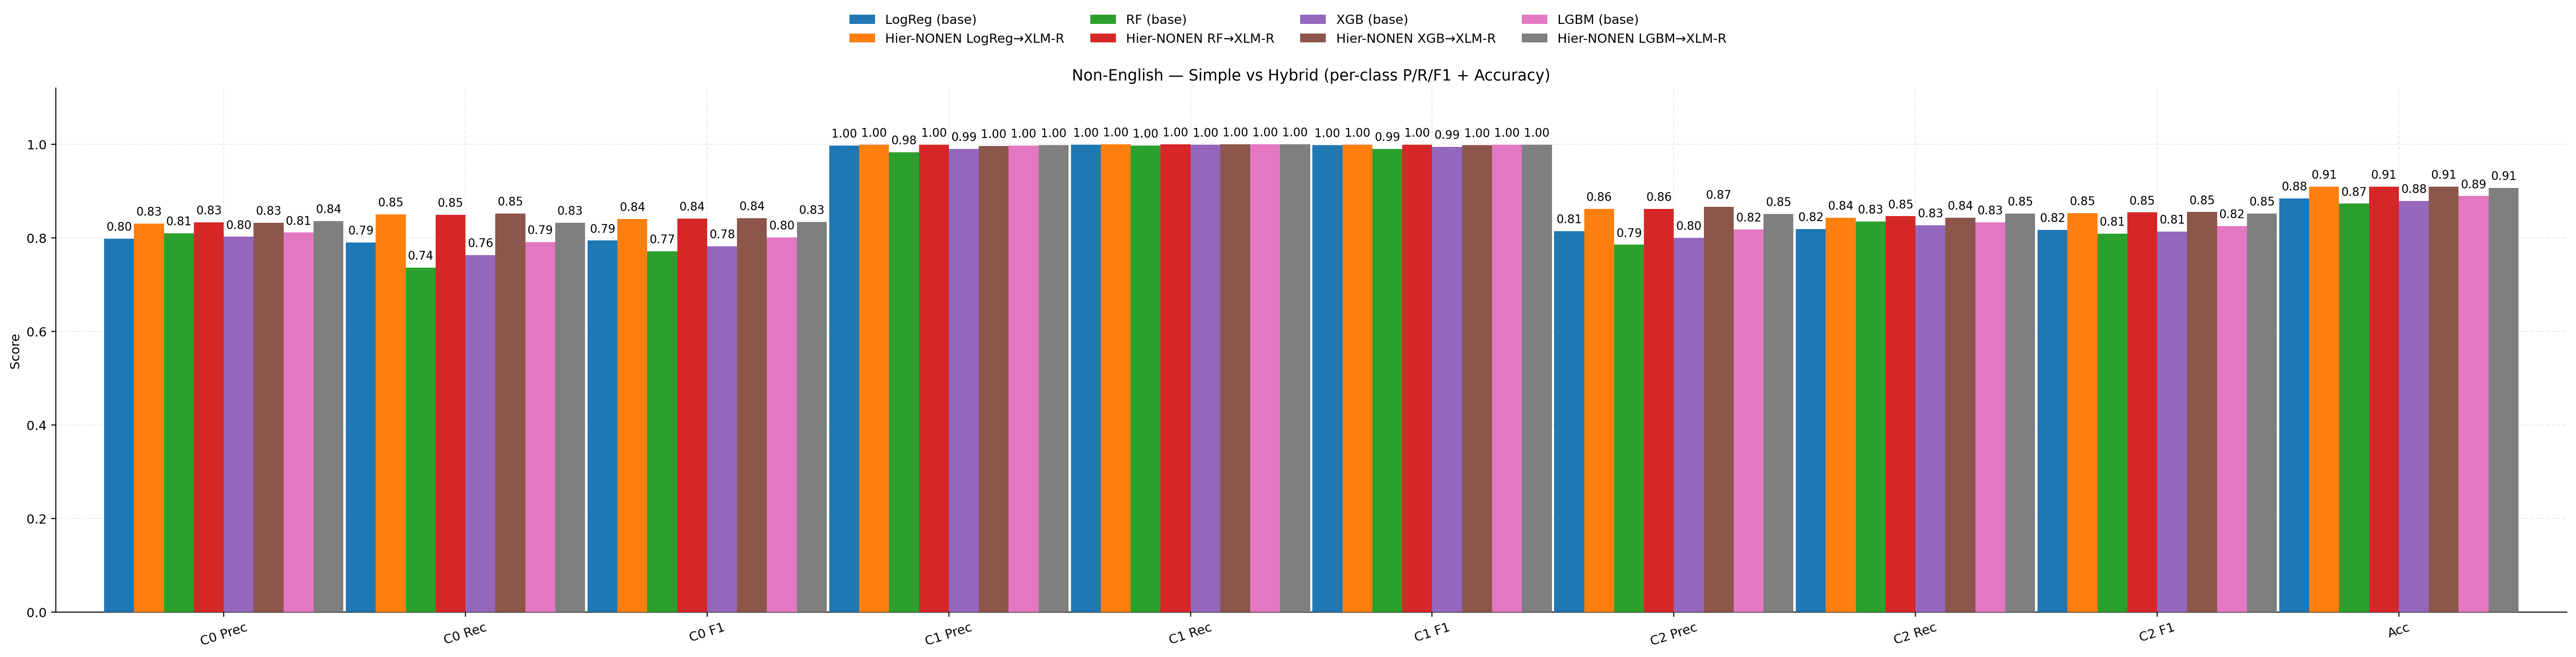

In [30]:
# plot_hybrid_non_en.py
# Generates one histogram comparing base vs hybrid (LogReg/RF/XGB/LGBM) for NON-ENGLISH.
# Bars = [C0 P, C0 R, C0 F1, C1 P, C1 R, C1 F1, C2 P, C2 R, C2 F1, ACC]

import numpy as np
import matplotlib.pyplot as plt
from collections import OrderedDict
from pathlib import Path

OUT_PATH = "artifacts_compare/hybrid_non_en_acc_pr_re_f1.png"

# ======= YOUR EXACT NON-EN RESULTS (from your message) =======
MODELS = OrderedDict([
    # Family 1: LogReg (base) vs Hier-NONEN (transformer)
    ("LogReg (base)", {
        "ACC": 0.8840,
        "per_class": {
            0: {"P": 0.798, "R": 0.790, "F1": 0.794},
            1: {"P": 0.997, "R": 0.999, "F1": 0.998},
            2: {"P": 0.814, "R": 0.819, "F1": 0.817},
        }
    }),
    ("Hier-NONEN LogReg→XLM-R", {
        "ACC": 0.9088,
        "per_class": {
            0: {"P": 0.830, "R": 0.850, "F1": 0.840},
            1: {"P": 0.999, "R": 1.000, "F1": 0.999},
            2: {"P": 0.862, "R": 0.843, "F1": 0.853},
        }
    }),

    # Family 2: RF (base) vs Hier-NONEN RF→XLM-R
    ("RF (base)", {
        "ACC": 0.8729,
        "per_class": {
            0: {"P": 0.810, "R": 0.736, "F1": 0.771},
            1: {"P": 0.983, "R": 0.997, "F1": 0.990},
            2: {"P": 0.785, "R": 0.835, "F1": 0.809},
        }
    }),
    ("Hier-NONEN RF→XLM-R", {
        "ACC": 0.9095,
        "per_class": {
            0: {"P": 0.833, "R": 0.849, "F1": 0.841},
            1: {"P": 0.999, "R": 1.000, "F1": 0.999},
            2: {"P": 0.862, "R": 0.846, "F1": 0.854},
        }
    }),

    # Family 3: XGB (base) vs Hier-NONEN XGB→XLM-R
    ("XGB (base)", {
        "ACC": 0.8786,
        "per_class": {
            0: {"P": 0.802, "R": 0.763, "F1": 0.782},
            1: {"P": 0.990, "R": 0.999, "F1": 0.994},
            2: {"P": 0.800, "R": 0.827, "F1": 0.813},
        }
    }),
    ("Hier-NONEN XGB→XLM-R", {
        "ACC": 0.9092,
        "per_class": {
            0: {"P": 0.832, "R": 0.852, "F1": 0.842},
            1: {"P": 0.996, "R": 1.000, "F1": 0.998},
            2: {"P": 0.866, "R": 0.843, "F1": 0.855},
        }
    }),

    # Family 4: LGBM (base) vs Hier-NONEN LGBM→XLM-R
    ("LGBM (base)", {
        "ACC": 0.8890,
        "per_class": {
            0: {"P": 0.811, "R": 0.791, "F1": 0.801},
            1: {"P": 0.997, "R": 1.000, "F1": 0.999},
            2: {"P": 0.818, "R": 0.833, "F1": 0.825},
        }
    }),
    ("Hier-NONEN LGBM→XLM-R", {
        "ACC": 0.9066,
        "per_class": {
            0: {"P": 0.836, "R": 0.832, "F1": 0.834},
            1: {"P": 0.998, "R": 1.000, "F1": 0.999},
            2: {"P": 0.851, "R": 0.852, "F1": 0.852},
        }
    }),
])

# families control the side-by-side pairing/order
FAMILIES = [
    ("LogReg (base)", "Hier-NONEN LogReg→XLM-R"),
    ("RF (base)", "Hier-NONEN RF→XLM-R"),
    ("XGB (base)", "Hier-NONEN XGB→XLM-R"),
    ("LGBM (base)", "Hier-NONEN LGBM→XLM-R"),
]

def _fmt(v): return f"{v:.2f}"

def _draw_labels(ax, bars, ymax, inside=False):
    for b in bars:
        v = b.get_height()
        y = max(v - 0.03, 0.02) if inside else min(v + 0.012, ymax - 0.015)
        va = "top" if inside else "bottom"
        ax.text(
            b.get_x() + b.get_width()/2, y, _fmt(v),
            ha="center", va=va, fontsize=9,
            bbox=dict(boxstyle="round,pad=0.15", fc="white", ec="none", alpha=0.85),
        )

def plot_hybrid(save_path=OUT_PATH, labels_inside=False):
    labels = ["C0 Prec","C0 Rec","C0 F1","C1 Prec","C1 Rec","C1 F1","C2 Prec","C2 Rec","C2 F1","Acc"]
    X = np.arange(len(labels))
    series = [m for fam in FAMILIES for m in fam if m in MODELS]
    n_series = len(series)

    group_w = 0.99
    bar_w   = min(group_w / n_series, 0.40)
    offsets = (np.arange(n_series) - (n_series-1)/2) * bar_w

    plt.rcParams.update({
        "figure.dpi": 220,
        "axes.spines.top": False, "axes.spines.right": False,
        "axes.grid": True, "grid.alpha": 0.25, "grid.linestyle": "--",
    })
    fig = plt.figure(figsize=(28, 7))
    ax  = plt.gca()
    ymax = 1.12
    ax.set_ylim(0, ymax)
    ax.margins(x=0.02, y=0.04)

    for i, name in enumerate(series):
        m = MODELS[name]
        vals = [
            m["per_class"][0]["P"], m["per_class"][0]["R"], m["per_class"][0]["F1"],
            m["per_class"][1]["P"], m["per_class"][1]["R"], m["per_class"][1]["F1"],
            m["per_class"][2]["P"], m["per_class"][2]["R"], m["per_class"][2]["F1"],
            m["ACC"],
        ]
        bars = ax.bar(X + offsets[i], vals, width=bar_w, zorder=3, label=name)
        _draw_labels(ax, bars, ymax, inside=labels_inside)

    ax.set_xticks(X, labels, rotation=18)
    ax.set_ylabel("Score")
    ax.set_title("Non-English — Simple vs Hybrid (per-class P/R/F1 + Accuracy)")
    h, t = ax.get_legend_handles_labels()
    fig.legend(h, t, ncol=4, loc="upper center", bbox_to_anchor=(0.5, 1.02), frameon=False)

    Path(save_path).parent.mkdir(parents=True, exist_ok=True)
    fig.tight_layout(rect=[0,0,1,0.94])
    fig.savefig(save_path, bbox_inches="tight")
    print(f"Saved → {save_path}")

if __name__ == "__main__":
    plot_hybrid(OUT_PATH, labels_inside=False)  # set True to draw values inside bars
